<a href="https://colab.research.google.com/github/YUFEIFUT/SparrowRecSys/blob/read_source/TFRecModel/src/com/sparrowrecsys/offline/ipynb/colab%E4%BD%9C%E4%B8%BAtf_serving%E7%9A%84%E6%B5%8B%E8%AF%95%E6%9C%8D%E5%8A%A1%E5%99%A8.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### 安装 TensorFlow Serving
此单元格将添加 TensorFlow Serving 的软件包源，并安装模型服务器。

In [1]:
# 添加 TensorFlow Serving 的 APT 软件源
!echo "deb http://storage.googleapis.com/tensorflow-serving-apt stable tensorflow-model-server tensorflow-model-server-universal" | tee /etc/apt/sources.list.d/tensorflow-serving.list && \
curl https://storage.googleapis.com/tensorflow-serving-apt/tensorflow-serving.release.pub.gpg | apt-key add -

# 更新软件列表并安装 tensorflow-model-server
!apt update
!apt-get install tensorflow-model-server

deb http://storage.googleapis.com/tensorflow-serving-apt stable tensorflow-model-server tensorflow-model-server-universal
  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed
  0     0    0     0    0     0      0      0 --:--:-- --:--:-- --:--:--     0Warning: apt-key is deprecated. Manage keyring files in trusted.gpg.d instead (see apt-key(8)).
100  2943  100  2943    0     0   7054      0 --:--:-- --:--:-- --:--:--  7057
OK
Hit:1 http://archive.ubuntu.com/ubuntu jammy InRelease
Get:2 http://archive.ubuntu.com/ubuntu jammy-updates InRelease [128 kB]
Get:3 http://security.ubuntu.com/ubuntu jammy-security InRelease [129 kB]
Get:4 http://storage.googleapis.com/tensorflow-serving-apt stable InRelease [3,026 B]
Get:5 http://archive.ubuntu.com/ubuntu jammy-backports InRelease [127 kB]
Get:6 https://cloud.r-project.org/bin/linux/ubuntu jammy-cran40/ InRelease [3,632 B]
Get:7 https://cli.

安装完成后，您可以通过运行以下命令来确认安装的版本。

In [2]:
# 检查 TensorFlow Model Server 的版本
!tensorflow_model_server --version

TensorFlow ModelServer: 2.20.0+dev.sha.bc7e9d2
TensorFlow Library: 2.20.0-dev0+selfbuilt


### 下载测试模型数据
我们将克隆 TensorFlow Serving 的仓库以获取官方提供的测试模型（如 `half_plus_two`）。

In [3]:
# 克隆仓库（如果目录已存在则跳过）
import os
if not os.path.exists('serving'):
    !git clone https://github.com/tensorflow/serving

# 设置测试数据路径
import os
testdata_path = os.path.join(os.getcwd(), "serving/tensorflow_serving/servables/tensorflow/testdata")
model_path = os.path.join(testdata_path, "saved_model_half_plus_two_cpu")

print(f"模型路径: {model_path}")

Cloning into 'serving'...
remote: Enumerating objects: 40479, done.
remote: Counting objects: 100% (343/343), done.
remote: Compressing objects: 100% (223/223), done.
remote: Total 40479 (delta 257), reused 126 (delta 119), pack-reused 40136 (from 3)
Receiving objects: 100% (40479/40479), 20.01 MiB | 18.72 MiB/s, done.
Resolving deltas: 100% (32948/32948), done.
模型路径: /content/serving/tensorflow_serving/servables/tensorflow/testdata/saved_model_half_plus_two_cpu


### 启动 TensorFlow Serving 服务
由于 Colab 不方便运行 Docker 容器，我们直接使用已安装的 `tensorflow_model_server` 在后台启动服务。

In [4]:
# 使用 nohup 在后台启动模型服务器，监听 8501 端口
os.environ['MODEL_PATH'] = model_path

!nohup tensorflow_model_server \
    --rest_api_port=8501 \
    --model_name=half_plus_two \
    --model_base_path=$MODEL_PATH > server.log 2>&1 &

print("TensorFlow Serving 正在后台启动... 日志将写入 server.log")

TensorFlow Serving 正在后台启动... 日志将写入 server.log


### 验证服务是否成功启动
等待几秒钟后，我们可以检查日志或尝试发送一个预测请求。

In [5]:
# 检查日志最后几行，看是否加载成功
!tail server.log

# 发送一个测试请求
!curl -d '{"instances": [1.0, 2.0, 5.0]}' -X POST http://localhost:8501/v1/models/half_plus_two:predict

2026-06-30 15:59:37.747581: I external/org_tensorflow/tensorflow/cc/saved_model/loader.cc:471] SavedModel load for tags { serve }; Status: success: OK. Took 45299 microseconds.
2026-06-30 15:59:37.747714: I tensorflow_serving/servables/tensorflow/saved_model_warmup_util.cc:85] No warmup data file found at /content/serving/tensorflow_serving/servables/tensorflow/testdata/saved_model_half_plus_two_cpu/00000123/assets.extra/tf_serving_warmup_requests
2026-06-30 15:59:37.906093: I tensorflow_serving/core/loader_harness.cc:104] Successfully loaded servable version {name: half_plus_two version: 123}
I0000 00:00:1782835177.906932    3102 server_core.cc:537] Finished adding/updating models
2026-06-30 15:59:37.908528: I tensorflow_serving/model_servers/server.cc:124] Using InsecureServerCredentials
2026-06-30 15:59:37.908667: I tensorflow_serving/model_servers/server.cc:395] Profiler service is enabled
2026-06-30 15:59:37.909572: I tensorflow_serving/model_servers/server.cc:430] Running gRPC Mo

### 使用 ngrok 暴露公网访问接口
我们将安装 `pyngrok` 并通过它将本地的 8501 端口映射到公网。

In [6]:
# 安装 pyngrok
!pip install pyngrok

请在下方填入您的 ngrok Authtoken（可以从 ngrok 官网控制台获取）。

In [7]:
from pyngrok import ngrok
from google.colab import userdata
import os

try:
    # 从 Colab Secrets 中安全读取 Token
    # 请确保您已在左侧“钥匙”面板添加了名为 NGROK_TOKEN 的变量
    NGROK_TOKEN = userdata.get('NGROK_TOKEN')

    # 尝试关闭现有的 ngrok 进程以防冲突
    ngrok.kill()
    # 设置 Token
    ngrok.set_auth_token(NGROK_TOKEN)

    # 创建 HTTP 隧道指向 TensorFlow Serving 的 8501 端口
    tunnel = ngrok.connect(8501, "http")
    public_url = tunnel.public_url
    print(f"TensorFlow Serving 公网访问地址: {public_url}")
except userdata.SecretNotFoundError:
    print("❌ 错误：未在 Colab Secrets 中找到 NGROK_TOKEN。")
    print("请点击左侧钥匙图标，添加 Name 为 NGROK_TOKEN 的密钥并开启访问权限。")
except Exception as e:
    print(f"发生错误: {e}")

TensorFlow Serving 公网访问地址: https://footbath-naming-impaired.ngrok-free.dev


### 外部访问示例
现在您可以复制上面的 `public_url` 地址，在您的本地终端或其他代码中使用它。示例：

In [8]:
# 确保 public_url 已成功定义后再进行打印
if 'public_url' in locals():
    print(f"您可以尝试在您自己电脑的终端运行以下命令来测试远程访问:")
    print(f"curl -d '{{\"instances\": [1.0, 2.0, 5.0]}}' -X POST {public_url}/v1/models/half_plus_two:predict")
else:
    print("❌ 公网隧道尚未成功建立。请先在上面的单元格中填入正确的 Token 并运行成功。")

您可以尝试在您自己电脑的终端运行以下命令来测试远程访问:
curl -d '{"instances": [1.0, 2.0, 5.0]}' -X POST https://footbath-naming-impaired.ngrok-free.dev/v1/models/half_plus_two:predict


windows上调用

curl -X POST https://footbath-naming-impaired.ngrok-free.dev/v1/models/half_plus_two:predict -H "Content-Type: application/json" -d "{\"instances\": [1.0, 2.0, 5.0]}"

## 克隆仓库

In [9]:
!git clone https://github.com/YUFEIFUT/SparrowRecSys.git

Cloning into 'SparrowRecSys'...
remote: Enumerating objects: 3038, done.
remote: Counting objects: 100% (225/225), done.
remote: Compressing objects: 100% (133/133), done.
remote: Total 3038 (delta 99), reused 121 (delta 79), pack-reused 2813 (from 2)
Receiving objects: 100% (3038/3038), 181.87 MiB | 10.02 MiB/s, done.
Resolving deltas: 100% (632/632), done.
Updating files: 100% (1075/1075), done.


In [10]:
# 切换 SparrowRecSys 仓库到 read_source 分支
!cd /content/SparrowRecSys && git checkout read_source

Branch 'read_source' set up to track remote branch 'read_source' from 'origin'.
Switched to a new branch 'read_source'


## EmbeddingMLP.py

### 现代 Keras 实现版本 (适配 Keras 3 / TF 2.16+)
由于 `tf.feature_column` 及其相关的 `DenseFeatures` 在新版本中已不再推荐使用且存在严重的 API 路径变更问题，本单元格使用 Keras 原生的 **Preprocessing Layers** (如 `StringLookup`, `IntegerLookup`) 重新实现。这种方式将特征处理直接嵌入到模型中，无需外部特征层。

<font color='red'>这个就当作注释看吧，也不用运行了</font>

In [ ]:
import tensorflow as tf
from tensorflow.keras import layers
import pandas as pd
import numpy as np

# 1. 指定训练集和测试集的路径
train_path = "/content/SparrowRecSys/src/main/resources/webroot/sampledata/trainingSamplesByTimeStamp.csv"
validation_path = "/content/SparrowRecSys/src/main/resources/webroot/sampledata/validationSamplesByTimeStamp.csv"
test_path = "/content/SparrowRecSys/src/main/resources/webroot/sampledata/testSamplesByTimeStamp.csv"

# 2. 定义特征清单与词表
# 电影风格（Genre）的全量枚举值，用于构建 StringLookup 的词表
genre_vocab = ['Film-Noir', 'Action', 'Adventure', 'Horror', 'Romance', 'War', 'Comedy', 'Western', 'Documentary',
               'Sci-Fi', 'Drama', 'Thriller', 'Crime', 'Fantasy', 'Animation', 'IMAX', 'Mystery', 'Children', 'Musical']

# 类别特征列表（包含用户偏好风格和电影自身风格）
genre_features = ['userGenre1', 'userGenre2', 'userGenre3', 'userGenre4', 'userGenre5',
                  'movieGenre1', 'movieGenre2', 'movieGenre3']
# 数值型特征列表（发行年份、评分统计信息等）
numeric_features = ['releaseYear', 'movieRatingCount', 'movieAvgRating',
                    'movieRatingStddev', 'userRatingCount', 'userAvgRating', 'userRatingStddev']

# 3. 构造输入层并进行预处理
all_inputs = {}  # 保存所有输入层
encoded_features = []  # 保存经过处理后的特征

# --- A. 处理数值特征 ---
for header in numeric_features:
    # 为每个数值特征定义一个 Input 层，接收 float32 类型数据
    # 为什么 shape=(1,)？因为一个特征只有一个数字
    numeric_col = tf.keras.Input(shape=(1,), name=header, dtype='float32')
    all_inputs[header] = numeric_col
    # 数值特征直接加入特征列表，无需额外转换
    encoded_features.append(numeric_col)

# --- B. 处理 Genre 类别特征 (String -> Embedding) ---
for header in genre_features:
    # 定义接收字符串的输入层
    categorical_col = tf.keras.Input(shape=(1,), name=header, dtype='string')
    all_inputs[header] = categorical_col
    # 使用 StringLookup 将字符串映射为整数索引：
    # - vocabulary: 使用预定义的风格词表
    # - num_oov_indices: 设为 1，用于处理词表外的未知风格
    lookup_layer = layers.StringLookup(vocabulary=genre_vocab, mask_token=None, num_oov_indices=1)
    index = lookup_layer(categorical_col)
    # 使用 Embedding 层将索引转换为 10 维稠密向量
    # input_dim 为词表大小 + OOV + 1【这里原本的代码底层逻辑是咋样的？】
    embedding = layers.Embedding(input_dim=len(genre_vocab) + 2, output_dim=10)(index)
    # 将 Embedding 输出展平（从 [batch, 1, 10] 变为 [batch, 10]）以便拼接
    encoded_features.append(layers.Flatten()(embedding))

# --- C. 处理 ID 特征 (Int -> Embedding) ---
# 电影 ID：假设范围 1001 以内
movie_id_input = tf.keras.Input(shape=(1,), name='movieId', dtype='int64')
all_inputs['movieId'] = movie_id_input
movie_embedding = layers.Embedding(input_dim=1001, output_dim=10)(movie_id_input)
encoded_features.append(layers.Flatten()(movie_embedding))

# 用户 ID：假设范围 30001 以内
user_id_input = tf.keras.Input(shape=(1,), name='userId', dtype='int64')
all_inputs['userId'] = user_id_input
user_embedding = layers.Embedding(input_dim=30001, output_dim=10)(user_id_input)
encoded_features.append(layers.Flatten()(user_embedding))

# 4. 构建 MLP 网络 (多层感知机)
# 将所有处理后的特征（数值 + Embedding）拼接成一个长向量
#【之前的代码应该是多种特征加起来吧，现在的layers.Concatenate()(encoded_features)是什么逻辑？】
all_features = layers.Concatenate()(encoded_features)
# 两个隐藏层，每层 128 个神经元，使用 ReLU 激活函数增强非线性表达能力
x = layers.Dense(128, activation="relu")(all_features)
x = layers.Dense(128, activation="relu")(x)
# 输出层使用 Sigmoid 激活函数，输出 0 到 1 之间的点击概率值
output = layers.Dense(1, activation="sigmoid")(x)

# 定义 Keras 函数式模型
new_model = tf.keras.Model(all_inputs, output)

# 5. 编译模型
new_model.compile(
    optimizer='adam',                # Adam 优化器，自动调节学习率
    loss='binary_crossentropy',      # 二分类交叉熵损失函数
    metrics=['accuracy', tf.keras.metrics.AUC(name='roc_auc', curve='ROC')])

# 6. 优化的数据加载函数
def df_to_dataset(file_path, batch_size=32):
    """将 CSV 文件加载并转换为 tf.data.Dataset 格式"""
    df = pd.read_csv(file_path)
    feature_cols = numeric_features + genre_features + ['movieId', 'userId']

    # 标签转换为 float32
    labels = df['label'].values.astype('float32')

    # 数据清洗与类型转换
    # 1. 数值特征：填充缺失值为 0，强制转为 float32
    df[numeric_features] = df[numeric_features].fillna(0).astype('float32')
    # 2. 类别特征：填充缺失值为 'None'，强制转为 string 防止 Pandas 误识别类型
    df[genre_features] = df[genre_features].fillna('None').astype(str)
    # 3. ID 特征：取模运算确保数值不会超出 Embedding 层的 input_dim 范围
    df['movieId'] = df['movieId'].fillna(0).astype('int64') % 1001
    df['userId'] = df['userId'].fillna(0).astype('int64') % 30001

    # 构建输入字典
    input_dict = {col: df[col].values for col in feature_cols}
    # 转换为 TF 数据集
    ds = tf.data.Dataset.from_tensor_slices((input_dict, labels))
    return ds.batch(batch_size).cache().prefetch(tf.data.AUTOTUNE)

# 准备训练和测试数据
train_ds = df_to_dataset(train_path)
validation_ds = df_to_dataset(validation_path)
test_ds = df_to_dataset(test_path)

# 7. 设置早停法回调 (EarlyStopping)
early_stopping = tf.keras.callbacks.EarlyStopping(
    monitor='val_roc_auc',    # 监控验证集的 AUC
    patience=5,               # 如果连续 5 个 epoch 指标没提升就停止
    mode='max',               # 目标是最大化 AUC
    restore_best_weights=True # 停止后恢复最优权重
)

# 8. 执行训练 (赋值给 history 变量以供绘图)
print("开始带有早停法的模型训练...")
history = new_model.fit(
    train_ds,
    validation_data=validation_ds,
    epochs=50,                # 设置较大的上限
    callbacks=[early_stopping]
)

# 9. 最终评估
loss, accuracy, auc = new_model.evaluate(test_ds)
print(f"\n最终评估结果: Loss: {loss:.4f}, Accuracy: {accuracy:.4f}, AUC: {auc:.4f}")

开始带有早停法的模型训练...
Epoch 1/50
2779/2779 ━━━━━━━━━━━━━━━━━━━━ 31s 10ms/step - accuracy: 0.5734 - loss: 4.4979 - roc_auc: 0.5865 - val_accuracy: 0.4752 - val_loss: 2.6481 - val_roc_auc: 0.6071
Epoch 2/50
2779/2779 ━━━━━━━━━━━━━━━━━━━━ 45s 11ms/step - accuracy: 0.6208 - loss: 1.5611 - roc_auc: 0.6482 - val_accuracy: 0.6889 - val_loss: 1.2165 - val_roc_auc: 0.7110
Epoch 3/50
2779/2779 ━━━━━━━━━━━━━━━━━━━━ 27s 10ms/step - accuracy: 0.6570 - loss: 1.0127 - roc_auc: 0.6953 - val_accuracy: 0.4188 - val_loss: 2.8174 - val_roc_auc: 0.5276
Epoch 4/50
2779/2779 ━━━━━━━━━━━━━━━━━━━━ 28s 10ms/step - accuracy: 0.6861 - loss: 0.7620 - roc_auc: 0.7363 - val_accuracy: 0.5148 - val_loss: 1.2101 - val_roc_auc: 0.5578
Epoch 5/50
2779/2779 ━━━━━━━━━━━━━━━━━━━━ 30s 11ms/step - accuracy: 0.7185 - loss: 0.5751 - roc_auc: 0.7877 - val_accuracy: 0.6437 - val_loss: 0.6364 - val_roc_auc: 0.7109
Epoch 6/50
2779/2779 ━━━━━━━━━━━━━━━━━━━━ 27s 10ms/step - accuracy: 0.7440 - loss: 0.5118 - roc_auc: 0.8240 - val_accuracy: 

### 1. 导出模型为 SavedModel 格式
TensorFlow Serving 需要 SavedModel 格式。我们将模型保存到 `/content/models/embedding_mlp/1`（'1' 是版本号）。

In [ ]:
import os

# 定义模型保存路径，包含版本号
# export_path = "/content/models/embedding_mlp/1"
export_path = "/content/SparrowRecSys/src/main/resources/webroot/myModels/embedding_mlp/1"

# 如果目录已存在则先删除，确保干净导出
if os.path.exists(export_path):
    import shutil
    shutil.rmtree(export_path)

# 在 Keras 3 中，导出为 SavedModel (供 TF Serving 使用) 需使用 export 方法
# 这种方式会自动处理 SavedModel 的签名，不再依赖 .save() 的后缀识别
new_model.export(export_path)

print(f"模型已成功导出至: {export_path}")
# 查看导出目录结构，确认包含 fingerprint.pb 和 variables
!ls -l {export_path}

Saved artifact at '/content/models/embedding_mlp/1'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): Dict[['releaseYear', TensorSpec(shape=(None, 1), dtype=tf.float32, name='releaseYear')], ['movieRatingCount', TensorSpec(shape=(None, 1), dtype=tf.float32, name='movieRatingCount')], ['movieAvgRating', TensorSpec(shape=(None, 1), dtype=tf.float32, name='movieAvgRating')], ['movieRatingStddev', TensorSpec(shape=(None, 1), dtype=tf.float32, name='movieRatingStddev')], ['userRatingCount', TensorSpec(shape=(None, 1), dtype=tf.float32, name='userRatingCount')], ['userAvgRating', TensorSpec(shape=(None, 1), dtype=tf.float32, name='userAvgRating')], ['userRatingStddev', TensorSpec(shape=(None, 1), dtype=tf.float32, name='userRatingStddev')], ['userGenre1', TensorSpec(shape=(None, 1), dtype=tf.string, name='userGenre1')], ['userGenre2', TensorSpec(shape=(None, 1), dtype=tf.string, name='userGenre2')], ['userGenre3', TensorSpec(shape=(None, 1), dtype=tf.str

### 2. 部署到 TensorFlow Serving
我们需要杀掉之前运行的 `half_plus_two` 服务的进程，并启动新的服务来加载我们的 `embedding_mlp` 模型。

### 3. 验证新模型接口
等待几秒钟确保模型加载完成后，我们尝试调用 API 接口。

In [ ]:
import os
import time

print("正在重启 TensorFlow Serving...")

# 停止旧服务
!pkill -f tensorflow_model_server

# 模型路径
# os.environ['MODEL_BASE_PATH'] = "/content/models/embedding_mlp"
os.environ['MODEL_BASE_PATH'] = "/content/SparrowRecSys/src/main/resources/webroot/myModels/embedding_mlp"

# 启动服务
!nohup tensorflow_model_server \
    --rest_api_port=8501 \
    --model_name=sparrow_mlp \
    --model_base_path=$MODEL_BASE_PATH \
    > server_new.log 2>&1 &

# 等待启动
time.sleep(5)

# 查看日志
print("--- 最近服务器日志 ---")
!tail -n 10 server_new.log

# 输出接口
if 'public_url' in locals():
    print(
        f"\n接口地址:"
        f"{public_url}/v1/models/sparrow_mlp:predict"
    )

正在重启 TensorFlow Serving...
--- 最近服务器日志 ---
2026-06-30 09:16:17.342297: I external/org_tensorflow/tensorflow/cc/saved_model/loader.cc:471] SavedModel load for tags { serve }; Status: success: OK. Took 236355 microseconds.
2026-06-30 09:16:17.343823: I tensorflow_serving/servables/tensorflow/saved_model_warmup_util.cc:85] No warmup data file found at /content/SparrowRecSys/src/main/resources/webroot/myModels/embedding_mlp/1/assets.extra/tf_serving_warmup_requests
2026-06-30 09:16:17.423221: I tensorflow_serving/core/loader_harness.cc:104] Successfully loaded servable version {name: sparrow_mlp version: 1}
I0000 00:00:1782810977.424279    5787 server_core.cc:537] Finished adding/updating models
2026-06-30 09:16:17.425507: I tensorflow_serving/model_servers/server.cc:124] Using InsecureServerCredentials
2026-06-30 09:16:17.425659: I tensorflow_serving/model_servers/server.cc:395] Profiler service is enabled
2026-06-30 09:16:17.426279: I tensorflow_serving/model_servers/server.cc:430] Runni

### 4. 真实数据预测测试
我们将从测试集中提取一条数据，构造符合模型输入格式的 JSON，并通过 REST API 发送给 TensorFlow Serving。

In [ ]:
import requests
import json
import pandas as pd

# 1. 加载一小部分测试数据
test_df = pd.read_csv("/content/SparrowRecSys/src/main/resources/webroot/sampledata/testSamplesByTimeStamp.csv").iloc[299:300]

# --- 新增：打印原始数据对照 ---
print("--- 待测试样本原始特征 ---")
print(test_df.iloc[0].to_string())
print("-" * 30)

# 2. 准备输入数据 (需严格匹配导出模型时的输入层名称和类型)
instance = {}
for col in numeric_features:
    instance[col] = [float(test_df[col].fillna(0).iloc[0])]
for col in genre_features:
    instance[col] = [str(test_df[col].fillna('None').iloc[0])]
instance['movieId'] = [int(test_df['movieId'].fillna(0).iloc[0]) % 1001]
instance['userId'] = [int(test_df['userId'].fillna(0).iloc[0]) % 30001]

# 3. 构造请求体
data = json.dumps({"instances": [instance]})
headers = {"content-type": "application/json"}

# 4. 发送预测请求
predict_url = f"{public_url}/v1/models/sparrow_mlp:predict"
print(f"\n正在请求接口: {predict_url}")

response = requests.post(predict_url, data=data, headers=headers)

if response.status_code == 200:
    result = response.json()
    prediction = result['predictions'][0][0]
    print(f"\n预测成功！")
    print(f"输入样本的预测点击概率 (CTR): {prediction:.4f}")
    print(f"实际标签 (Label): {test_df['label'].iloc[0]}")
else:
    print(f"\n预测失败！")
    print(f"状态码: {response.status_code}")
    print(f"错误信息: {response.text}")

### 如果上边的测试有问题，可以尝试下边的代码重启一下ngrok

In [ ]:
# 1. 检查 TensorFlow Model Server 进程状态
!ps -ef | grep tensorflow_model_server | grep -v grep

# 2. 重新启动 ngrok 隧道
from pyngrok import ngrok
from google.colab import userdata

try:
    # 杀掉所有现有的 ngrok 隧道
    ngrok.kill()

    # 获取 Token 并重新设置 (确保您已在 Secrets 中设置 NGROK_TOKEN)
    NGROK_TOKEN = userdata.get('NGROK_TOKEN')
    ngrok.set_auth_token(NGROK_TOKEN)

    # 重新建立到 8501 端口的连接
    new_tunnel = ngrok.connect(8501, "http")
    public_url = new_tunnel.public_url
    print(f"新的公网访问地址: {public_url}")
    print(f"新的预测接口地址: {public_url}/v1/models/sparrow_mlp:predict")
except Exception as e:
    print(f"重启隧道失败: {e}")

root       20506       1  0 13:04 ?        00:00:00 tensorflow_model_server --rest_api_port=8501 --model_name=sparrow_dfm --model_base_path=/content/models/deepfm
新的公网访问地址: https://footbath-naming-impaired.ngrok-free.dev
新的预测接口地址: https://footbath-naming-impaired.ngrok-free.dev/v1/models/sparrow_mlp:predict


### Windows CMD `curl` 调用命令示例
将以下命令复制并粘贴到您的 Windows `cmd.exe` 命令行中执行：


In [ ]:
import json

# 提取模型所需的特征值
# 数据来源: 204,2162,4.0,836418450,1,1995,Action,"","",1782,2.97,1.06,261,377,440,11,589,39,1993,1.47,3.82,1.00,Drama,Adventure,Action,Thriller,Romance

instance_data = {
    'movieId': [204],
    'userId': [2162],
    'releaseYear': [1995.0],
    'movieRatingCount': [1782.0],
    'movieAvgRating': [2.97],
    'movieRatingStddev': [1.06],
    'userRatingCount': [39.0],
    'userAvgRating': [3.82],
    'userRatingStddev': [1.00],
    'userGenre1': ['Drama'],
    'userGenre2': ['Adventure'],
    'userGenre3': ['Action'],
    'userGenre4': ['Thriller'],
    'userGenre5': ['Romance'],
    'movieGenre1': ['Action'],
    'movieGenre2': ['None'], # Original data was empty, mapped to 'None'
    'movieGenre3': ['None']  # Original data was empty, mapped to 'None'
}

# 构造 JSON payload，使用 separators=(',', ':') 避免不必要的空白，方便 CMD 处理
payload = {"instances": [instance_data]}
json_payload = json.dumps(payload, separators=(',', ':'))

# 为 Windows CMD 逃逸内部双引号
escaped_json_payload = json_payload.replace('"', '\"')

# 构建 curl 命令
# public_url 变量来自之前的 ngrok 隧道单元格
curl_command_windows = f'curl -X POST "{public_url}/v1/models/sparrow_mlp:predict" -H "Content-Type: application/json" -d "{escaped_json_payload}"'

print("```bash") # 使用 markdown 代码块方便复制
print(curl_command_windows)
print("```")

```bash
curl -X POST "https://footbath-naming-impaired.ngrok-free.dev/v1/models/sparrow_mlp:predict" -H "Content-Type: application/json" -d "{"instances":[{"movieId":[204],"userId":[2162],"releaseYear":[1995.0],"movieRatingCount":[1782.0],"movieAvgRating":[2.97],"movieRatingStddev":[1.06],"userRatingCount":[39.0],"userAvgRating":[3.82],"userRatingStddev":[1.0],"userGenre1":["Drama"],"userGenre2":["Adventure"],"userGenre3":["Action"],"userGenre4":["Thriller"],"userGenre5":["Romance"],"movieGenre1":["Action"],"movieGenre2":["None"],"movieGenre3":["None"]}]}"
```


Windows的cmd中需要的格式

curl -X POST "https://footbath-naming-impaired.ngrok-free.dev/v1/models/sparrow_mlp:predict" ^
-H "Content-Type: application/json" ^
-d "{\"instances\":[{\"movieId\":[95],\"userId\":[11722],\"releaseYear\":[1996.0],\"movieRatingCount\":[4791.0],\"movieAvgRating\":[3.10],\"movieRatingStddev\":[0.95],\"userRatingCount\":[55.0],\"userAvgRating\":[3.56],\"userRatingStddev\":[0.87],\"userGenre1\":[\"Drama\"],\"userGenre2\":[\"Thriller\"],\"userGenre3\":[\"Action\"],\"userGenre4\":[\"Adventure\"],\"userGenre5\":[\"Crime\"],\"movieGenre1\":[\"Action\"],\"movieGenre2\":[\"Adventure\"],\"movieGenre3\":[\"Thriller\"]}]}"

## WideNDeep

In [ ]:
import tensorflow as tf
print(f"TensorFlow Version: {tf.__version__}")

TensorFlow Version: 2.20.0


### 从原本项目的代码通过claude code改造过来的

In [ ]:
"""
Wide & Deep 模型 —— 适配 TensorFlow 2.20.0 (Keras 3) 的版本。

为什么要重写？
----------------
原始 WideNDeep.py 是 TF 2.3 时代的代码，大量依赖 `tf.feature_column`
(categorical_column_with_vocabulary_list / embedding_column / crossed_column /
indicator_column 等) 以及 `tf.keras.layers.DenseFeatures`。

从 TF 2.16 起，Keras 默认升级为 Keras 3，`tf.feature_column` 和
`DenseFeatures` 已经被彻底移除。所以在 TF 2.20.0 下原代码无法运行。

本文件用 Keras 预处理层(Preprocessing Layers)重新实现等价逻辑：
    - categorical_column_with_vocabulary_list + embedding_column
        -> StringLookup + Embedding
    - categorical_column_with_identity + embedding_column
        -> 直接用 Embedding (ID 本身就是整数索引)
    - crossed_column + indicator_column
        -> HashedCrossing(output_mode='one_hot')
    - numeric_column + DenseFeatures
        -> 直接把数值 Input 拼接起来

模型结构(Wide & Deep)、特征、超参数都与原版保持一致。
"""

import os
import tensorflow as tf

# ============ 样本数据路径 ============
# 改成你本地的 trainingSamples.csv / testSamples.csv 路径。
# 这里默认指向本仓库内的 sampledata 目录。
# 从本文件(.../TFRecModel/src/com/sparrowrecsys/offline/tensorflow/) 往上 6 级即仓库根目录
training_samples_file_path = "/content/SparrowRecSys/src/main/resources/webroot/sampledata/trainingSamplesByTimeStamp.csv"
validation_samples_file_path = "/content/SparrowRecSys/src/main/resources/webroot/sampledata/validationSamplesByTimeStamp.csv"
test_samples_file_path = "/content/SparrowRecSys/src/main/resources/webroot/sampledata/testSamplesByTimeStamp.csv"


# ============ 只选用模型真正用到的列 ============
# 关键修复(Keras 3 / TF 2.20)：
# CSV 一共有 26 列，但本模型只定义了 18 个 Input。Keras 3 的函数式模型在
# 传入的 dict 结构与 Input 结构不一致时，会从“按列名映射”退化成“按顺序映射”，
# 于是 float 列(如 rating)被错误地喂进了 string 类型的 genre Input，
# 报错 "Cast float to string is not supported"。
# 通过 select_columns 把 dataset 限制为模型用到的列(+label)，
# 使 dict 的 key 与模型 Input 名一一对应，按名字正确映射。
SELECTED_COLUMNS = [
    'movieId', 'userId', 'releaseYear',
    'movieGenre1', 'movieGenre2', 'movieGenre3',
    'movieRatingCount', 'movieAvgRating', 'movieRatingStddev',
    'userRatedMovie1',
    'userRatingCount', 'userAvgRating', 'userRatingStddev',
    'userGenre1', 'userGenre2', 'userGenre3', 'userGenre4', 'userGenre5',
    'label',
]


# 每个特征对应的 dtype（与下面模型 Input 的 dtype 严格一致）
INT_FEATURES = ['movieRatingCount', 'userRatingCount', 'releaseYear',
                'movieId', 'userId', 'userRatedMovie1']
FLOAT_FEATURES = ['movieAvgRating', 'movieRatingStddev',
                  'userAvgRating', 'userRatingStddev']
STRING_FEATURES = ['userGenre1', 'userGenre2', 'userGenre3', 'userGenre4', 'userGenre5',
                   'movieGenre1', 'movieGenre2', 'movieGenre3']


def _reorder_and_cast(features, label):
    """关键修复(Keras 3 / TF 2.20)：
    make_csv_dataset 返回的是 OrderedDict，且列顺序跟随 CSV header，
    与模型 Input 的定义顺序不同。Keras 3 在结构(OrderedDict vs dict、
    顺序不一致)不匹配时，会从“按列名映射”退化成“按位置映射”，
    导致 string 的 genre 列被喂进 int 的 ID Input，报
    'Cast string to int32 / float to string is not supported'。

    这里显式重建一个普通 dict，key 与模型 Input 一一对应，
    并把每列 cast 到模型期望的 dtype，彻底消除顺序/类型歧义。
    """
    out = {}
    # 同时把每列从 (batch,) expand 成 (batch, 1)，与 Input(shape=(1,)) 对齐
    for name in INT_FEATURES:
        out[name] = tf.expand_dims(tf.cast(features[name], tf.int32), axis=-1)
    for name in FLOAT_FEATURES:
        out[name] = tf.expand_dims(tf.cast(features[name], tf.float32), axis=-1)
    for name in STRING_FEATURES:
        col = features[name]
        if col.dtype != tf.string:
            col = tf.strings.as_string(col)
        out[name] = tf.expand_dims(col, axis=-1)
    return out, label


# ============ 加载样本为 tf.data.Dataset ============
def get_dataset(file_path):
    dataset = tf.data.experimental.make_csv_dataset(
        file_path,
        batch_size=12,
        label_name='label',
        select_columns=SELECTED_COLUMNS,
        na_value="0",
        num_epochs=1,
        ignore_errors=True)
    # 重排列顺序 + 统一 dtype，保证与模型 Input 按名字正确映射
    dataset = dataset.map(_reorder_and_cast)
    return dataset


train_dataset = get_dataset(training_samples_file_path)
validation_dataset = get_dataset(validation_samples_file_path)
test_dataset = get_dataset(test_samples_file_path)

# ============ genre(电影类型)词表 ============
genre_vocab = ['Film-Noir', 'Action', 'Adventure', 'Horror', 'Romance', 'War', 'Comedy', 'Western', 'Documentary',
               'Sci-Fi', 'Drama', 'Thriller',
               'Crime', 'Fantasy', 'Animation', 'IMAX', 'Mystery', 'Children', 'Musical']

GENRE_FEATURES = {
    'userGenre1': genre_vocab,
    'userGenre2': genre_vocab,
    'userGenre3': genre_vocab,
    'userGenre4': genre_vocab,
    'userGenre5': genre_vocab,
    'movieGenre1': genre_vocab,
    'movieGenre2': genre_vocab,
    'movieGenre3': genre_vocab
}

# ============ 定义 Keras 模型的输入层 ============
# 在 Keras 3 中，预处理层直接接收 Input 张量。
# 这里 shape=(1,) 表示每个样本一个标量(make_csv_dataset 给出的每列形状是 (batch,)，
# Keras 会自动对齐到 (batch, 1))。
inputs = {
    'movieAvgRating': tf.keras.layers.Input(name='movieAvgRating', shape=(1,), dtype='float32'),
    'movieRatingStddev': tf.keras.layers.Input(name='movieRatingStddev', shape=(1,), dtype='float32'),
    'movieRatingCount': tf.keras.layers.Input(name='movieRatingCount', shape=(1,), dtype='int32'),
    'userAvgRating': tf.keras.layers.Input(name='userAvgRating', shape=(1,), dtype='float32'),
    'userRatingStddev': tf.keras.layers.Input(name='userRatingStddev', shape=(1,), dtype='float32'),
    'userRatingCount': tf.keras.layers.Input(name='userRatingCount', shape=(1,), dtype='int32'),
    'releaseYear': tf.keras.layers.Input(name='releaseYear', shape=(1,), dtype='int32'),

    'movieId': tf.keras.layers.Input(name='movieId', shape=(1,), dtype='int32'),
    'userId': tf.keras.layers.Input(name='userId', shape=(1,), dtype='int32'),
    'userRatedMovie1': tf.keras.layers.Input(name='userRatedMovie1', shape=(1,), dtype='int32'),

    'userGenre1': tf.keras.layers.Input(name='userGenre1', shape=(1,), dtype='string'),
    'userGenre2': tf.keras.layers.Input(name='userGenre2', shape=(1,), dtype='string'),
    'userGenre3': tf.keras.layers.Input(name='userGenre3', shape=(1,), dtype='string'),
    'userGenre4': tf.keras.layers.Input(name='userGenre4', shape=(1,), dtype='string'),
    'userGenre5': tf.keras.layers.Input(name='userGenre5', shape=(1,), dtype='string'),
    'movieGenre1': tf.keras.layers.Input(name='movieGenre1', shape=(1,), dtype='string'),
    'movieGenre2': tf.keras.layers.Input(name='movieGenre2', shape=(1,), dtype='string'),
    'movieGenre3': tf.keras.layers.Input(name='movieGenre3', shape=(1,), dtype='string'),
}

# ============ Deep 部分的特征构造 ============
# 用一个列表收集所有 deep 侧的特征张量，最后 Concatenate 在一起。
deep_feature_tensors = []

# ---------- 数值特征 ----------
# 原来用 numeric_column；现在直接把数值 Input 转成 float32 后拼接。
numerical_feature_names = ['releaseYear', 'movieRatingCount', 'movieAvgRating', 'movieRatingStddev',
                           'userRatingCount', 'userAvgRating', 'userRatingStddev']
for feature_name in numerical_feature_names:
    # int 类型的数值列(如 releaseYear)统一 cast 成 float32，保证拼接时类型一致
    num_tensor = tf.keras.layers.Lambda(
        lambda x: tf.cast(x, tf.float32), name='cast_' + feature_name
    )(inputs[feature_name])
    deep_feature_tensors.append(num_tensor)

# ---------- genre 类别特征(字符串 -> 索引 -> 嵌入) ----------
# 等价于原来的 categorical_column_with_vocabulary_list + embedding_column(dim=10)
for feature_name, vocab in GENRE_FEATURES.items():
    # StringLookup 默认带 1 个 OOV(词表外) 索引，所以 input_dim = len(vocab) + 1
    lookup = tf.keras.layers.StringLookup(
        vocabulary=vocab, num_oov_indices=1, name='lookup_' + feature_name
    )(inputs[feature_name])
    emb = tf.keras.layers.Embedding(
        input_dim=len(vocab) + 1, output_dim=10, name='emb_' + feature_name
    )(lookup)
    # Embedding 输出 (batch, 1, 10)，展平成 (batch, 10)
    emb = tf.keras.layers.Flatten(name='flat_' + feature_name)(emb)
    deep_feature_tensors.append(emb)

# ---------- movieId 嵌入 ----------
# 等价于 categorical_column_with_identity(num_buckets=1001) + embedding_column(dim=10)
movie_emb = tf.keras.layers.Embedding(input_dim=1001, output_dim=10, name='emb_movieId')(inputs['movieId'])
movie_emb = tf.keras.layers.Flatten(name='flat_movieId')(movie_emb)
deep_feature_tensors.append(movie_emb)

# ---------- userId 嵌入 ----------
# 等价于 categorical_column_with_identity(num_buckets=30001) + embedding_column(dim=10)
user_emb = tf.keras.layers.Embedding(input_dim=30001, output_dim=10, name='emb_userId')(inputs['userId'])
user_emb = tf.keras.layers.Flatten(name='flat_userId')(user_emb)
deep_feature_tensors.append(user_emb)

# ============ Wide & Deep 模型架构 ============

# ---------- Deep 部分(深度学习部分) ----------
# 把所有数值特征 + 类别嵌入特征拼接成一个稠密向量，再过两层全连接。
deep = tf.keras.layers.concatenate(deep_feature_tensors, name='deep_concat')
deep = tf.keras.layers.Dense(128, activation='relu')(deep)
deep = tf.keras.layers.Dense(128, activation='relu')(deep)

# ---------- Wide 部分(线性/记忆部分) ----------
# 原来用 crossed_column([movieId, userRatedMovie1], 10000) + indicator_column。
# 现在用 HashedCrossing：把两个 ID 特征哈希交叉到 10000 个桶，输出 one-hot 向量。
# 含义和课程文章里 Google Wide&Deep 的 (已安装应用 x 曝光应用) 一致：
# movieId 是当前用户正在看并评分的电影，userRatedMovie1 是用户最近看过且喜欢的电影，
# 交叉后构成 "如果 A 则 B" 这样的简单共现规则，让模型具备记忆能力。
wide = tf.keras.layers.HashedCrossing(
    num_bins=10000, output_mode='one_hot', name='crossed_movie_ratedmovie'
)((inputs['movieId'], inputs['userRatedMovie1']))
# HashedCrossing one_hot 输出可能是 (batch, 1, 10000)，展平成 (batch, 10000)
wide = tf.keras.layers.Flatten(name='flat_wide')(wide)

# ---------- 拼接 Wide 与 Deep ----------
# Deep 提供泛化能力，Wide 提供记忆能力。
both = tf.keras.layers.concatenate([deep, wide], name='wide_and_deep_concat')
output_layer = tf.keras.layers.Dense(1, activation='sigmoid')(both)
model = tf.keras.Model(inputs, output_layer)

# ============ 编译模型 ============
model.compile(
    loss='binary_crossentropy',
    optimizer='adam',
    # 给两个 AUC 显式命名，否则 Keras 会自动命名为 auc / auc_1，
    # 早停回调要监控的 val_auc_roc 名字才稳定可控。
    metrics=['accuracy',
             tf.keras.metrics.AUC(curve='ROC', name='auc_roc'),
             tf.keras.metrics.AUC(curve='PR', name='auc_pr')])

# ============ 早停法(Early Stopping) ============
# 监控验证集的 ROC AUC：当它连续 patience 个 epoch 不再提升时停止训练，
# 并用 restore_best_weights 回滚到验证表现最好的那一轮权重，避免过拟合。
# mode='max' 因为 AUC 越大越好。
early_stopping = tf.keras.callbacks.EarlyStopping(
    monitor='val_auc_roc',
    mode='max',
    patience=3,
    restore_best_weights=True)

# ============ 训练 ============
# epochs 放大到 50，实际训练轮数由早停根据验证集表现自动决定。
history = model.fit(train_dataset,
          validation_data=validation_dataset,
          epochs=50,
          callbacks=[early_stopping])

# ============ 评估 ============
test_loss, test_accuracy, test_roc_auc, test_pr_auc = model.evaluate(test_dataset)
print('\n\nTest Loss {}, Test Accuracy {}, Test ROC AUC {}, Test PR AUC {}'.format(test_loss, test_accuracy,
                                                                                   test_roc_auc, test_pr_auc))

# ============ 打印部分预测结果 ============
predictions = model.predict(test_dataset)
for prediction, goodRating in zip(predictions[:12], list(test_dataset)[0][1][:12]):
    print("Predicted good rating: {:.2%}".format(prediction[0]),
          " | Actual rating label: ",
          ("Good Rating" if bool(goodRating) else "Bad Rating"))


Instructions for updating:
Use `tf.data.Dataset.ignore_errors` instead.


Epoch 1/50
   7406/Unknown 95s 11ms/step - accuracy: 0.5851 - auc_pr: 0.5848 - auc_roc: 0.6051 - loss: 0.8724

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/epoch_iterator.py:164: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()


7410/7410 ━━━━━━━━━━━━━━━━━━━━ 105s 13ms/step - accuracy: 0.6258 - auc_pr: 0.6554 - auc_roc: 0.6569 - loss: 0.6934 - val_accuracy: 0.7060 - val_auc_pr: 0.7929 - val_auc_roc: 0.7210 - val_loss: 0.5940
Epoch 2/50
7410/7410 ━━━━━━━━━━━━━━━━━━━━ 92s 12ms/step - accuracy: 0.6976 - auc_pr: 0.7568 - auc_roc: 0.7577 - loss: 0.5852 - val_accuracy: 0.7044 - val_auc_pr: 0.7829 - val_auc_roc: 0.7043 - val_loss: 0.5965
Epoch 3/50
7410/7410 ━━━━━━━━━━━━━━━━━━━━ 91s 12ms/step - accuracy: 0.7355 - auc_pr: 0.8040 - auc_roc: 0.8056 - loss: 0.5351 - val_accuracy: 0.7166 - val_auc_pr: 0.8175 - val_auc_roc: 0.7515 - val_loss: 0.5782
Epoch 4/50
7410/7410 ━━━━━━━━━━━━━━━━━━━━ 137s 18ms/step - accuracy: 0.7557 - auc_pr: 0.8269 - auc_roc: 0.8276 - loss: 0.5091 - val_accuracy: 0.7151 - val_auc_pr: 0.8097 - val_auc_roc: 0.7421 - val_loss: 0.5715
Epoch 5/50
7410/7410 ━━━━━━━━━━━━━━━━━━━━ 92s 12ms/step - accuracy: 0.7677 - auc_pr: 0.8409 - auc_roc: 0.8413 - loss: 0.4908 - val_accuracy: 0.7141 - val_auc_pr: 0.8190 

### 画图

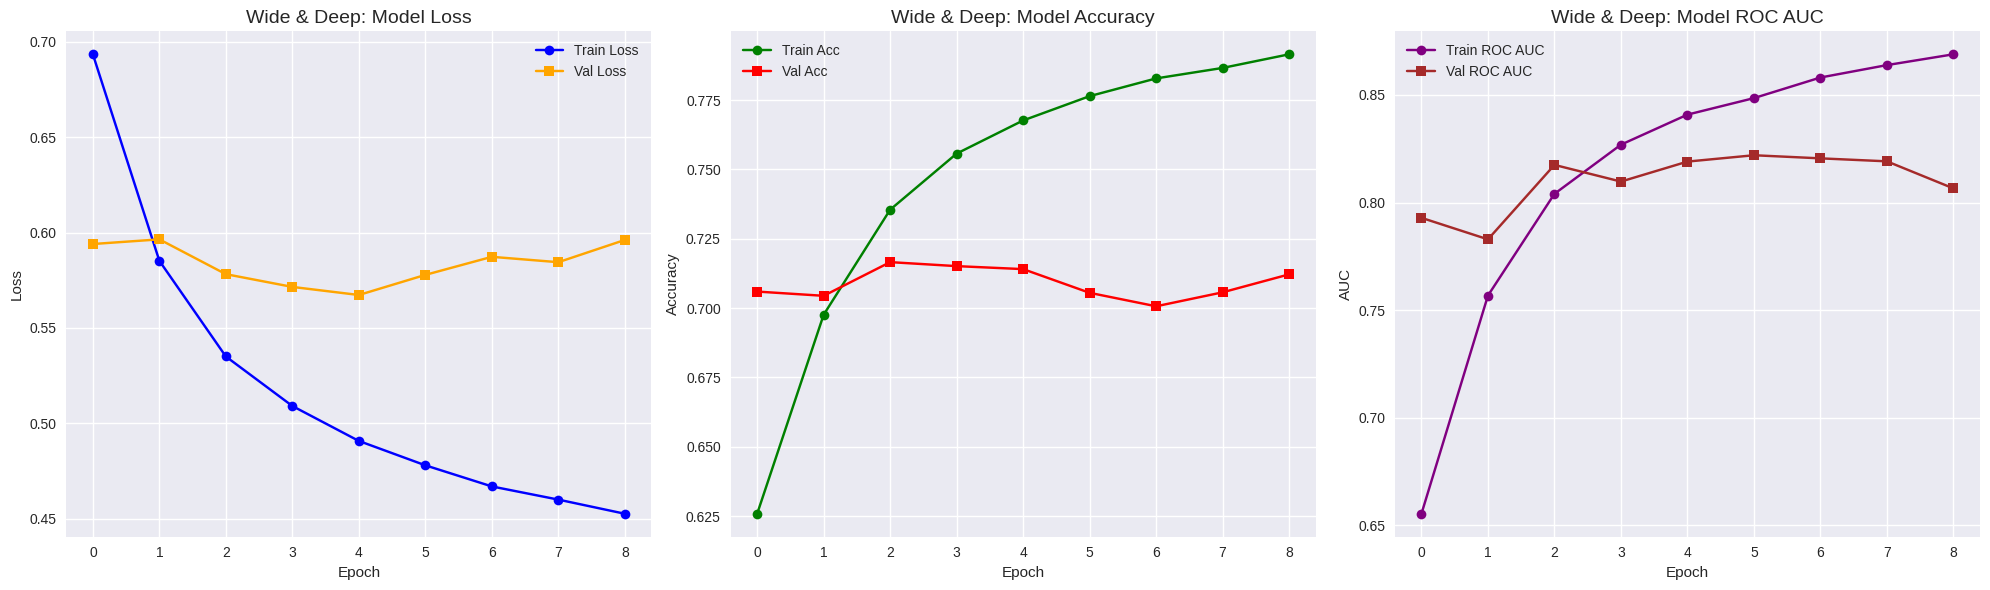

In [ ]:
import matplotlib.pyplot as plt

# 设置绘图风格
plt.style.use('seaborn-v0_8')
fig, axes = plt.subplots(1, 3, figsize=(20, 6))

# 1. 绘制 Loss 曲线
axes[0].plot(history.history['loss'], label='Train Loss', marker='o', color='b')
if 'val_loss' in history.history:
    axes[0].plot(history.history['val_loss'], label='Val Loss', marker='s', color='orange')
axes[0].set_title('Wide & Deep: Model Loss', fontsize=14)
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].legend()

# 2. 绘制 Accuracy 曲线
axes[1].plot(history.history['accuracy'], label='Train Acc', marker='o', color='g')
if 'val_accuracy' in history.history:
    axes[1].plot(history.history['val_accuracy'], label='Val Acc', marker='s', color='red')
axes[1].set_title('Wide & Deep: Model Accuracy', fontsize=14)
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy')
axes[1].legend()

# 3. 绘制 ROC AUC 曲线 (根据训练日志，指标名包含具体的后缀，如 auc_6)
# 自动检测包含 'auc' 的 key
auc_key = [k for k in history.history.keys() if 'auc' in k and 'val' not in k][0]
val_auc_key = 'val_' + auc_key if 'val_' + auc_key in history.history else None

axes[2].plot(history.history[auc_key], label='Train ROC AUC', marker='o', color='purple')
if val_auc_key:
    axes[2].plot(history.history[val_auc_key], label='Val ROC AUC', marker='s', color='brown')
axes[2].set_title('Wide & Deep: Model ROC AUC', fontsize=14)
axes[2].set_xlabel('Epoch')
axes[2].set_ylabel('AUC')
axes[2].legend()

plt.tight_layout()
plt.show()

### 1. 导出 Wide & Deep 模型
我们将模型导出到 `/content/models/wide_deep/1`。

In [ ]:
import os
import shutil

# 定义路径
# wd_export_path = "/content/models/wide_deep/1"
wd_export_path = "/content/SparrowRecSys/src/main/resources/webroot/myModels/wide_deep/1"

# 清理旧导出
if os.path.exists(wd_export_path):
    shutil.rmtree(wd_export_path)

# 导出模型
model.export(wd_export_path)
print(f"Wide & Deep 模型已导出至: {wd_export_path}")

Saved artifact at '/content/models/wide_deep/1'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): Dict[['movieAvgRating', TensorSpec(shape=(None, 1), dtype=tf.float32, name='movieAvgRating')], ['movieRatingStddev', TensorSpec(shape=(None, 1), dtype=tf.float32, name='movieRatingStddev')], ['movieRatingCount', TensorSpec(shape=(None, 1), dtype=tf.int32, name='movieRatingCount')], ['userAvgRating', TensorSpec(shape=(None, 1), dtype=tf.float32, name='userAvgRating')], ['userRatingStddev', TensorSpec(shape=(None, 1), dtype=tf.float32, name='userRatingStddev')], ['userRatingCount', TensorSpec(shape=(None, 1), dtype=tf.int32, name='userRatingCount')], ['releaseYear', TensorSpec(shape=(None, 1), dtype=tf.int32, name='releaseYear')], ['movieId', TensorSpec(shape=(None, 1), dtype=tf.int32, name='movieId')], ['userId', TensorSpec(shape=(None, 1), dtype=tf.int32, name='userId')], ['userRatedMovie1', TensorSpec(shape=(None, 1), dtype=tf.int32, name='userRatedMo

### 2. 重启 TF Serving 加载 Wide & Deep 模型

In [ ]:
import time

print("正在停止旧服务并启动 Wide & Deep 服务...")
!pkill -f tensorflow_model_server

# os.environ['WD_MODEL_BASE_PATH'] = "/content/models/wide_deep"
os.environ['WD_MODEL_BASE_PATH'] = "/content/SparrowRecSys/src/main/resources/webroot/myModels/wide_deep"

# 启动服务，命名为 sparrow_wd
!nohup tensorflow_model_server \
    --rest_api_port=8501 \
    --model_name=sparrow_wd \
    --model_base_path=$WD_MODEL_BASE_PATH \
    > server_wd.log 2>&1 &

# 等待启动并检查日志
time.sleep(5)
!tail -n 5 server_wd.log

正在停止旧服务并启动 Wide & Deep 服务...
2026-06-30 09:23:20.335012: I tensorflow_serving/model_servers/server.cc:395] Profiler service is enabled
2026-06-30 09:23:20.335670: I tensorflow_serving/model_servers/server.cc:430] Running gRPC ModelServer at 0.0.0.0:8500 ...
[warn] getaddrinfo: address family for nodename not supported
[evhttp_server.cc : 261] NET_LOG: Entering the event loop ...
2026-06-30 09:23:20.339365: I tensorflow_serving/model_servers/server.cc:451] Exporting HTTP/REST API at:localhost:8501 ...


### 3. 从测试文件中读取一条数据并进行预测
我们将直接从 `testSamplesByTimeStamp.csv` 读取一行数据进行验证。

In [ ]:
import requests
import json
import pandas as pd

# 1. 从测试文件读取一条数据 (例如第 500 行)
sample_df = pd.read_csv(test_samples_file_path).iloc[0:1]

print("--- 选取的测试样本原始特征 ---")
display(sample_df)

# 2. 构造输入数据 (需与 Wide & Deep 的输入层严格对应)
# 注意：Wide & Deep 的训练代码中包含 movieId 和 userRatedMovie1 的交叉
instance = {}

# 处理整数特征
for col in INT_FEATURES:
    instance[col] = [int(sample_df[col].fillna(0).iloc[0])]

# 处理浮点特征
for col in FLOAT_FEATURES:
    instance[col] = [float(sample_df[col].fillna(0).iloc[0])]

# 处理字符串特征
for col in STRING_FEATURES:
    instance[col] = [str(sample_df[col].fillna('None').iloc[0])]

# 3. 发送请求
predict_url = f"{public_url}/v1/models/sparrow_wd:predict"
payload = json.dumps({"instances": [instance]})
headers = {"content-type": "application/json"}

response = requests.post(predict_url, data=payload, headers=headers)

if response.status_code == 200:
    res_json = response.json()
    score = res_json['predictions'][0][0]
    print(f"\n预测点击概率 (CTR): {score:.4%}")
    print(f"实际标签 (Label): {sample_df['label'].iloc[0]}")
else:
    print(f"预测失败: {response.status_code}")
    print(response.text)

--- 选取的测试样本原始特征 ---


,movieId,userId,rating,timestamp,label,releaseYear,movieGenre1,movieGenre2,movieGenre3,movieRatingCount,...,userRatingCount,userAvgReleaseYear,userReleaseYearStddev,userAvgRating,userRatingStddev,userGenre1,userGenre2,userGenre3,userGenre4,userGenre5
0,223,9077,2.5,1247908275,0,1994,Comedy,NaN,NaN,5102,...,10,1982,15.33,3.85,0.53,Thriller,Action,Sci-Fi,Drama,Horror



预测点击概率 (CTR): 82.2570%
实际标签 (Label): 0


### 生成适用于 Windows CMD 的 Wide & Deep 模型调用命令
运行以下单元格即可获得可以直接复制到 CMD 的 `curl` 命令。

In [ ]:
import json

# 1. 构造输入数据
instance_data = {}
for col in INT_FEATURES:
    instance_data[col] = [int(sample_df[col].fillna(0).iloc[0])]
for col in FLOAT_FEATURES:
    instance_data[col] = [float(sample_df[col].fillna(0).iloc[0])]
for col in STRING_FEATURES:
    instance_data[col] = [str(sample_df[col].fillna('None').iloc[0])]

# 2. 构造 Payload
payload = {"instances": [instance_data]}
json_payload = json.dumps(payload, separators=(',', ':'))

# 3. 关键修复：为 Windows CMD 正确转义双引号 (将 " 替换为 \")
escaped_json = json_payload.replace('"', '\\\"')

# 4. 构建最终命令
cmd_command = f'curl -X POST "{public_url}/v1/models/sparrow_wd:predict" -H "Content-Type: application/json" -d "{escaped_json}"'

print("请复制以下修正后的命令到 Windows CMD 执行:\n")
print(cmd_command)

请复制以下修正后的命令到 Windows CMD 执行:

curl -X POST "https://footbath-naming-impaired.ngrok-free.dev/v1/models/sparrow_wd:predict" -H "Content-Type: application/json" -d "{\"instances\":[{\"movieRatingCount\":[13826],\"userRatingCount\":[16],\"releaseYear\":[1994],\"movieId\":[318],\"userId\":[9077],\"userRatedMovie1\":[19],\"movieAvgRating\":[4.45],\"movieRatingStddev\":[0.72],\"userAvgRating\":[3.56],\"userRatingStddev\":[0.63],\"userGenre1\":[\"Thriller\"],\"userGenre2\":[\"Drama\"],\"userGenre3\":[\"Comedy\"],\"userGenre4\":[\"Action\"],\"userGenre5\":[\"Sci-Fi\"],\"movieGenre1\":[\"Crime\"],\"movieGenre2\":[\"Drama\"],\"movieGenre3\":[\"None\"]}]}"


## NeuralCF

### 模型代码

In [11]:
"""
NeuralCF — TensorFlow 3.x 适配版（改进版）
==========================================
原代码基于 TF 2.3，使用 tf.feature_column + DenseFeatures（TF 3.x 已移除）。
本版本改用手动 Embedding 层 + Functional API，保留原始模型结构不变。

改进点（针对训练指标持续下降问题）：
1. batch_size 12 → 256（减少梯度噪声，稳定训练）
2. Embedding 加 L2 正则化（防止 Embedding 向量过拟合噪声）
3. MLP 层间加 Dropout（防止交互层过拟合）
4. 加入 ReduceLROnPlateau 学习率调度（收敛后自动降低学习率）
5. 保留早停法 + 验证集

适配要点：
1. tf.feature_column → tf.keras.layers.Embedding（手动构建嵌入层）
2. DenseFeatures 移除，直接使用 Embedding 层输出
3. 新增验证集 + 早停法（monitor='val_roc_auc', patience=5, mode='max', restore_best_weights=True）
4. 数据路径改为 Google Colab 路径
5. CSV 共 26 列，但模型只使用 movieId 和 userId，用 select_columns 过滤
"""

import tensorflow as tf

# ============================================================
# 数据路径（Google Colab）
# ============================================================
train_path = "/content/SparrowRecSys/src/main/resources/webroot/sampledata/trainingSamplesByTimeStamp.csv"
validation_path = "/content/SparrowRecSys/src/main/resources/webroot/sampledata/validationSamplesByTimeStamp.csv"
test_path = "/content/SparrowRecSys/src/main/resources/webroot/sampledata/testSamplesByTimeStamp.csv"

# ============================================================
# 超参数
# ============================================================
BATCH_SIZE = 12        # 增大 batch_size，减少梯度噪声（原代码 12）
EMBEDDING_DIM = 10      # Embedding 维度（与原代码一致）
MOVIE_BUCKETS = 1001    # movieId 的 bucket 数（与原代码一致）
USER_BUCKETS = 30001    # userId 的 bucket 数（与原代码一致）
EPOCHS = 100            # 最大训练轮数（早停法会提前终止）
L2_REG = 1e-5           # Embedding L2 正则化系数
DROPOUT_RATE = 0.2      # Dropout 比率


# ============================================================
# 数据加载
# ============================================================
def get_dataset(file_path, batch_size=BATCH_SIZE):
    """
    使用 make_csv_dataset 加载 CSV 文件为 tf.data.Dataset。
    make_csv_dataset 会自动将 CSV 列解析为字典格式 (feature_name -> tensor)，
    并将 label_name 指定的列作为标签返回。

    适配变更：
    - CSV 共 26 列，但模型只使用 movieId 和 userId 两列
    - make_csv_dataset 默认返回所有列，多余列会导致模型输入不匹配
    - 因此用 select_columns 参数只加载需要的列
    - 原代码使用 na_value="0"，这里保留以保持一致性
    """
    dataset = tf.data.experimental.make_csv_dataset(
        file_path,
        batch_size=batch_size,
        label_name='label',
        na_value="0",
        num_epochs=1,
        select_columns=['movieId', 'userId', 'label'],
        ignore_errors=True)
    return dataset


# 加载三个数据集：训练集、验证集、测试集
train_dataset = get_dataset(train_path)
validation_dataset = get_dataset(validation_path)
test_dataset = get_dataset(test_path)


# ============================================================
# 模型定义
# ============================================================
# --- 输入层 ---
inputs = {
    'movieId': tf.keras.layers.Input(name='movieId', shape=(), dtype='int32'),
    'userId': tf.keras.layers.Input(name='userId', shape=(), dtype='int32'),
}


def neural_cf_model_1(feature_inputs, movie_vocab_size, user_vocab_size, embedding_dim, hidden_units):
    """
    NeuralCF 模型架构一（原 neural_cf_model_1）：
    双塔结构 — 每个塔只有 Embedding，然后拼接后过 MLP 作为交互层。

    改进：
    - Embedding 加 L2 正则化，防止 Embedding 向量过拟合训练集噪声
    - MLP 层间加 Dropout，防止交互层过拟合
    """
    # --- Movie 塔 ---
    movie_embedding_layer = tf.keras.layers.Embedding(
        input_dim=movie_vocab_size,
        output_dim=embedding_dim,
        embeddings_regularizer=tf.keras.regularizers.l2(L2_REG),
        name='movie_embedding'
    )
    movie_tower = movie_embedding_layer(feature_inputs['movieId'])

    # --- User 塔 ---
    user_embedding_layer = tf.keras.layers.Embedding(
        input_dim=user_vocab_size,
        output_dim=embedding_dim,
        embeddings_regularizer=tf.keras.regularizers.l2(L2_REG),
        name='user_embedding'
    )
    user_tower = user_embedding_layer(feature_inputs['userId'])

    # --- 交互层 ---
    interact_layer = tf.keras.layers.concatenate([movie_tower, user_tower])
    for i, num_nodes in enumerate(hidden_units):
        interact_layer = tf.keras.layers.Dense(
            num_nodes, activation='relu', name=f'interact_dense_{i}'
        )(interact_layer)
        # 在 MLP 层间加 Dropout，防止交互层过拟合
        interact_layer = tf.keras.layers.Dropout(DROPOUT_RATE, name=f'interact_dropout_{i}')(interact_layer)

    output_layer = tf.keras.layers.Dense(1, activation='sigmoid', name='output')(interact_layer)

    model = tf.keras.Model(feature_inputs, output_layer, name='NeuralCF_model_1')
    return model


def neural_cf_model_2(feature_inputs, movie_vocab_size, user_vocab_size, embedding_dim, hidden_units):
    """
    NeuralCF 模型架构二（原 neural_cf_model_2）：
    双塔结构 — 每个塔是 Embedding + MLP，然后做 Dot Product 作为输出。

    改进与 neural_cf_model_1 相同：L2 正则化 + Dropout。
    """
    # --- Movie 塔：Embedding + MLP ---
    movie_embedding_layer = tf.keras.layers.Embedding(
        input_dim=movie_vocab_size,
        output_dim=embedding_dim,
        embeddings_regularizer=tf.keras.regularizers.l2(L2_REG),
        name='movie_embedding'
    )
    item_tower = movie_embedding_layer(feature_inputs['movieId'])
    for i, num_nodes in enumerate(hidden_units):
        item_tower = tf.keras.layers.Dense(
            num_nodes, activation='relu', name=f'item_dense_{i}'
        )(item_tower)
        item_tower = tf.keras.layers.Dropout(DROPOUT_RATE, name=f'item_dropout_{i}')(item_tower)

    # --- User 塔：Embedding + MLP ---
    user_embedding_layer = tf.keras.layers.Embedding(
        input_dim=user_vocab_size,
        output_dim=embedding_dim,
        embeddings_regularizer=tf.keras.regularizers.l2(L2_REG),
        name='user_embedding'
    )
    user_tower = user_embedding_layer(feature_inputs['userId'])
    for i, num_nodes in enumerate(hidden_units):
        user_tower = tf.keras.layers.Dense(
            num_nodes, activation='relu', name=f'user_dense_{i}'
        )(user_tower)
        user_tower = tf.keras.layers.Dropout(DROPOUT_RATE, name=f'user_dropout_{i}')(user_tower)

    # --- Dot Product 交互 ---
    output = tf.keras.layers.Dot(axes=1, name='dot_product')([item_tower, user_tower])
    output = tf.keras.layers.Dense(1, activation='sigmoid', name='output')(output)

    model = tf.keras.Model(feature_inputs, output, name='NeuralCF_model_2')
    return model


# ============================================================
# 构建模型（使用架构一，与原代码一致）
# ============================================================
model = neural_cf_model_1(
    feature_inputs=inputs,
    movie_vocab_size=MOVIE_BUCKETS,
    user_vocab_size=USER_BUCKETS,
    embedding_dim=EMBEDDING_DIM,
    hidden_units=[10, 10]
)

# ============================================================
# 编译模型
# ============================================================
model.compile(
    loss='binary_crossentropy',
    optimizer='adam',
    metrics=[
        'accuracy',
        tf.keras.metrics.AUC(curve='ROC', name='roc_auc'),
        tf.keras.metrics.AUC(curve='PR', name='pr_auc'),
    ]
)

model.summary()

# ============================================================
# 回调：早停 + 学习率调度
# ============================================================
# 早停法：监控验证集 ROC AUC，连续 5 个 epoch 无提升则停止
early_stopping = tf.keras.callbacks.EarlyStopping(
    monitor='val_roc_auc',
    patience=5,
    mode='max',
    restore_best_weights=True,
    verbose=1
)

# 学习率调度：验证集 ROC AUC 连续 3 个 epoch 无提升时，学习率减半
# 作用：收敛后自动降低学习率，避免大步更新破坏已学到的特征
reduce_lr = tf.keras.callbacks.ReduceLROnPlateau(
    monitor='val_roc_auc',
    factor=0.5,        # 学习率乘以 0.5
    patience=5,        # 3 个 epoch 无提升则触发
    mode='max',
    min_lr=1e-6,       # 学习率下限
    verbose=1
)

# ============================================================
# 训练模型
# ============================================================
print("\n=== 开始训练 ===")
history = model.fit(
    train_dataset,
    validation_data=validation_dataset,
    epochs=EPOCHS,
    callbacks=[early_stopping, reduce_lr],
    verbose=1
)

# ============================================================
# 评估模型
# ============================================================
print("\n=== 测试集评估 ===")
test_loss, test_accuracy, test_roc_auc, test_pr_auc = model.evaluate(test_dataset)
print(f'\nTest Loss: {test_loss:.4f}')
print(f'Test Accuracy: {test_accuracy:.4f}')
print(f'Test ROC AUC: {test_roc_auc:.4f}')
print(f'Test PR AUC: {test_pr_auc:.4f}')

# ============================================================
# 打印部分预测结果
# ============================================================
print("\n=== 预测示例 ===")
predictions = model.predict(test_dataset)
for prediction, goodRating in zip(predictions[:12], list(test_dataset)[0][1][:12]):
    print(f"Predicted good rating: {prediction[0]:.2%}"
          f" | Actual rating label: {'Good Rating' if bool(goodRating) else 'Bad Rating'}")

# ============================================================
# 保存模型
# ============================================================
# TF 3.x 中 model.save() 只支持 .keras / .h5 扩展名
# 原项目 Java 端需要 SavedModel 格式目录，因此用 model.export() 导出
model.export("/content/SparrowRecSys/src/main/resources/webroot/modeldata/neuralcf/002")
print("\n模型已导出到 /content/SparrowRecSys/src/main/resources/webroot/modeldata/neuralcf/002")


Instructions for updating:
Use `tf.data.Dataset.ignore_errors` instead.


Model: "NeuralCF_model_1"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ movieId             │ (None)            │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ userId (InputLayer) │ (None)            │          0 │ -                 │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ movie_embedding     │ (None, 10)        │     10,010 │ movieId[0][0]     │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ user_embedding      │ (None, 10)        │    300,010 │ userId[0][0]      │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate         │ (None, 20)        │          0 │ movie_embedding[… │
│ (Concatenate)       │                   │            │ user_embedding[0… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ interact_dense_0    │ (None, 10)        │        210 │ concatenate[0][0] │
│ (Dense)             │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ interact_dropout_0  │ (None, 10)        │          0 │ interact_dense_0… │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ interact_dense_1    │ (None, 10)        │        110 │ interact_dropout… │
│ (Dense)             │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ interact_dropout_1  │ (None, 10)        │          0 │ interact_dense_1… │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ output (Dense)      │ (None, 1)         │         11 │ interact_dropout… │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 310,351 (1.18 MB)

 Trainable params: 310,351 (1.18 MB)

 Non-trainable params: 0 (0.00 B)


=== 开始训练 ===
Epoch 1/100
   7410/Unknown 55s 7ms/step - accuracy: 0.6322 - loss: 0.6379 - pr_auc: 0.6649 - roc_auc: 0.6795

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/epoch_iterator.py:164: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()


7410/7410 ━━━━━━━━━━━━━━━━━━━━ 74s 9ms/step - accuracy: 0.6745 - loss: 0.6078 - pr_auc: 0.7455 - roc_auc: 0.7319 - val_accuracy: 0.7049 - val_loss: 0.5744 - val_pr_auc: 0.8215 - val_roc_auc: 0.7448 - learning_rate: 0.0010
Epoch 2/100
7410/7410 ━━━━━━━━━━━━━━━━━━━━ 40s 4ms/step - accuracy: 0.7268 - loss: 0.5571 - pr_auc: 0.8020 - roc_auc: 0.7925 - val_accuracy: 0.7024 - val_loss: 0.5808 - val_pr_auc: 0.8171 - val_roc_auc: 0.7405 - learning_rate: 0.0010
Epoch 3/100
7410/7410 ━━━━━━━━━━━━━━━━━━━━ 29s 4ms/step - accuracy: 0.7478 - loss: 0.5328 - pr_auc: 0.8272 - roc_auc: 0.8175 - val_accuracy: 0.7072 - val_loss: 0.5806 - val_pr_auc: 0.8162 - val_roc_auc: 0.7424 - learning_rate: 0.0010
Epoch 4/100
7410/7410 ━━━━━━━━━━━━━━━━━━━━ 30s 4ms/step - accuracy: 0.7592 - loss: 0.5153 - pr_auc: 0.8432 - roc_auc: 0.8333 - val_accuracy: 0.7028 - val_loss: 0.5924 - val_pr_auc: 0.8118 - val_roc_auc: 0.7370 - learning_rate: 0.0010
Epoch 5/100
7410/7410 ━━━━━━━━━━━━━━━━━━━━ 31s 4ms/step - accuracy: 0.7714 -

### 画图

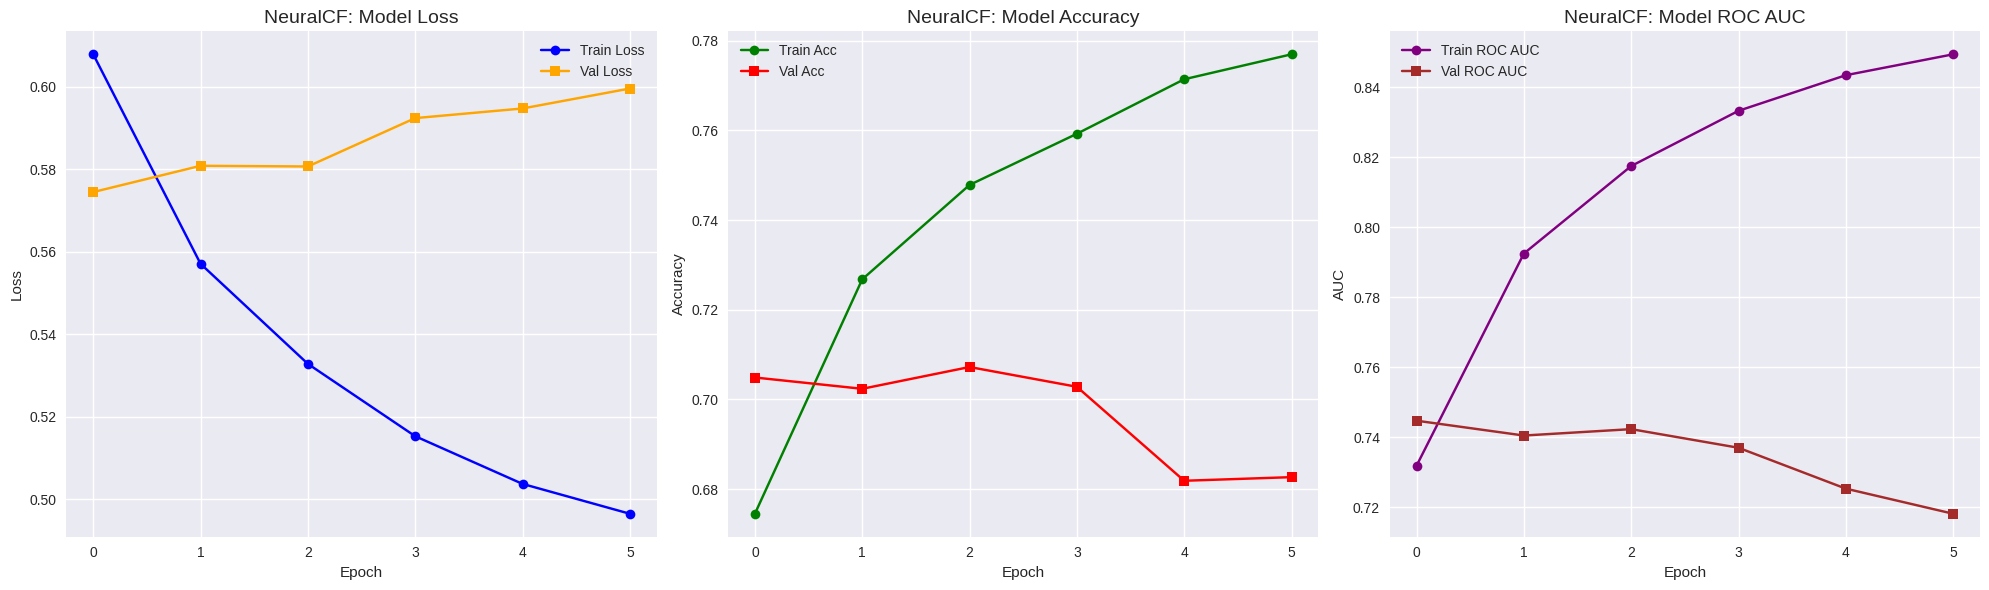

In [12]:
import matplotlib.pyplot as plt

# 设置绘图风格
plt.style.use('seaborn-v0_8')
fig, axes = plt.subplots(1, 3, figsize=(20, 6))

# 1. 绘制 Loss 曲线
axes[0].plot(history.history['loss'], label='Train Loss', marker='o', color='b')
if 'val_loss' in history.history:
    axes[0].plot(history.history['val_loss'], label='Val Loss', marker='s', color='orange')
axes[0].set_title('NeuralCF: Model Loss', fontsize=14)
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].legend()

# 2. 绘制 Accuracy 曲线
axes[1].plot(history.history['accuracy'], label='Train Acc', marker='o', color='g')
if 'val_accuracy' in history.history:
    axes[1].plot(history.history['val_accuracy'], label='Val Acc', marker='s', color='red')
axes[1].set_title('NeuralCF: Model Accuracy', fontsize=14)
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy')
axes[1].legend()

# 3. 绘制 ROC AUC 曲线
# 根据代码历史，指标名为 'roc_auc'
axes[2].plot(history.history['roc_auc'], label='Train ROC AUC', marker='o', color='purple')
if 'val_roc_auc' in history.history:
    axes[2].plot(history.history['val_roc_auc'], label='Val ROC AUC', marker='s', color='brown')
axes[2].set_title('NeuralCF: Model ROC AUC', fontsize=14)
axes[2].set_xlabel('Epoch')
axes[2].set_ylabel('AUC')
axes[2].legend()

plt.tight_layout()
plt.show()

### 1. 导出 NeuralCF 模型
我们将模型导出到 `/content/models/neuralcf/1`。

In [13]:
import os
import shutil

# 定义路径
# ncf_export_path = "/content/models/neuralcf/1"
ncf_export_path = "/content/SparrowRecSys/src/main/resources/webroot/myModels/neuralcf/1"

# 清理旧导出
if os.path.exists(ncf_export_path):
    shutil.rmtree(ncf_export_path)

# 导出模型
model.export(ncf_export_path)
print(f"NeuralCF 模型已导出至: {ncf_export_path}")

Saved artifact at '/content/SparrowRecSys/src/main/resources/webroot/myModels/neuralcf/1'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): Dict[['movieId', TensorSpec(shape=(None,), dtype=tf.int32, name='movieId')], ['userId', TensorSpec(shape=(None,), dtype=tf.int32, name='userId')]]
Output Type:
  TensorSpec(shape=(None, 1), dtype=tf.float32, name=None)
Captures:
  135969346529488: TensorSpec(shape=(), dtype=tf.resource, name=None)
  135969344105040: TensorSpec(shape=(), dtype=tf.resource, name=None)
  135969344102352: TensorSpec(shape=(), dtype=tf.resource, name=None)
  135969344104848: TensorSpec(shape=(), dtype=tf.resource, name=None)
  135969344102928: TensorSpec(shape=(), dtype=tf.resource, name=None)
  135969344104656: TensorSpec(shape=(), dtype=tf.resource, name=None)
  135969344102544: TensorSpec(shape=(), dtype=tf.resource, name=None)
  135969344106192: TensorSpec(shape=(), dtype=tf.resource, name=None)
NeuralCF 模型已导出至: /content/Sparrow

### 2. 重启 TF Serving 加载 NeuralCF 模型

In [14]:
import time

print("正在停止旧服务并启动 NeuralCF 服务...")
!pkill -f tensorflow_model_server

# os.environ['NCF_MODEL_BASE_PATH'] = "/content/models/neuralcf"
os.environ['NCF_MODEL_BASE_PATH'] = "/content/SparrowRecSys/src/main/resources/webroot/myModels/neuralcf"

# 启动服务，命名为 sparrow_ncf
!nohup tensorflow_model_server \
    --rest_api_port=8501 \
    --model_name=sparrow_ncf \
    --model_base_path=$NCF_MODEL_BASE_PATH \
    > server_ncf.log 2>&1 &

# 等待启动并检查日志
time.sleep(5)
!tail -n 5 server_ncf.log

正在停止旧服务并启动 NeuralCF 服务...
I0000 00:00:1782835582.879784    6657 server_core.cc:645]  (Re-)adding model: sparrow_ncf
I0000 00:00:1782835583.174917    6671 mlir_graph_optimization_pass.cc:437] MLIR V1 optimization pass is not enabled
I0000 00:00:1782835583.376957    6657 server_core.cc:537] Finished adding/updating models
[warn] getaddrinfo: address family for nodename not supported
[evhttp_server.cc : 261] NET_LOG: Entering the event loop ...


### 3. Python 端预测测试
从测试集中读取第一条数据进行验证。

In [15]:
import requests
import json
import pandas as pd

# 1. 读取一条测试数据
sample_df = pd.read_csv(test_path).iloc[0:1]

# --- 新增：打印读取到的数据 ---
print("--- 读取到的测试样本数据 ---")
print(sample_df.iloc[0].to_string())
print("-" * 30)

# 2. 构造输入数据 (NeuralCF)
# 根据模型签名修正：去掉外层列表，直接传入数值
instance = {
    "movieId": int(sample_df['movieId'].iloc[0]) % 1001,
    "userId": int(sample_df['userId'].iloc[0]) % 30001
}

# 3. 发送请求
predict_url = f"{public_url}/v1/models/sparrow_ncf:predict"
payload = json.dumps({"instances": [instance]})
headers = {"content-type": "application/json"}

response = requests.post(predict_url, data=payload, headers=headers)

if response.status_code == 200:
    res_json = response.json()
    score = res_json['predictions'][0][0]
    print(f"预测点击概率 (CTR): {score:.4%}")
    print(f"实际标签 (Label): {sample_df['label'].iloc[0]}")
else:
    print(f"预测失败: {response.status_code}")
    print(response.text)

--- 读取到的测试样本数据 ---
movieId                         223
userId                         9077
rating                          2.5
timestamp                1247908275
label                             0
releaseYear                    1994
movieGenre1                  Comedy
movieGenre2                     NaN
movieGenre3                     NaN
movieRatingCount               5102
movieAvgRating                 3.86
movieRatingStddev              0.97
userRatedMovie1                32.0
userRatedMovie2               735.0
userRatedMovie3               968.0
userRatedMovie4               750.0
userRatedMovie5               908.0
userRatingCount                  10
userAvgReleaseYear             1982
userReleaseYearStddev         15.33
userAvgRating                  3.85
userRatingStddev               0.53
userGenre1                 Thriller
userGenre2                   Action
userGenre3                   Sci-Fi
userGenre4                    Drama
userGenre5                   Horror
---------

### 4. 生成 Windows CMD `curl` 调用命令

In [16]:
import json

# 构造适合 NeuralCF 签名要求的 Payload (使用标量值而非数组)
instance_data = {
    "movieId": int(sample_df['movieId'].iloc[0]) % 1001,
    "userId": int(sample_df['userId'].iloc[0]) % 30001
}
payload = {"instances": [instance_data]}
json_payload = json.dumps(payload, separators=(',', ':'))

# 转义双引号供 Windows CMD 使用
escaped_json = json_payload.replace('"', '\\\"')

# 构建命令
cmd_command = f'curl -X POST "{public_url}/v1/models/sparrow_ncf:predict" -H "Content-Type: application/json" -d "{escaped_json}"'

print("请复制以下命令到 Windows CMD 执行:\n")
print(cmd_command)

请复制以下命令到 Windows CMD 执行:

curl -X POST "https://footbath-naming-impaired.ngrok-free.dev/v1/models/sparrow_ncf:predict" -H "Content-Type: application/json" -d "{\"instances\":[{\"movieId\":223,\"userId\":9077}]}"


## DeepFM

### 模型代码

In [17]:
"""
DeepFM for TensorFlow 2.20.

这个版本是从原始 DeepFM.py 迁移而来，主要适配点：
1. 移除 TensorFlow 2.3 时代的 tf.feature_column 和 DenseFeatures。
2. 使用 Keras 原生层实现 ID Embedding、StringLookup、FM 一阶项、FM 二阶交叉项和 Deep MLP。
3. 数据路径改为 Colab 中 SparrowRecSys 项目的 ByTimeStamp 数据集。
4. 增加验证集，并使用 EarlyStopping 监控 val_roc_auc。

注意：本文件只定义并运行训练流程；当前迁移过程中没有在本地执行训练代码。
"""

import tensorflow as tf
from tensorflow.keras import layers


# ============================================================
# 数据路径：Google Colab 中 SparrowRecSys 项目的样本文件
# ============================================================
train_path = "/content/SparrowRecSys/src/main/resources/webroot/sampledata/trainingSamplesByTimeStamp.csv"
validation_path = "/content/SparrowRecSys/src/main/resources/webroot/sampledata/validationSamplesByTimeStamp.csv"
test_path = "/content/SparrowRecSys/src/main/resources/webroot/sampledata/testSamplesByTimeStamp.csv"


# ============================================================
# 超参数：尽量保持原始 DeepFM.py 的结构和规模
# ============================================================
BATCH_SIZE = 12
EPOCHS = 50
EMBEDDING_DIM = 10
MOVIE_BUCKETS = 1001
USER_BUCKETS = 30001


# ============================================================
# 特征定义
# ============================================================
# 原始 DeepFM.py 中 Deep 部分使用的 7 个数值特征。
NUMERIC_FEATURES = [
    "releaseYear",
    "movieRatingCount",
    "movieAvgRating",
    "movieRatingStddev",
    "userRatingCount",
    "userAvgRating",
    "userRatingStddev",
]

# 原始 DeepFM.py 中直接参与 Embedding 的两个 ID 特征。
ID_FEATURES = ["movieId", "userId"]

# 原始 DeepFM.py 的 FM 部分只使用 userGenre1 和 movieGenre1 做一阶项与二阶交叉。
GENRE_FEATURES = ["userGenre1", "movieGenre1"]

# make_csv_dataset 只读取模型真正使用的列，避免 Keras 3 中多余列导致输入结构匹配混乱。
SELECTED_COLUMNS = NUMERIC_FEATURES + ID_FEATURES + GENRE_FEATURES + ["label"]

# 电影类型词表，保持原始 DeepFM.py 的枚举值。
GENRE_VOCAB = [
    "Film-Noir",
    "Action",
    "Adventure",
    "Horror",
    "Romance",
    "War",
    "Comedy",
    "Western",
    "Documentary",
    "Sci-Fi",
    "Drama",
    "Thriller",
    "Crime",
    "Fantasy",
    "Animation",
    "IMAX",
    "Mystery",
    "Children",
    "Musical",
]


# ============================================================
# 数据集加载与 dtype/shape 规整
# ============================================================
def _prepare_features(features, label):
    """
    将 make_csv_dataset 解析出的特征规整成 Keras Functional API 需要的输入格式。

    make_csv_dataset 返回的每一列通常是形状为 (batch,) 的 Tensor。
    这里统一扩展为 (batch, 1)，与下面 Input(shape=(1,)) 对齐。
    同时显式转换 dtype，避免 CSV 自动类型推断在不同 TF/Keras 版本中产生差异。
    """
    model_inputs = {}

    for name in NUMERIC_FEATURES:
        model_inputs[name] = tf.expand_dims(tf.cast(features[name], tf.float32), axis=-1)

    for name in ID_FEATURES:
        model_inputs[name] = tf.expand_dims(tf.cast(features[name], tf.int32), axis=-1)

    for name in GENRE_FEATURES:
        value = features[name]
        if value.dtype != tf.string:
            value = tf.strings.as_string(value)
        model_inputs[name] = tf.expand_dims(value, axis=-1)

    label = tf.expand_dims(tf.cast(label, tf.float32), axis=-1)
    return model_inputs, label


def get_dataset(file_path, shuffle=True):
    """
    从 CSV 构建 tf.data.Dataset。

    select_columns 只保留当前 DeepFM 模型需要的列和 label。
    ignore_errors=True 保留原始代码的容错行为：遇到坏样本时跳过。
    """
    dataset = tf.data.experimental.make_csv_dataset(
        file_path,
        batch_size=BATCH_SIZE,
        label_name="label",
        select_columns=SELECTED_COLUMNS,
        na_value="0",
        num_epochs=1,
        shuffle=shuffle,
        ignore_errors=True,
    )
    return dataset.map(_prepare_features, num_parallel_calls=tf.data.AUTOTUNE).prefetch(tf.data.AUTOTUNE)


# ============================================================
# Keras 输入层
# ============================================================
def build_inputs():
    """为每个模型特征创建一个命名 Input，名称必须与 Dataset 字典中的 key 一致。"""
    inputs = {}

    for name in NUMERIC_FEATURES:
        inputs[name] = layers.Input(name=name, shape=(1,), dtype=tf.float32)

    for name in ID_FEATURES:
        inputs[name] = layers.Input(name=name, shape=(1,), dtype=tf.int32)

    for name in GENRE_FEATURES:
        inputs[name] = layers.Input(name=name, shape=(1,), dtype=tf.string)

    return inputs


# ============================================================
# 特征编码辅助函数
# ============================================================
def build_id_embedding(inputs, feature_name, num_buckets, output_dim, layer_prefix):
    """
    将整数 ID 转换为稠密 Embedding。

    这对应原始代码中的：
    categorical_column_with_identity + embedding_column
    """
    embedding = layers.Embedding(
        input_dim=num_buckets,
        output_dim=output_dim,
        name=f"{layer_prefix}_{feature_name}_embedding",
    )(inputs[feature_name])
    return layers.Flatten(name=f"{layer_prefix}_{feature_name}_flatten")(embedding)


def build_genre_lookup_and_embedding(inputs, feature_name, output_dim, layer_prefix):
    """
    将 genre 字符串转换为词表索引，再转换为 Embedding。

    这对应原始代码中的：
    categorical_column_with_vocabulary_list + embedding_column
    """
    genre_index = layers.StringLookup(
        vocabulary=GENRE_VOCAB,
        mask_token=None,
        num_oov_indices=1,
        name=f"{layer_prefix}_{feature_name}_lookup",
    )(inputs[feature_name])
    embedding = layers.Embedding(
        input_dim=len(GENRE_VOCAB) + 1,
        output_dim=output_dim,
        name=f"{layer_prefix}_{feature_name}_embedding",
    )(genre_index)
    return layers.Flatten(name=f"{layer_prefix}_{feature_name}_flatten")(embedding)


def dot_product(name, left, right):
    """FM 二阶交叉中的内积，输出形状为 (batch, 1)。"""
    return layers.Dot(axes=1, name=name)([left, right])


# ============================================================
# DeepFM 模型定义
# ============================================================
def build_deepfm_model():
    """
    构建 DeepFM：
    - FM 一阶项：每个类别特征学习一个标量权重，相当于 indicator one-hot 后接线性权重。
    - FM 二阶项：对类别特征的 Embedding 做 pair-wise dot product。
    - Deep 部分：数值特征 + movieId/userId Embedding 拼接后进入 MLP。
    """
    inputs = build_inputs()

    # ---------- ID Embedding：movieId 和 userId ----------
    # 同一份 Embedding 同时用于 FM 二阶交叉和 Deep 部分，保持特征语义一致。
    movie_embedding = build_id_embedding(inputs, "movieId", MOVIE_BUCKETS, EMBEDDING_DIM, "shared")
    user_embedding = build_id_embedding(inputs, "userId", USER_BUCKETS, EMBEDDING_DIM, "shared")

    # ---------- Genre Embedding：userGenre1 和 movieGenre1 ----------
    user_genre_embedding = build_genre_lookup_and_embedding(inputs, "userGenre1", EMBEDDING_DIM, "fm")
    movie_genre_embedding = build_genre_lookup_and_embedding(inputs, "movieGenre1", EMBEDDING_DIM, "fm")

    # ---------- FM 一阶项 ----------
    # 原始实现用 indicator_column 生成 one-hot 后放入最终 Dense。
    # 这里用 output_dim=1 的 Embedding 学习每个类别的线性权重，数学上等价但更节省内存。
    movie_first_order = build_id_embedding(inputs, "movieId", MOVIE_BUCKETS, 1, "fm_first")
    user_first_order = build_id_embedding(inputs, "userId", USER_BUCKETS, 1, "fm_first")
    user_genre_first_order = build_genre_lookup_and_embedding(inputs, "userGenre1", 1, "fm_first")
    movie_genre_first_order = build_genre_lookup_and_embedding(inputs, "movieGenre1", 1, "fm_first")
    fm_first_order = layers.Add(name="fm_first_order_sum")(
        [movie_first_order, user_first_order, user_genre_first_order, movie_genre_first_order]
    )

    # ---------- FM 二阶交叉项 ----------
    # 保留原始 DeepFM.py 中的四组 pair-wise dot product。
    product_item_user = dot_product("fm_second_movie_user", movie_embedding, user_embedding)
    product_item_genre_user_genre = dot_product(
        "fm_second_movieGenre_userGenre",
        movie_genre_embedding,
        user_genre_embedding,
    )
    product_item_genre_user = dot_product(
        "fm_second_movieGenre_user",
        movie_genre_embedding,
        user_embedding,
    )
    product_user_genre_item = dot_product(
        "fm_second_userGenre_movie",
        user_genre_embedding,
        movie_embedding,
    )

    # ---------- Deep 部分 ----------
    # 数值特征已经在 Dataset 中转换为 float32 且形状为 (batch, 1)，这里直接拼接。
    deep_features = [inputs[name] for name in NUMERIC_FEATURES] + [movie_embedding, user_embedding]
    deep = layers.Concatenate(name="deep_feature_concat")(deep_features)
    deep = layers.Dense(64, activation="relu", name="deep_dense_1")(deep)
    deep = layers.Dense(64, activation="relu", name="deep_dense_2")(deep)

    # ---------- 输出层 ----------
    # 拼接 FM 一阶项、FM 二阶项和 Deep 输出，再用 sigmoid 输出二分类概率。
    concat = layers.Concatenate(name="deepfm_concat")(
        [
            fm_first_order,
            product_item_user,
            product_item_genre_user_genre,
            product_item_genre_user,
            product_user_genre_item,
            deep,
        ]
    )
    output = layers.Dense(1, activation="sigmoid", name="prediction")(concat)

    return tf.keras.Model(inputs=inputs, outputs=output, name="DeepFM_tf220")


# ============================================================
# 训练、验证、测试流程
# ============================================================
def main():
    train_dataset = get_dataset(train_path, shuffle=True)
    validation_dataset = get_dataset(validation_path, shuffle=False)
    test_dataset = get_dataset(test_path, shuffle=False)

    model = build_deepfm_model()

    model.compile(
        loss="binary_crossentropy",
        optimizer="adam",
        metrics=[
            "accuracy",
            tf.keras.metrics.AUC(curve="ROC", name="roc_auc"),
            tf.keras.metrics.AUC(curve="PR", name="pr_auc"),
        ],
    )

    # 早停法：监控验证集 ROC AUC。
    # 因为 compile 中 AUC 的名字是 roc_auc，所以验证集指标名就是 val_roc_auc。
    early_stopping = tf.keras.callbacks.EarlyStopping(
        monitor="val_roc_auc",
        patience=5,
        mode="max",
        restore_best_weights=True,
    )

    history = model.fit(
        train_dataset,
        validation_data=validation_dataset,
        epochs=EPOCHS,
        callbacks=[early_stopping],
    )

    test_loss, test_accuracy, test_roc_auc, test_pr_auc = model.evaluate(test_dataset)
    print(
        "\n\nTest Loss {}, Test Accuracy {}, Test ROC AUC {}, Test PR AUC {}".format(
            test_loss,
            test_accuracy,
            test_roc_auc,
            test_pr_auc,
        )
    )

    # 打印一个 batch 的预测结果，避免把整个 test_dataset 转成 list 占用过多内存。
    for batch_features, batch_labels in test_dataset.take(1):
        predictions = model.predict(batch_features)
        for prediction, label in zip(predictions[:12], batch_labels[:12]):
            label_value = bool(label.numpy().item())
            print(
                "Predicted good rating: {:.2%}".format(prediction[0]),
                " | Actual rating label: ",
                "Good Rating" if label_value else "Bad Rating",
            )

    return history, model

history, model=main()


Epoch 1/50
   7409/Unknown 85s 10ms/step - accuracy: 0.5500 - loss: 6.9266 - pr_auc: 0.5491 - roc_auc: 0.5615

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/epoch_iterator.py:164: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()


7410/7410 ━━━━━━━━━━━━━━━━━━━━ 91s 11ms/step - accuracy: 0.5830 - loss: 3.5080 - pr_auc: 0.6131 - roc_auc: 0.5987 - val_accuracy: 0.5438 - val_loss: 1.2577 - val_pr_auc: 0.7560 - val_roc_auc: 0.6346
Epoch 2/50
7410/7410 ━━━━━━━━━━━━━━━━━━━━ 137s 11ms/step - accuracy: 0.6859 - loss: 0.7730 - pr_auc: 0.7386 - roc_auc: 0.7379 - val_accuracy: 0.6881 - val_loss: 0.6102 - val_pr_auc: 0.8209 - val_roc_auc: 0.7427
Epoch 3/50
7410/7410 ━━━━━━━━━━━━━━━━━━━━ 83s 11ms/step - accuracy: 0.7698 - loss: 0.4846 - pr_auc: 0.8588 - roc_auc: 0.8482 - val_accuracy: 0.6990 - val_loss: 0.5914 - val_pr_auc: 0.8138 - val_roc_auc: 0.7403
Epoch 4/50
7410/7410 ━━━━━━━━━━━━━━━━━━━━ 81s 11ms/step - accuracy: 0.8092 - loss: 0.4145 - pr_auc: 0.9049 - roc_auc: 0.8909 - val_accuracy: 0.6988 - val_loss: 0.6019 - val_pr_auc: 0.8083 - val_roc_auc: 0.7363
Epoch 5/50
7410/7410 ━━━━━━━━━━━━━━━━━━━━ 81s 11ms/step - accuracy: 0.8347 - loss: 0.3652 - pr_auc: 0.9290 - roc_auc: 0.9165 - val_accuracy: 0.6933 - val_loss: 0.6142 - v

### 绘制训练曲线

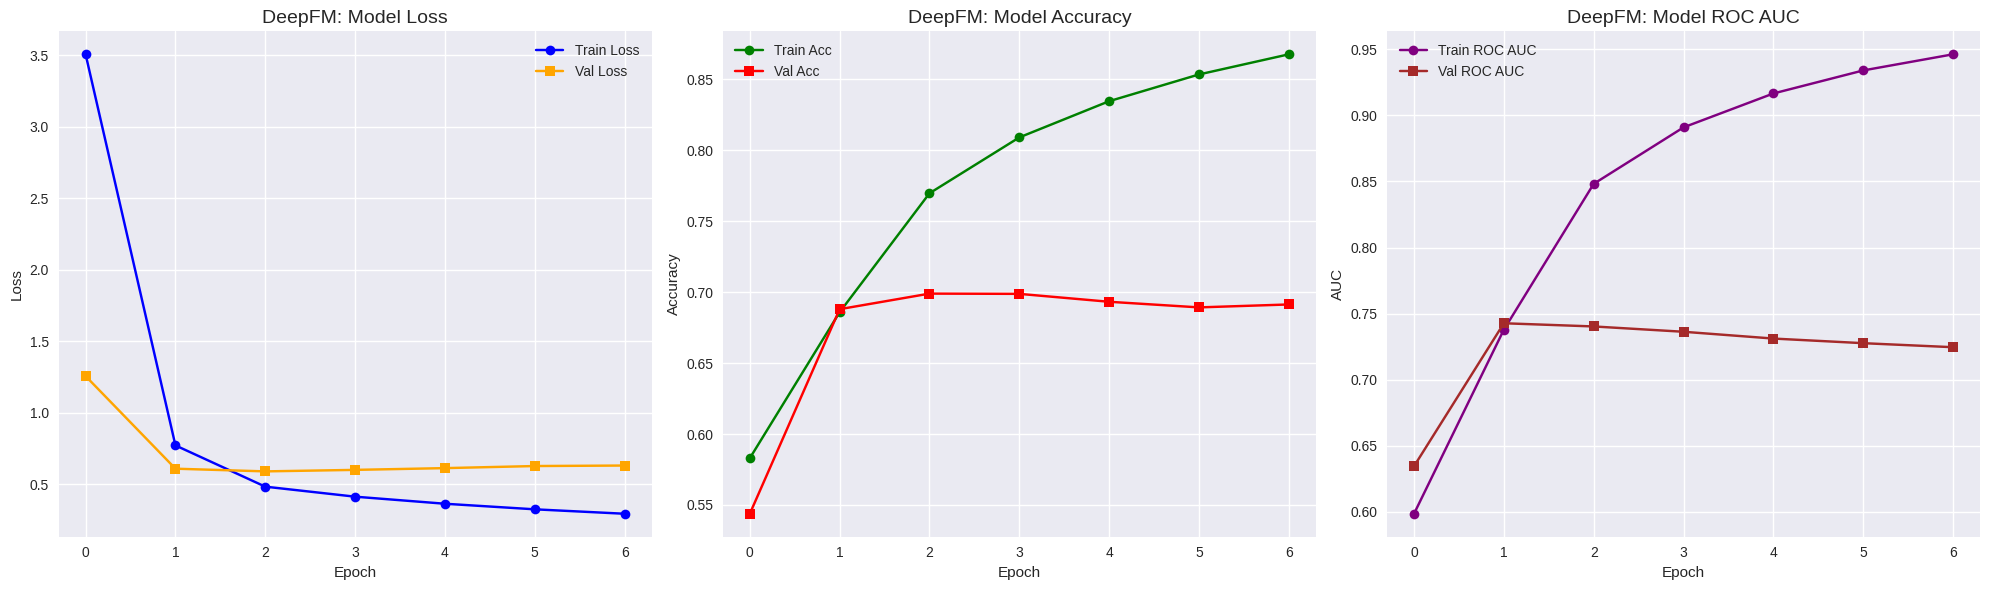

In [18]:
import matplotlib.pyplot as plt

# 设置绘图风格
plt.style.use('seaborn-v0_8')
fig, axes = plt.subplots(1, 3, figsize=(20, 6))

# 1. 绘制 Loss 曲线
axes[0].plot(history.history['loss'], label='Train Loss', marker='o', color='b')
if 'val_loss' in history.history:
    axes[0].plot(history.history['val_loss'], label='Val Loss', marker='s', color='orange')
axes[0].set_title('DeepFM: Model Loss', fontsize=14)
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].legend()

# 2. 绘制 Accuracy 曲线
axes[1].plot(history.history['accuracy'], label='Train Acc', marker='o', color='g')
if 'val_accuracy' in history.history:
    axes[1].plot(history.history['val_accuracy'], label='Val Acc', marker='s', color='red')
axes[1].set_title('DeepFM: Model Accuracy', fontsize=14)
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy')
axes[1].legend()

# 3. 绘制 ROC AUC 曲线
axes[2].plot(history.history['roc_auc'], label='Train ROC AUC', marker='o', color='purple')
if 'val_roc_auc' in history.history:
    axes[2].plot(history.history['val_roc_auc'], label='Val ROC AUC', marker='s', color='brown')
axes[2].set_title('DeepFM: Model ROC AUC', fontsize=14)
axes[2].set_xlabel('Epoch')
axes[2].set_ylabel('AUC')
axes[2].legend()

plt.tight_layout()
plt.show()

### 1. 导出 DeepFM 模型

In [19]:
import os
import shutil

# 定义路径
# dfm_export_path = "/content/models/deepfm/1"
dfm_export_path = "/content/SparrowRecSys/src/main/resources/webroot/myModels/deepfm/1"

# 清理旧导出
if os.path.exists(dfm_export_path):
    shutil.rmtree(dfm_export_path)

# 导出模型
model.export(dfm_export_path)
print(f"DeepFM 模型已导出至: {dfm_export_path}")

Saved artifact at '/content/SparrowRecSys/src/main/resources/webroot/myModels/deepfm/1'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): Dict[['releaseYear', TensorSpec(shape=(None, 1), dtype=tf.float32, name='releaseYear')], ['movieRatingCount', TensorSpec(shape=(None, 1), dtype=tf.float32, name='movieRatingCount')], ['movieAvgRating', TensorSpec(shape=(None, 1), dtype=tf.float32, name='movieAvgRating')], ['movieRatingStddev', TensorSpec(shape=(None, 1), dtype=tf.float32, name='movieRatingStddev')], ['userRatingCount', TensorSpec(shape=(None, 1), dtype=tf.float32, name='userRatingCount')], ['userAvgRating', TensorSpec(shape=(None, 1), dtype=tf.float32, name='userAvgRating')], ['userRatingStddev', TensorSpec(shape=(None, 1), dtype=tf.float32, name='userRatingStddev')], ['movieId', TensorSpec(shape=(None, 1), dtype=tf.int32, name='movieId')], ['userId', TensorSpec(shape=(None, 1), dtype=tf.int32, name='userId')], ['userGenre1', TensorSpec(shape=(No

### 2. 重启 TF Serving 加载 DeepFM 模型

In [21]:
import time

print("正在停止旧服务并启动 DeepFM 服务...")
!pkill -f tensorflow_model_server

# os.environ['DFM_MODEL_BASE_PATH'] = "/content/models/deepfm"
os.environ['DFM_MODEL_BASE_PATH']= "/content/SparrowRecSys/src/main/resources/webroot/myModels/deepfm"

# 启动服务，命名为 sparrow_dfm
!nohup tensorflow_model_server \
    --rest_api_port=8501 \
    --model_name=sparrow_dfm \
    --model_base_path=$DFM_MODEL_BASE_PATH \
    > server_dfm.log 2>&1 &

# 等待启动并检查日志
time.sleep(5)
!tail -n 5 server_dfm.log

正在停止旧服务并启动 DeepFM 服务...
I0000 00:00:1782836655.918953   13060 server_core.cc:645]  (Re-)adding model: sparrow_dfm
I0000 00:00:1782836656.473781   13066 mlir_graph_optimization_pass.cc:437] MLIR V1 optimization pass is not enabled
I0000 00:00:1782836657.114568   13060 server_core.cc:537] Finished adding/updating models
[warn] getaddrinfo: address family for nodename not supported
[evhttp_server.cc : 261] NET_LOG: Entering the event loop ...


### 3. Python 端预测测试

In [22]:
import requests
import json
import pandas as pd

# 1. 读取一条测试数据
sample_df = pd.read_csv(test_path).iloc[1:2]

print("--- 读取到的测试样本数据 ---")
print(sample_df.iloc[0].to_string())
print("-" * 30)

# 2. 构造输入数据 (修正版：确保每个特征都是 [value] 形式以匹配 shape=(1,))
instance = {}
for col in NUMERIC_FEATURES:
    instance[col] = [float(sample_df[col].fillna(0).iloc[0])]
for col in ID_FEATURES:
    instance[col] = [int(sample_df[col].iloc[0])]
for col in GENRE_FEATURES:
    instance[col] = [str(sample_df[col].fillna('None').iloc[0])]

# 3. 发送请求
predict_url = f"{public_url}/v1/models/sparrow_dfm:predict"
payload = json.dumps({"instances": [instance]})
headers = {"content-type": "application/json"}

response = requests.post(predict_url, data=payload, headers=headers)

if response.status_code == 200:
    res_json = response.json()
    score = res_json['predictions'][0][0]
    print(f"预测成功！")
    print(f"预测点击概率 (CTR): {score:.4%}")
    print(f"实际标签 (Label): {sample_df['label'].iloc[0]}")
else:
    print(f"预测失败: {response.status_code}")
    print(response.text)

--- 读取到的测试样本数据 ---
movieId                         428
userId                         9077
rating                          3.5
timestamp                1247910006
label                             1
releaseYear                    1993
movieGenre1                   Drama
movieGenre2                     NaN
movieGenre3                     NaN
movieRatingCount               1080
movieAvgRating                 3.83
movieRatingStddev              0.75
userRatedMovie1                32.0
userRatedMovie2               735.0
userRatedMovie3               968.0
userRatedMovie4               750.0
userRatedMovie5               908.0
userRatingCount                  13
userAvgReleaseYear             1985
userReleaseYearStddev         14.35
userAvgRating                  3.58
userRatingStddev                0.7
userGenre1                 Thriller
userGenre2                   Action
userGenre3                   Sci-Fi
userGenre4                    Drama
userGenre5                   Horror
---------

### 4. 生成 Windows CMD `curl` 调用命令

In [24]:
import json

# 构造 Payload (使用已修正的 instance)
payload = {"instances": [instance]}
json_payload = json.dumps(payload, separators=(',', ':'))

# 转义双引号供 Windows CMD 使用
escaped_json = json_payload.replace('"', '\\\"')

# 构建命令
cmd_command = f'curl -X POST "{public_url}/v1/models/sparrow_dfm:predict" -H "Content-Type: application/json" -d "{escaped_json}"'

print("请复制以下修正后的命令到 Windows CMD 执行:\\n")
print(cmd_command)

请复制以下修正后的命令到 Windows CMD 执行:\n
curl -X POST "https://footbath-naming-impaired.ngrok-free.dev/v1/models/sparrow_dfm:predict" -H "Content-Type: application/json" -d "{\"instances\":[{\"releaseYear\":[1993.0],\"movieRatingCount\":[1080.0],\"movieAvgRating\":[3.83],\"movieRatingStddev\":[0.75],\"userRatingCount\":[13.0],\"userAvgRating\":[3.58],\"userRatingStddev\":[0.7],\"movieId\":[428],\"userId\":[9077],\"userGenre1\":[\"Thriller\"],\"movieGenre1\":[\"Drama\"]}]}"


## DeepFM_v2

### 模型代码

In [25]:
"""
DeepFM_v2 for TensorFlow 2.20

从 DeepFM_v2.py（TF 2.3）迁移而来。

与 DeepFM_tf220.py（基于 DeepFM.py 的迁移版本）的主要区别：
  1. 一阶特征：将类别特征和数值特征分开处理，分别映射为标量后相加。
  2. 二阶特征：使用 FM 的向量化公式 (Σv)² - Σ(v²) 计算所有字段的整体交叉，
     而非逐对 dot product。
  3. Deep 部分：将所有字段的 Embedding 拼接为 3D 张量 (batch, num_fields, emb_dim)
     后展平送入 MLP，而非仅用 movie/user Embedding + 数值特征。

TF 2.20 适配要点：
  - 移除 tf.feature_column / DenseFeatures（Keras 3 已不再内置）。
  - 用 Keras 原生层（Embedding、StringLookup、Dense）替代。
  - 自定义 ReduceLayer 继承 tf.keras.layers.Layer，Keras 3 兼容。

数据路径：Google Colab 中 SparrowRecSys 项目的 ByTimeStamp 数据集。
"""

import tensorflow as tf
from tensorflow.keras import layers


# ============================================================
# 数据路径：Google Colab 中 SparrowRecSys 项目的样本文件
# ============================================================
train_path = "/content/SparrowRecSys/src/main/resources/webroot/sampledata/trainingSamplesByTimeStamp.csv"
validation_path = "/content/SparrowRecSys/src/main/resources/webroot/sampledata/validationSamplesByTimeStamp.csv"
test_path = "/content/SparrowRecSys/src/main/resources/webroot/sampledata/testSamplesByTimeStamp.csv"


# ============================================================
# 超参数
# ============================================================
BATCH_SIZE = 12       # 每个 batch 的样本数，保持与原始代码一致
EPOCHS = 50           # 最大训练轮次（配合早停法，实际轮次可能更少）
EMBEDDING_DIM = 10    # Embedding 维度，保持与原始代码一致
FM_FIELD_DIM = 64     # 二阶 FM 特征的统一映射维度（原始代码中每个字段映射到 64 维）
MOVIE_BUCKETS = 1001  # movieId 的桶数量（ID 范围 0~1000）
USER_BUCKETS = 30001  # userId 的桶数量（ID 范围 0~30000）


# ============================================================
# 特征定义
# ============================================================
# 数值特征：原始 DeepFM_v2.py 中 Deep 部分使用的 7 个数值特征
NUMERIC_FEATURES = [
    "releaseYear",
    "movieRatingCount",
    "movieAvgRating",
    "movieRatingStddev",
    "userRatingCount",
    "userAvgRating",
    "userRatingStddev",
]

# ID 特征：直接参与 Embedding 的两个整数 ID
ID_FEATURES = ["movieId", "userId"]

# 类型特征：原始 DeepFM_v2.py 中 FM 部分使用的 genre 字符串特征
GENRE_FEATURES = ["userGenre1", "movieGenre1"]

# make_csv_dataset 只读取模型真正使用的列，避免 Keras 3 中多余列导致输入结构匹配混乱
SELECTED_COLUMNS = NUMERIC_FEATURES + ID_FEATURES + GENRE_FEATURES + ["label"]

# 电影类型词表，保持原始 DeepFM_v2.py 的枚举值
GENRE_VOCAB = [
    "Film-Noir", "Action", "Adventure", "Horror", "Romance", "War",
    "Comedy", "Western", "Documentary", "Sci-Fi", "Drama", "Thriller",
    "Crime", "Fantasy", "Animation", "IMAX", "Mystery", "Children", "Musical",
]


# ============================================================
# 数据集加载与 dtype/shape 规整
# ============================================================
def _prepare_features(features, label):
    """
    将 make_csv_dataset 解析出的特征规整成 Keras Functional API 需要的输入格式。

    make_csv_dataset 返回的每一列通常是形状为 (batch,) 的 Tensor。
    这里统一扩展为 (batch, 1)，与下面 Input(shape=(1,)) 对齐。
    同时显式转换 dtype，避免 CSV 自动类型推断在不同 TF/Keras 版本中产生差异。
    """
    model_inputs = {}

    # 数值特征：转为 float32，扩展维度
    for name in NUMERIC_FEATURES:
        model_inputs[name] = tf.expand_dims(tf.cast(features[name], tf.float32), axis=-1)

    # ID 特征：转为 int32，扩展维度
    for name in ID_FEATURES:
        model_inputs[name] = tf.expand_dims(tf.cast(features[name], tf.int32), axis=-1)

    # 类型特征：确保为 string 类型，扩展维度
    for name in GENRE_FEATURES:
        value = features[name]
        if value.dtype != tf.string:
            value = tf.strings.as_string(value)
        model_inputs[name] = tf.expand_dims(value, axis=-1)

    # 标签：转为 float32，扩展维度
    label = tf.expand_dims(tf.cast(label, tf.float32), axis=-1)
    return model_inputs, label


def get_dataset(file_path, shuffle=True):
    """
    从 CSV 构建 tf.data.Dataset。

    select_columns 只保留当前模型需要的列和 label。
    ignore_errors=True 保留原始代码的容错行为：遇到坏样本时跳过。
    """
    dataset = tf.data.experimental.make_csv_dataset(
        file_path,
        batch_size=BATCH_SIZE,
        label_name="label",
        select_columns=SELECTED_COLUMNS,
        na_value="0",
        num_epochs=1,
        shuffle=shuffle,
        ignore_errors=True,
    )
    return dataset.map(_prepare_features, num_parallel_calls=tf.data.AUTOTUNE).prefetch(tf.data.AUTOTUNE)


# ============================================================
# Keras 输入层
# ============================================================
def build_inputs():
    """为每个模型特征创建一个命名 Input，名称必须与 Dataset 字典中的 key 一致。"""
    inputs = {}

    for name in NUMERIC_FEATURES:
        inputs[name] = layers.Input(name=name, shape=(1,), dtype=tf.float32)

    for name in ID_FEATURES:
        inputs[name] = layers.Input(name=name, shape=(1,), dtype=tf.int32)

    for name in GENRE_FEATURES:
        inputs[name] = layers.Input(name=name, shape=(1,), dtype=tf.string)

    return inputs


# ============================================================
# 特征编码辅助函数
# ============================================================
def build_id_embedding(inputs, feature_name, num_buckets, output_dim, layer_prefix):
    """
    将整数 ID 转换为稠密 Embedding。

    对应原始代码中的：
    categorical_column_with_identity + embedding_column
    """
    embedding = layers.Embedding(
        input_dim=num_buckets,
        output_dim=output_dim,
        name=f"{layer_prefix}_{feature_name}_embedding",
    )(inputs[feature_name])
    return layers.Flatten(name=f"{layer_prefix}_{feature_name}_flatten")(embedding)


def build_genre_lookup_and_embedding(inputs, feature_name, output_dim, layer_prefix):
    """
    将 genre 字符串转换为词表索引，再转换为 Embedding。

    对应原始代码中的：
    categorical_column_with_vocabulary_list + embedding_column
    """
    genre_index = layers.StringLookup(
        vocabulary=GENRE_VOCAB,
        mask_token=None,
        num_oov_indices=1,
        name=f"{layer_prefix}_{feature_name}_lookup",
    )(inputs[feature_name])
    embedding = layers.Embedding(
        input_dim=len(GENRE_VOCAB) + 1,  # +1 for OOV token
        output_dim=output_dim,
        name=f"{layer_prefix}_{feature_name}_embedding",
    )(genre_index)
    return layers.Flatten(name=f"{layer_prefix}_{feature_name}_flatten")(embedding)


# ============================================================
# 自定义层：ReduceLayer —— 沿指定维度求和或求均值
# ============================================================
class ReduceLayer(layers.Layer):
    """
    沿指定维度对输入张量进行规约（求和或求均值）。

    用于 FM 二阶交叉计算中的两步规约：
      1. 对所有字段的 Embedding 沿字段维度求和 → (batch, emb_dim)
      2. 对平方后的 Embedding 沿字段维度求和 → (batch, emb_dim)
    """

    def __init__(self, axis, op='sum', **kwargs):
        super().__init__(**kwargs)
        # 沿哪个维度进行规约
        self.axis = axis
        # 规约操作类型：'sum'（求和）或 'mean'（求均值）
        self.op = op
        assert self.op in ['sum', 'mean'], f"op must be 'sum' or 'mean', got '{self.op}'"

    def call(self, inputs):
        if self.op == 'sum':
            return tf.reduce_sum(inputs, axis=self.axis)
        elif self.op == 'mean':
            return tf.reduce_mean(inputs, axis=self.axis)
        # 理论上不会走到这里，保留兜底逻辑
        return tf.reduce_sum(inputs, axis=self.axis)

    def get_config(self):
        """支持模型序列化（Keras 3 要求自定义层实现此方法）。"""
        config = super().get_config()
        config.update({"axis": self.axis, "op": self.op})
        return config


# ============================================================
# DeepFM_v2 模型定义
# ============================================================
def build_deepfm_v2_model():
    """
    构建 DeepFM_v2 模型，结构与原始 DeepFM_v2.py 保持一致：

    ┌─────────────────────────────────────────────────────────────┐
    │  First Order (一阶特征)                                      │
    │  ┌──────────────┐   ┌──────────────┐                        │
    │  │ Categorical   │   │ Dense        │                        │
    │  │ (Embedding→1) │   │ (Dense→1)    │                        │
    │  └──────┬───────┘   └──────┬───────┘                        │
    │         └──── Add ─────────┘                                │
    │                                                             │
    │  Second Order (二阶特征) — FM 向量化公式                      │
    │  ┌──────────────────────────────────────────────────────┐   │
    │  │ 每个字段 Embedding → Dense(64) → Reshape(batch,1,64) │   │
    │  │ 拼接为 (batch, num_fields, 64)                        │   │
    │  │ FM: (Σv)² - Σ(v²) → (batch, 64)                     │   │
    │  └──────────────────────────────────────────────────────┘   │
    │                                                             │
    │  Deep (DNN 高阶特征)                                         │
    │  Flatten(二阶特征) → Dense(32,relu) → Dense(16,relu)        │
    │                                                             │
    │  Output                                                     │
    │  Concat(first_order, fm_second_order, deep) → sigmoid       │
    └─────────────────────────────────────────────────────────────┘
    """
    inputs = build_inputs()

    # ============================================================
    # 二阶特征：将每个字段的 Embedding 映射到统一维度并 reshape 为 3D
    # ============================================================
    # 对应原始代码中：
    #   second_order_cat_columns_emb = [DenseFeatures([item_genre_emb_col])(inputs), ...]
    #   然后每个经过 Dense(64) + Reshape((-1, 64))

    # 类型特征的 Embedding（二阶交叉用）
    second_order_genre_embs = []
    for genre_name in GENRE_FEATURES:
        emb = build_genre_lookup_and_embedding(inputs, genre_name, EMBEDDING_DIM, "second_order")
        # 映射到统一的 FM_FIELD_DIM 维度空间，再 reshape 为 (batch, 1, FM_FIELD_DIM)
        feature = layers.Dense(FM_FIELD_DIM, activation=None, name=f"second_order_{genre_name}_dense")(emb)
        feature = layers.Reshape((1, FM_FIELD_DIM), name=f"second_order_{genre_name}_reshape")(feature)
        second_order_genre_embs.append(feature)

    # ID 特征的 Embedding（二阶交叉用）
    second_order_id_embs = []
    for id_name in ID_FEATURES:
        num_buckets = MOVIE_BUCKETS if id_name == "movieId" else USER_BUCKETS
        emb = build_id_embedding(inputs, id_name, num_buckets, EMBEDDING_DIM, "second_order")
        # 映射到统一的 FM_FIELD_DIM 维度空间，再 reshape 为 (batch, 1, FM_FIELD_DIM)
        feature = layers.Dense(FM_FIELD_DIM, activation=None, name=f"second_order_{id_name}_dense")(emb)
        feature = layers.Reshape((1, FM_FIELD_DIM), name=f"second_order_{id_name}_reshape")(feature)
        second_order_id_embs.append(feature)

    # 数值特征：拼接后映射到 FM_FIELD_DIM 维度，再 reshape 为 (batch, 1, FM_FIELD_DIM)
    # 对应原始代码中：
    #   second_order_deep_columns = DenseFeatures(deep_columns)(inputs)
    #   second_order_deep_columns = Dense(64)(second_order_deep_columns)
    #   second_order_deep_columns = Reshape((-1, 64))(second_order_deep_columns)
    numeric_concat = layers.Concatenate(name="second_order_numeric_concat")(
        [inputs[name] for name in NUMERIC_FEATURES]
    )
    numeric_64d = layers.Dense(FM_FIELD_DIM, activation=None, name="second_order_numeric_dense")(numeric_concat)
    numeric_3d = layers.Reshape((1, FM_FIELD_DIM), name="second_order_numeric_reshape")(numeric_64d)

    # 沿字段维度（axis=1）拼接所有二阶特征，形成 (batch, num_fields, FM_FIELD_DIM) 的 3D 张量
    # 原始代码：4个类别字段 + 1个数值字段 = 5个字段
    second_order_fm_feature = layers.Concatenate(axis=1, name="second_order_all_fields_concat")(
        second_order_genre_embs + second_order_id_embs + [numeric_3d]
    )

    # ============================================================
    # Deep 部分（DNN）
    # ============================================================
    # 对应原始代码中：
    #   deep_feature = Flatten()(second_order_fm_feature)
    #   deep_feature = Dense(32, relu)(deep_feature)
    #   deep_feature = Dense(16, relu)(deep_feature)
    # 将二阶 FM 的 3D 特征展平后送入 DNN 进行高阶特征交叉学习
    deep_feature = layers.Flatten(name="deep_flatten")(second_order_fm_feature)
    deep_feature = layers.Dense(32, activation='relu', name="deep_dense_1")(deep_feature)
    deep_feature = layers.Dense(16, activation='relu', name="deep_dense_2")(deep_feature)

    # ============================================================
    # FM 二阶交叉特征计算（使用向量化公式优化）
    # ============================================================
    # FM 公式：0.5 * [(Σvi)² - Σ(vi²)]
    # 这里省略 0.5 系数（等价于乘以常数，不影响模型表达能力）
    #
    # 对应原始代码中的：
    #   second_order_sum_feature = ReduceLayer(1)(second_order_fm_feature)
    #   second_order_sum_square_feature = multiply([sum, sum])
    #   second_order_square_feature = multiply([fm, fm])
    #   second_order_square_sum_feature = ReduceLayer(1)(square)
    #   second_order_fm_feature = subtract([sum_square, square_sum])

    # 第一步：对所有字段的 Embedding 沿字段维度（axis=1）求和，得到 (batch, FM_FIELD_DIM)
    second_order_sum_feature = ReduceLayer(axis=1, op='sum', name="fm_reduce_sum")(second_order_fm_feature)

    # 第二步：对求和结果进行平方（逐元素自乘），得到 (batch, FM_FIELD_DIM)
    # (Σvi)² —— 先求和再平方
    second_order_sum_square = layers.Multiply(name="fm_sum_square")(
        [second_order_sum_feature, second_order_sum_feature]
    )

    # 第三步：先对每个字段的 Embedding 进行逐元素平方，得到 (batch, num_fields, FM_FIELD_DIM)
    # vi² —— 先平方
    second_order_square = layers.Multiply(name="fm_element_square")(
        [second_order_fm_feature, second_order_fm_feature]
    )

    # 第四步：对平方后的结果沿字段维度求和，得到 (batch, FM_FIELD_DIM)
    # Σ(vi²) —— 平方后再求和
    second_order_square_sum = ReduceLayer(axis=1, op='sum', name="fm_reduce_square_sum")(second_order_square)

    # 第五步：应用 FM 公式 —— (Σvi)² - Σ(vi²)，得到最终的二阶交叉特征
    # 形状为 (batch, FM_FIELD_DIM)
    fm_second_order_feature = layers.Subtract(name="fm_second_order")(
        [second_order_sum_square, second_order_square_sum]
    )

    # ============================================================
    # 一阶特征处理（First Order Features）
    # ============================================================
    # 对应原始代码中：
    #   first_order_cat_feature = DenseFeatures(cat_columns)(inputs)
    #   first_order_cat_feature = Dense(1)(first_order_cat_feature)
    #   first_order_deep_feature = DenseFeatures(deep_columns)(inputs)
    #   first_order_deep_feature = Dense(1)(first_order_deep_feature)
    #   first_order_feature = Add()([cat, deep])

    # 类别特征一阶：每个类别特征通过 output_dim=1 的 Embedding 学习标量权重
    # 数学上等价于 indicator one-hot 后接线性权重，但更节省内存
    movie_first_order = build_id_embedding(inputs, "movieId", MOVIE_BUCKETS, 1, "fm_first")
    user_first_order = build_id_embedding(inputs, "userId", USER_BUCKETS, 1, "fm_first")
    user_genre_first_order = build_genre_lookup_and_embedding(inputs, "userGenre1", 1, "fm_first")
    movie_genre_first_order = build_genre_lookup_and_embedding(inputs, "movieGenre1", 1, "fm_first")

    # 类别特征一阶求和
    first_order_cat = layers.Add(name="first_order_cat_sum")(
        [movie_first_order, user_first_order, user_genre_first_order, movie_genre_first_order]
    )

    # 数值特征一阶：拼接后通过 Dense(1) 映射为标量
    first_order_numeric_input = layers.Concatenate(name="first_order_numeric_concat")(
        [inputs[name] for name in NUMERIC_FEATURES]
    )
    first_order_deep = layers.Dense(1, activation=None, name="first_order_numeric_dense")(first_order_numeric_input)

    # 合并一阶特征：类别 + 数值
    # 对应 FM 公式中的 w0 + Σ(wi * xi) 部分
    first_order_feature = layers.Add(name="first_order_sum")([first_order_cat, first_order_deep])

    # ============================================================
    # 输出层：拼接所有特征并输出预测结果
    # ============================================================
    # first_order_feature:  (batch, 1)
    # fm_second_order_feature: (batch, FM_FIELD_DIM)
    # deep_feature:         (batch, 16)
    concatenated_outputs = layers.Concatenate(axis=1, name="deepfm_concat")(
        [first_order_feature, fm_second_order_feature, deep_feature]
    )
    output = layers.Dense(1, activation='sigmoid', name="prediction")(concatenated_outputs)

    return tf.keras.Model(inputs=inputs, outputs=output, name="DeepFM_v2_tf220")


# ============================================================
# 训练、验证、测试流程
# ============================================================
def main():
    # ----------------------------------------------------------
    # 加载数据集
    # ----------------------------------------------------------
    train_dataset = get_dataset(train_path, shuffle=True)
    validation_dataset = get_dataset(validation_path, shuffle=False)
    test_dataset = get_dataset(test_path, shuffle=False)

    # ----------------------------------------------------------
    # 构建模型
    # ----------------------------------------------------------
    model = build_deepfm_v2_model()
    model.summary()  # 打印模型结构，便于检查

    # ----------------------------------------------------------
    # 编译模型
    # ----------------------------------------------------------
    # 指定 AUC 的 name 为 "roc_auc"，这样验证集指标名就是 "val_roc_auc"，与早停法监控名一致
    model.compile(
        loss="binary_crossentropy",
        optimizer="adam",
        metrics=[
            "accuracy",
            tf.keras.metrics.AUC(curve="ROC", name="roc_auc"),
            tf.keras.metrics.AUC(curve="PR", name="pr_auc"),
        ],
    )

    # ----------------------------------------------------------
    # 早停法（EarlyStopping）
    # ----------------------------------------------------------
    # 监控验证集的 ROC AUC，如果连续 5 个 epoch 指标没提升就停止训练，
    # 停止后恢复验证集上表现最好的权重。
    early_stopping = tf.keras.callbacks.EarlyStopping(
        monitor="val_roc_auc",    # 监控验证集的 AUC
        patience=5,               # 如果连续 5 个 epoch 指标没提升就停止
        mode="max",               # 目标是最大化 AUC
        restore_best_weights=True # 停止后恢复最优权重
    )

    # ----------------------------------------------------------
    # 训练模型
    # ----------------------------------------------------------
    history = model.fit(
        train_dataset,
        validation_data=validation_dataset,
        epochs=EPOCHS,
        callbacks=[early_stopping],
    )

    # ----------------------------------------------------------
    # 在测试集上评估模型
    # ----------------------------------------------------------
    test_loss, test_accuracy, test_roc_auc, test_pr_auc = model.evaluate(test_dataset)
    print(
        "\n\nTest Loss: {}, Test Accuracy: {}, Test ROC AUC: {}, Test PR AUC: {}".format(
            test_loss, test_accuracy, test_roc_auc, test_pr_auc
        )
    )

    # ----------------------------------------------------------
    # 打印部分预测结果
    # ----------------------------------------------------------
    # 只取一个 batch，避免将整个 test_dataset 转成 list 占用过多内存
    for batch_features, batch_labels in test_dataset.take(1):
        predictions = model.predict(batch_features)
        for prediction, label in zip(predictions[:12], batch_labels[:12]):
            label_value = bool(label.numpy().item())
            print(
                "Predicted good rating: {:.2%}".format(prediction[0]),
                " | Actual rating label: ",
                "Good Rating" if label_value else "Bad Rating",
            )

    return history, model


history, model = main()

Model: "DeepFM_v2_tf220"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ userGenre1          │ (None, 1)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ movieGenre1         │ (None, 1)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ movieId             │ (None, 1)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ userId (InputLayer) │ (None, 1)         │          0 │ -                 │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ second_order_userG… │ (None, 1)         │          0 │ userGenre1[0][0]  │
│ (StringLookup)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ second_order_movie… │ (None, 1)         │          0 │ movieGenre1[0][0] │
│ (StringLookup)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ releaseYear         │ (None, 1)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ movieRatingCount    │ (None, 1)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ movieAvgRating      │ (None, 1)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ movieRatingStddev   │ (None, 1)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ userRatingCount     │ (None, 1)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ userAvgRating       │ (None, 1)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ userRatingStddev    │ (None, 1)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ second_order_userG… │ (None, 1, 10)     │        200 │ second_order_use… │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ second_order_movie… │ (None, 1, 10)     │        200 │ second_order_mov… │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ second_order_movie… │ (None, 1, 10)     │     10,010 │ movieId[0][0]     │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ second_order_userI… │ (None, 1, 10)     │    300,010 │ userId[0][0]      │
│ (Embedding)         │                   │            │                 

 Total params: 355,680 (1.36 MB)

 Trainable params: 355,680 (1.36 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/50
   7409/Unknown 136s 18ms/step - accuracy: 0.5766 - loss: 4.3897 - pr_auc: 0.5706 - roc_auc: 0.5902

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/epoch_iterator.py:164: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()


7410/7410 ━━━━━━━━━━━━━━━━━━━━ 145s 19ms/step - accuracy: 0.6192 - loss: 1.7689 - pr_auc: 0.6353 - roc_auc: 0.6364 - val_accuracy: 0.6908 - val_loss: 0.6028 - val_pr_auc: 0.7957 - val_roc_auc: 0.7122
Epoch 2/50
7410/7410 ━━━━━━━━━━━━━━━━━━━━ 113s 15ms/step - accuracy: 0.6992 - loss: 0.5805 - pr_auc: 0.7766 - roc_auc: 0.7672 - val_accuracy: 0.7044 - val_loss: 0.5941 - val_pr_auc: 0.8093 - val_roc_auc: 0.7307
Epoch 3/50
7410/7410 ━━━━━━━━━━━━━━━━━━━━ 106s 14ms/step - accuracy: 0.7441 - loss: 0.5169 - pr_auc: 0.8362 - roc_auc: 0.8221 - val_accuracy: 0.6862 - val_loss: 0.5932 - val_pr_auc: 0.8150 - val_roc_auc: 0.7353
Epoch 4/50
7410/7410 ━━━━━━━━━━━━━━━━━━━━ 163s 22ms/step - accuracy: 0.7678 - loss: 0.4780 - pr_auc: 0.8674 - roc_auc: 0.8507 - val_accuracy: 0.6818 - val_loss: 0.6006 - val_pr_auc: 0.8075 - val_roc_auc: 0.7329
Epoch 5/50
7410/7410 ━━━━━━━━━━━━━━━━━━━━ 107s 14ms/step - accuracy: 0.7834 - loss: 0.4523 - pr_auc: 0.8839 - roc_auc: 0.8680 - val_accuracy: 0.6818 - val_loss: 0.6026

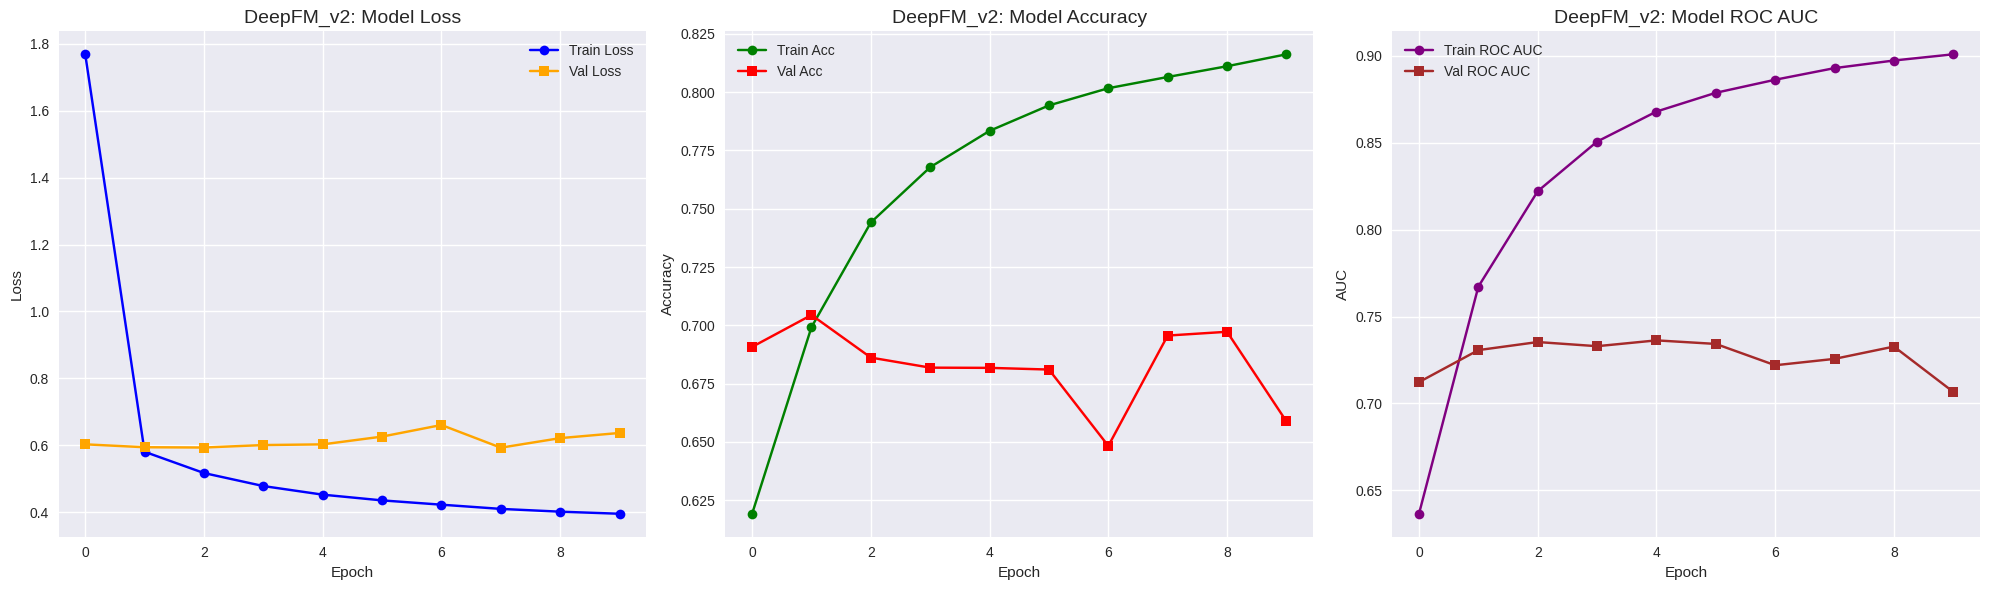

In [26]:
import matplotlib.pyplot as plt

# 1. 绘制训练曲线
plt.style.use('seaborn-v0_8')
fig, axes = plt.subplots(1, 3, figsize=(20, 6))

# Loss
axes[0].plot(history.history['loss'], label='Train Loss', marker='o', color='b')
if 'val_loss' in history.history:
    axes[0].plot(history.history['val_loss'], label='Val Loss', marker='s', color='orange')
axes[0].set_title('DeepFM_v2: Model Loss', fontsize=14)
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].legend()

# Accuracy
axes[1].plot(history.history['accuracy'], label='Train Acc', marker='o', color='g')
if 'val_accuracy' in history.history:
    axes[1].plot(history.history['val_accuracy'], label='Val Acc', marker='s', color='red')
axes[1].set_title('DeepFM_v2: Model Accuracy', fontsize=14)
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy')
axes[1].legend()

# ROC AUC
axes[2].plot(history.history['roc_auc'], label='Train ROC AUC', marker='o', color='purple')
if 'val_roc_auc' in history.history:
    axes[2].plot(history.history['val_roc_auc'], label='Val ROC AUC', marker='s', color='brown')
axes[2].set_title('DeepFM_v2: Model ROC AUC', fontsize=14)
axes[2].set_xlabel('Epoch')
axes[2].set_ylabel('AUC')
axes[2].legend()

plt.tight_layout()
plt.show()

### 1. 导出 DeepFM_v2 模型
我们将模型导出到 `/content/models/deepfm_v2/1`。

In [27]:
import os
import shutil

# 定义导出路径
# dfm_v2_export_path = "/content/models/deepfm_v2/1"
dfm_v2_export_path = "/content/SparrowRecSys/src/main/resources/webroot/myModels/deepfm_v2/1"

# 清理旧导出
if os.path.exists(dfm_v2_export_path):
    shutil.rmtree(dfm_v2_export_path)

# 导出模型
model.export(dfm_v2_export_path)
print(f"DeepFM_v2 模型已成功导出至: {dfm_v2_export_path}")

Saved artifact at '/content/SparrowRecSys/src/main/resources/webroot/myModels/deepfm_v2/1'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): Dict[['releaseYear', TensorSpec(shape=(None, 1), dtype=tf.float32, name='releaseYear')], ['movieRatingCount', TensorSpec(shape=(None, 1), dtype=tf.float32, name='movieRatingCount')], ['movieAvgRating', TensorSpec(shape=(None, 1), dtype=tf.float32, name='movieAvgRating')], ['movieRatingStddev', TensorSpec(shape=(None, 1), dtype=tf.float32, name='movieRatingStddev')], ['userRatingCount', TensorSpec(shape=(None, 1), dtype=tf.float32, name='userRatingCount')], ['userAvgRating', TensorSpec(shape=(None, 1), dtype=tf.float32, name='userAvgRating')], ['userRatingStddev', TensorSpec(shape=(None, 1), dtype=tf.float32, name='userRatingStddev')], ['movieId', TensorSpec(shape=(None, 1), dtype=tf.int32, name='movieId')], ['userId', TensorSpec(shape=(None, 1), dtype=tf.int32, name='userId')], ['userGenre1', TensorSpec(shape=

### 2. 重启 TF Serving 加载新模型
停止当前服务并启动专门加载 `deepfm_v2` 的新实例。

In [28]:
import time

print("正在停止旧服务并启动 DeepFM_v2 服务...")
!pkill -f tensorflow_model_server

# os.environ['DFM_V2_BASE_PATH'] = "/content/models/deepfm_v2"
os.environ['DFM_V2_BASE_PATH'] = "/content/SparrowRecSys/src/main/resources/webroot/myModels/deepfm_v2"

# 启动服务，命名为 sparrow_dfm_v2
!nohup tensorflow_model_server \
    --rest_api_port=8501 \
    --model_name=sparrow_dfm_v2 \
    --model_base_path=$DFM_V2_BASE_PATH \
    > server_dfm_v2.log 2>&1 &

# 等待启动
time.sleep(5)
!tail -n 5 server_dfm_v2.log

正在停止旧服务并启动 DeepFM_v2 服务...
I0000 00:00:1782838550.908941   22832 server_core.cc:645]  (Re-)adding model: sparrow_dfm_v2
I0000 00:00:1782838551.212513   22840 mlir_graph_optimization_pass.cc:437] MLIR V1 optimization pass is not enabled
I0000 00:00:1782838551.519676   22832 server_core.cc:537] Finished adding/updating models
[warn] getaddrinfo: address family for nodename not supported
[evhttp_server.cc : 261] NET_LOG: Entering the event loop ...


### 3. 预测测试与 Curl 命令生成
提取测试集数据验证 API，并生成 Windows CMD 兼容的命令。

这里有一个提示词：我希望最后出来的curl命令，可以有一个按钮，可以让我点击一下这个按钮我就复制好了

In [29]:
import requests
import json
import pandas as pd
from IPython.display import display, HTML

# 1. 准备测试数据
sample_df = pd.read_csv(test_path).iloc[1:2]

print("--- 准备测试的样本数据 ---")
display(sample_df)
print("-" * 30)

instance = {}
for col in NUMERIC_FEATURES:
    instance[col] = [float(sample_df[col].fillna(0).iloc[0])]
for col in ID_FEATURES:
    instance[col] = [int(sample_df[col].iloc[0])]
for col in GENRE_FEATURES:
    instance[col] = [str(sample_df[col].fillna('None').iloc[0])]

# 2. Python 请求验证
predict_url = f"{public_url}/v1/models/sparrow_dfm_v2:predict"
payload = {"instances": [instance]}
response = requests.post(predict_url, json=payload)

if response.status_code == 200:
    print(f"Python 预测成功！CTR: {response.json()['predictions'][0][0]:.4%}")
else:
    print(f"预测失败: {response.text}")

# 3. 生成 Windows Curl 命令
json_payload = json.dumps(payload, separators=(',', ':'))
# 在 Python 中生成带反斜杠转义的字符串
escaped_json = json_payload.replace('"', '\\\"')
cmd_command = f'curl -X POST "{public_url}/v1/models/sparrow_dfm_v2:predict" -H "Content-Type: application/json" -d "{escaped_json}"'

print("\n请复制以下命令到 Windows CMD 执行:\n")
print(cmd_command)

# 4. 增加一键复制按钮 (修复 JavaScript 字符串转义逻辑)
# 注意：为了让 JS 里的字符串保留反斜杠，我们需要在 Python 字符串里使用双重转义
js_safe_command = cmd_command.replace('\\', '\\\\')

html_code = f"""
<button onclick="copyToClipboard()" style="cursor:pointer; background-color: #4CAF50; color: white; padding: 10px 20px; border: none; border-radius: 5px; font-size: 16px;">
    📋 点击复制 Windows CMD 专用命令
</button>

<script>
function copyToClipboard() {{
    const textToCopy = `{js_safe_command}`;
    const tempInput = document.createElement('textarea');
    tempInput.value = textToCopy;
    document.body.appendChild(tempInput);
    tempInput.select();
    document.execCommand('copy');
    document.body.removeChild(tempInput);
    alert('Windows CMD 命令已成功复制！');
}}
</script>
"""
display(HTML(html_code))

--- 准备测试的样本数据 ---


,movieId,userId,rating,timestamp,label,releaseYear,movieGenre1,movieGenre2,movieGenre3,movieRatingCount,...,userRatingCount,userAvgReleaseYear,userReleaseYearStddev,userAvgRating,userRatingStddev,userGenre1,userGenre2,userGenre3,userGenre4,userGenre5
1,428,9077,3.5,1247910006,1,1993,Drama,NaN,NaN,1080,...,13,1985,14.35,3.58,0.7,Thriller,Action,Sci-Fi,Drama,Horror


------------------------------
Python 预测成功！CTR: 89.6564%

请复制以下命令到 Windows CMD 执行:

curl -X POST "https://footbath-naming-impaired.ngrok-free.dev/v1/models/sparrow_dfm_v2:predict" -H "Content-Type: application/json" -d "{\"instances\":[{\"releaseYear\":[1993.0],\"movieRatingCount\":[1080.0],\"movieAvgRating\":[3.83],\"movieRatingStddev\":[0.75],\"userRatingCount\":[13.0],\"userAvgRating\":[3.58],\"userRatingStddev\":[0.7],\"movieId\":[428],\"userId\":[9077],\"userGenre1\":[\"Thriller\"],\"movieGenre1\":[\"Drama\"]}]}"


## DIN

### 模型代码

In [ ]:
"""
DIN (Deep Interest Network) for TensorFlow 2.20

从 DIN.py（TF 2.3）迁移而来。

DIN 的核心思想：
  用户的历史行为序列（最近看过的电影）对预测候选电影的点击率有不同的重要性。
  DIN 使用 Attention 机制（Activation Unit）来计算候选电影与每部历史电影的相似度，
  以此对历史行为 Embedding 进行加权求和，突出与候选电影相关的历史行为。

模型结构：
  ┌──────────────────────────────────────────────────────────────────────┐
  │  候选电影：movieId → 共享 Movie Embedding → (batch, emb_dim)         │
  │  历史行为：userRatedMovie1-5 → 共享 Movie Embedding → (batch, 5, emb) │
  │                                                                      │
  │  Activation Unit（注意力机制）：                                       │
  │    [历史行为 - 候选, 历史行为, 候选, 历史行为 * 候选] → Dense → σ → 权重 │
  │    加权求和历史行为 → (batch, emb_dim)                                │
  │                                                                      │
  │  用户画像：userId Emb + userGenre1 Emb + 3 数值特征                   │
  │  上下文特征：movieGenre1 Emb + 4 数值特征                             │
  │                                                                      │
  │  全连接层：Concat → Dense(128,PReLU) → Dense(64,PReLU) → sigmoid     │
  └──────────────────────────────────────────────────────────────────────┘

TF 2.20 适配要点：
  - 移除 tf.feature_column / DenseFeatures（Keras 3 已不再内置）。
  - 用 Keras 原生层（Embedding、StringLookup、Dense）替代。
  - Lambda 层内部使用 tf.reduce_sum（替代 tf.keras.backend.sum）。

数据路径：Google Colab 中 SparrowRecSys 项目的 ByTimeStamp 数据集。
"""

import tensorflow as tf
from tensorflow.keras import layers
import keras.ops as ops


# ============================================================
# 数据路径：Google Colab 中 SparrowRecSys 项目的样本文件
# ============================================================
train_path = "/content/SparrowRecSys/src/main/resources/webroot/sampledata/trainingSamplesByTimeStamp.csv"
validation_path = "/content/SparrowRecSys/src/main/resources/webroot/sampledata/validationSamplesByTimeStamp.csv"
test_path = "/content/SparrowRecSys/src/main/resources/webroot/sampledata/testSamplesByTimeStamp.csv"


# ============================================================
# 超参数
# ============================================================
BATCH_SIZE = 12         # 每个 batch 的样本数，保持与原始代码一致
EPOCHS = 50             # 最大训练轮次（配合早停法，实际轮次可能更少）
EMBEDDING_SIZE = 10     # Embedding 维度，保持与原始代码一致
RECENT_MOVIES = 5       # 用户历史行为序列长度（userRatedMovie{1-5}）
MOVIE_BUCKETS = 1001    # movieId 的桶数量（ID 范围 0~1000）
USER_BUCKETS = 30001    # userId 的桶数量（ID 范围 0~30000）


# ============================================================
# 特征定义
# ============================================================
# 数值特征：原始 DIN.py 中用于 user_profile 和 context_features 的 7 个数值特征
NUMERIC_FEATURES = [
    "releaseYear",          # 电影上映年份
    "movieRatingCount",     # 电影被评分次数
    "movieAvgRating",       # 电影平均评分
    "movieRatingStddev",    # 电影评分标准差
    "userRatingCount",      # 用户评分次数
    "userAvgRating",        # 用户平均评分
    "userRatingStddev",     # 用户评分标准差
]

# ID 特征
ID_FEATURES = ["movieId", "userId"]

# 用户行为序列：用户最近评分过的 5 部电影的 ID
# DIN 的核心输入——用于构建用户兴趣序列
BEHAVIOR_FEATURES = [
    "userRatedMovie1",
    "userRatedMovie2",
    "userRatedMovie3",
    "userRatedMovie4",
    "userRatedMovie5",
]

# 类型特征：原始 DIN.py 中实际参与模型计算的 genre 特征
# 注意：原始代码的 inputs dict 中定义了 userGenre1-5 和 movieGenre1-3，
# 但只有 userGenre1 和 movieGenre1 实际被 DenseFeatures 使用。
# 这里只保留实际使用的列，未使用的 genre 列（userGenre2-5, movieGenre2-3）
# 不参与模型构建，避免 Keras 3 中多余的 Input 导致输入结构匹配混乱。
GENRE_FEATURES = ["userGenre1", "movieGenre1"]

# make_csv_dataset 只读取模型真正使用的列
SELECTED_COLUMNS = NUMERIC_FEATURES + ID_FEATURES + BEHAVIOR_FEATURES + GENRE_FEATURES + ["label"]

# 电影类型词表，保持原始 DIN.py 的枚举值
GENRE_VOCAB = [
    "Film-Noir", "Action", "Adventure", "Horror", "Romance", "War",
    "Comedy", "Western", "Documentary", "Sci-Fi", "Drama", "Thriller",
    "Crime", "Fantasy", "Animation", "IMAX", "Mystery", "Children", "Musical",
]


# ============================================================
# 数据集加载与 dtype/shape 规整
# ============================================================
def _prepare_features(features, label):
    """
    将 make_csv_dataset 解析出的特征规整成 Keras Functional API 需要的输入格式。

    make_csv_dataset 返回的每一列通常是形状为 (batch,) 的 Tensor。
    这里统一扩展为 (batch, 1)，与下面 Input(shape=(1,)) 对齐。
    同时显式转换 dtype，避免 CSV 自动类型推断在不同 TF/Keras 版本中产生差异。
    """
    model_inputs = {}

    # 数值特征：转为 float32，扩展维度 → (batch, 1)
    for name in NUMERIC_FEATURES:
        model_inputs[name] = tf.expand_dims(tf.cast(features[name], tf.float32), axis=-1)

    # ID 特征：转为 int32，扩展维度 → (batch, 1)
    for name in ID_FEATURES:
        model_inputs[name] = tf.expand_dims(tf.cast(features[name], tf.int32), axis=-1)

    # 用户行为序列：转为 int32，扩展维度 → (batch, 1)
    # userRatedMovie1-5 存储的是电影 ID（整数），不是评分
    for name in BEHAVIOR_FEATURES:
        model_inputs[name] = tf.expand_dims(tf.cast(features[name], tf.int32), axis=-1)

    # 类型特征：确保为 string 类型，扩展维度 → (batch, 1)
    for name in GENRE_FEATURES:
        value = features[name]
        if value.dtype != tf.string:
            value = tf.strings.as_string(value)
        model_inputs[name] = tf.expand_dims(value, axis=-1)

    # 标签：转为 float32，扩展维度 → (batch, 1)
    label = tf.expand_dims(tf.cast(label, tf.float32), axis=-1)
    return model_inputs, label


def get_dataset(file_path, shuffle=True):
    """
    从 CSV 构建 tf.data.Dataset。

    select_columns 只保留当前 DIN 模型需要的列和 label。
    ignore_errors=True 保留原始代码的容错行为：遇到坏样本时跳过。
    """
    dataset = tf.data.experimental.make_csv_dataset(
        file_path,
        batch_size=BATCH_SIZE,
        label_name="label",
        select_columns=SELECTED_COLUMNS,
        na_value="0",
        num_epochs=1,
        shuffle=shuffle,
        ignore_errors=True,
    )
    return dataset.map(_prepare_features, num_parallel_calls=tf.data.AUTOTUNE).prefetch(tf.data.AUTOTUNE)


# ============================================================
# Keras 输入层
# ============================================================
def build_inputs():
    """
    为每个模型特征创建一个命名 Input，名称必须与 Dataset 字典中的 key 一致。

    与原始 DIN.py 的差异：
      - 原始代码定义了 userGenre1-5 和 movieGenre1-3 的 Input，但只有 userGenre1
        和 movieGenre1 实际被 DenseFeatures 使用，其余是"幽灵输入"。
      - 这里只定义模型实际使用的输入，更干净且与 SELECTED_COLUMNS 对齐。
    """
    inputs = {}

    # 数值特征
    for name in NUMERIC_FEATURES:
        inputs[name] = layers.Input(name=name, shape=(1,), dtype=tf.float32)

    # ID 特征
    for name in ID_FEATURES:
        inputs[name] = layers.Input(name=name, shape=(1,), dtype=tf.int32)

    # 用户行为序列（电影 ID）
    for name in BEHAVIOR_FEATURES:
        inputs[name] = layers.Input(name=name, shape=(1,), dtype=tf.int32)

    # 类型特征
    for name in GENRE_FEATURES:
        inputs[name] = layers.Input(name=name, shape=(1,), dtype=tf.string)

    return inputs


# ============================================================
# 特征编码辅助函数
# ============================================================
def build_id_embedding(inputs, feature_name, num_buckets, output_dim, layer_prefix):
    """
    将整数 ID 转换为稠密 Embedding。

    对应原始代码中的：
    categorical_column_with_identity + embedding_column
    """
    embedding = layers.Embedding(
        input_dim=num_buckets,
        output_dim=output_dim,
        name=f"{layer_prefix}_{feature_name}_embedding",
    )(inputs[feature_name])
    return layers.Flatten(name=f"{layer_prefix}_{feature_name}_flatten")(embedding)


def build_genre_lookup_and_embedding(inputs, feature_name, output_dim, layer_prefix):
    """
    将 genre 字符串转换为词表索引，再转换为 Embedding。

    对应原始代码中的：
    categorical_column_with_vocabulary_list + embedding_column
    """
    genre_index = layers.StringLookup(
        vocabulary=GENRE_VOCAB,
        mask_token=None,
        num_oov_indices=1,
        name=f"{layer_prefix}_{feature_name}_lookup",
    )(inputs[feature_name])
    embedding = layers.Embedding(
        input_dim=len(GENRE_VOCAB) + 1,  # +1 for OOV token
        output_dim=output_dim,
        name=f"{layer_prefix}_{feature_name}_embedding",
    )(genre_index)
    return layers.Flatten(name=f"{layer_prefix}_{feature_name}_flatten")(embedding)


# ============================================================
# DIN 模型定义
# ============================================================
def build_din_model():
    """
    构建 DIN (Deep Interest Network) 模型。

    DIN 的关键创新是 Activation Unit（注意力机制）：
      候选电影 Embedding 与每部历史电影 Embedding 一起输入一个小网络，
      计算出每部历史电影的"注意力权重"，然后对历史行为 Embedding 做加权求和。

    与原始 DIN.py 的结构完全对应，只是特征处理层从 DenseFeatures 改为 Keras 原生层。
    """
    inputs = build_inputs()

    # ============================================================
    # 共享 Movie Embedding 层
    # ============================================================
    # 候选电影和用户历史行为中的电影使用同一个 Embedding 空间。
    # 这样候选电影和历史电影的 Embedding 可以直接做减法/乘法等运算。
    # 对应原始代码：
    #   movie_emb_layer = Embedding(input_dim=1001, output_dim=EMBEDDING_SIZE, mask_zero=True)
    #   user_behaviors_emb_layer = movie_emb_layer(user_behaviors_layer)
    #   candidate_emb_layer = movie_emb_layer(candidate_layer)
    shared_movie_embedding = layers.Embedding(
        input_dim=MOVIE_BUCKETS,
        output_dim=EMBEDDING_SIZE,
        mask_zero=True,  # 掩码 ID=0 的位置（表示缺失的用户历史电影）
        name="shared_movie_embedding",
    )

    # ============================================================
    # 候选电影 Embedding
    # ============================================================
    # 对应原始代码：
    #   candidate_layer = DenseFeatures(candidate_movie_col)(inputs)  # movieId as numeric
    #   candidate_emb_layer = movie_emb_layer(candidate_layer)
    #   candidate_emb_layer = tf.squeeze(candidate_emb_layer, axis=1)
    # 输入 movieId → (batch, 1) → Embedding → (batch, 1, emb) → squeeze → (batch, emb)
    candidate_emb = shared_movie_embedding(inputs["movieId"])
    candidate_emb = ops.squeeze(candidate_emb, axis=1)  # 移除序列维度 → (batch, EMBEDDING_SIZE)

    # ============================================================
    # 用户行为序列 Embedding
    # ============================================================
    # 对应原始代码：
    #   user_behaviors_layer = DenseFeatures(recent_rate_col)(inputs)  # userRatedMovie1-5
    #   user_behaviors_emb_layer = movie_emb_layer(user_behaviors_layer)
    # 将 userRatedMovie1-5 沿 axis=1 拼接为 (batch, 5) 的张量
    behavior_ids = layers.Concatenate(axis=1, name="behavior_ids_concat")(
        [inputs[name] for name in BEHAVIOR_FEATURES]
    )
    # Embedding 查找 → (batch, 5, EMBEDDING_SIZE)
    user_behaviors_emb = shared_movie_embedding(behavior_ids)

    # ============================================================
    # Activation Unit（注意力机制）—— DIN 的核心
    # ============================================================
    # 对应原始代码中的注意力计算部分：
    #   repeated_candidate = RepeatVector(5)(candidate_emb)  # → (batch, 5, emb)
    #   sub = Subtract()([behaviors, repeated_candidate])
    #   mul = Multiply()([behaviors, repeated_candidate])
    #   concat = concatenate([sub, behaviors, repeated_candidate, mul])
    #   attn = Dense(32)(concat) → PReLU → Dense(1, sigmoid) → Flatten
    #   attn = RepeatVector(emb)(attn) → Permute → (batch, 5, emb)
    #   weighted = Multiply()([behaviors, attn])
    #   pooled = Lambda(sum, axis=1)(weighted)

    # 将候选电影 Embedding 扩展到与行为序列相同的序列长度
    # (batch, emb) → (batch, RECENT_MOVIES, emb)
    repeated_candidate = layers.RepeatVector(RECENT_MOVIES, name="repeat_candidate")(candidate_emb)

    # 计算候选与历史行为的差异和交互
    # 对应原始代码中的 Subtract 和 Multiply
    activation_sub = layers.Subtract(name="activation_subtract")(
        [user_behaviors_emb, repeated_candidate]
    )  # 差异特征：历史行为与候选的逐元素差 → (batch, 5, emb)
    activation_product = layers.Multiply(name="activation_multiply")(
        [user_behaviors_emb, repeated_candidate]
    )  # 交互特征：历史行为与候选的逐元素积 → (batch, 5, emb)

    # 拼接注意力网络的输入：4 组特征
    # [差异, 历史行为, 候选, 交互] → (batch, 5, 4 * emb)
    activation_all = layers.Concatenate(axis=-1, name="activation_concat")(
        [activation_sub, user_behaviors_emb, repeated_candidate, activation_product]
    )

    # 注意力网络：两层全连接，输出每个历史行为的注意力权重
    # 对应原始代码：
    #   Dense(32) → PReLU → Dense(1, sigmoid) → Flatten
    activation_unit = layers.Dense(32, name="attention_dense")(activation_all)
    activation_unit = layers.PReLU(name="attention_prelu")(activation_unit)
    activation_unit = layers.Dense(1, activation='sigmoid', name="attention_weight")(activation_unit)
    activation_unit = layers.Flatten(name="attention_flatten")(activation_unit)
    # (batch, 5) → 每个历史行为的注意力权重

    # 将注意力权重扩展为与 Embedding 维度相同的形状，用于逐元素加权
    # 对应原始代码：
    #   RepeatVector(EMBEDDING_SIZE)(activation_unit)  # (batch, emb, 5)
    #   Permute((2, 1))                                 # (batch, 5, emb)
    activation_unit = layers.RepeatVector(EMBEDDING_SIZE, name="attention_repeat")(activation_unit)
    activation_unit = layers.Permute((2, 1), name="attention_permute")(activation_unit)
    # → (batch, 5, EMBEDDING_SIZE)

    # 对历史行为 Embedding 进行注意力加权
    # 对应原始代码：Multiply()([user_behaviors_emb_layer, activation_unit])
    weighted_behaviors = layers.Multiply(name="attention_weighted_behaviors")(
        [user_behaviors_emb, activation_unit]
    )  # (batch, 5, EMBEDDING_SIZE)

    # 对加权后的历史行为沿序列维度求和，得到用户兴趣的聚合表示
    # 对应原始代码：Lambda(lambda x: tf.keras.backend.sum(x, axis=1))
    # 使用 tf.reduce_sum 替代 tf.keras.backend.sum（后者在 Keras 3 中已弃用）
    user_behaviors_pooled = layers.Lambda(
        lambda x: tf.reduce_sum(x, axis=1),
        name="behavior_sum_pooling",
    )(weighted_behaviors)
    # → (batch, EMBEDDING_SIZE)

    # ============================================================
    # 用户画像特征（User Profile）
    # ============================================================
    # 对应原始代码：
    #   user_profile = [user_emb_col, user_genre_emb_col,
    #                   numeric('userRatingCount'), numeric('userAvgRating'), numeric('userRatingStddev')]
    #   user_profile_layer = DenseFeatures(user_profile)(inputs)
    user_embedding = build_id_embedding(inputs, "userId", USER_BUCKETS, EMBEDDING_SIZE, "user")
    user_genre_embedding = build_genre_lookup_and_embedding(inputs, "userGenre1", EMBEDDING_SIZE, "user")
    user_numeric = layers.Concatenate(name="user_numeric_concat")(
        [inputs["userRatingCount"], inputs["userAvgRating"], inputs["userRatingStddev"]]
    )
    # 拼接用户画像：userId Emb + userGenre1 Emb + 3 数值特征
    user_profile_layer = layers.Concatenate(name="user_profile_concat")(
        [user_embedding, user_genre_embedding, user_numeric]
    )

    # ============================================================
    # 上下文特征（Context Features）
    # ============================================================
    # 对应原始代码：
    #   context_features = [item_genre_emb_col,
    #                       numeric('releaseYear'), numeric('movieRatingCount'),
    #                       numeric('movieAvgRating'), numeric('movieRatingStddev')]
    #   context_features_layer = DenseFeatures(context_features)(inputs)
    movie_genre_embedding = build_genre_lookup_and_embedding(inputs, "movieGenre1", EMBEDDING_SIZE, "context")
    context_numeric = layers.Concatenate(name="context_numeric_concat")(
        [inputs["releaseYear"], inputs["movieRatingCount"],
         inputs["movieAvgRating"], inputs["movieRatingStddev"]]
    )
    # 拼接上下文特征：movieGenre1 Emb + 4 数值特征
    context_features_layer = layers.Concatenate(name="context_features_concat")(
        [movie_genre_embedding, context_numeric]
    )

    # ============================================================
    # 全连接层（FC Layers）
    # ============================================================
    # 拼接所有特征：
    #   用户画像 + 行为聚合 + 候选电影 Embedding + 上下文特征
    # 对应原始代码：
    #   concat_layer = concatenate([user_profile_layer, user_behaviors_pooled_layers,
    #                               candidate_emb_layer, context_features_layer])
    concat_layer = layers.Concatenate(name="din_concat")(
        [user_profile_layer, user_behaviors_pooled, candidate_emb, context_features_layer]
    )

    # 两层全连接网络，使用 PReLU 激活函数（与原始代码一致）
    # 对应原始代码：
    #   Dense(128) → PReLU → Dense(64) → PReLU → Dense(1, sigmoid)
    output_layer = layers.Dense(128, name="fc_dense_1")(concat_layer)
    output_layer = layers.PReLU(name="fc_prelu_1")(output_layer)
    output_layer = layers.Dense(64, name="fc_dense_2")(output_layer)
    output_layer = layers.PReLU(name="fc_prelu_2")(output_layer)
    output_layer = layers.Dense(1, activation='sigmoid', name="prediction")(output_layer)

    return tf.keras.Model(inputs=inputs, outputs=output_layer, name="DIN_tf220")


# ============================================================
# 训练、验证、测试流程
# ============================================================
def main():
    # ----------------------------------------------------------
    # 加载数据集
    # ----------------------------------------------------------
    train_dataset = get_dataset(train_path, shuffle=True)
    validation_dataset = get_dataset(validation_path, shuffle=False)
    test_dataset = get_dataset(test_path, shuffle=False)

    # ----------------------------------------------------------
    # 构建模型
    # ----------------------------------------------------------
    model = build_din_model()
    model.summary()  # 打印模型结构，便于检查

    # ----------------------------------------------------------
    # 编译模型
    # ----------------------------------------------------------
    # 指定 AUC 的 name 为 "roc_auc"，这样验证集指标名就是 "val_roc_auc"，与早停法监控名一致
    model.compile(
        loss="binary_crossentropy",
        optimizer="adam",
        metrics=[
            "accuracy",
            tf.keras.metrics.AUC(curve="ROC", name="roc_auc"),
            tf.keras.metrics.AUC(curve="PR", name="pr_auc"),
        ],
    )

    # ----------------------------------------------------------
    # 早停法（EarlyStopping）
    # ----------------------------------------------------------
    # 监控验证集的 ROC AUC，如果连续 5 个 epoch 指标没提升就停止训练，
    # 停止后恢复验证集上表现最好的权重。
    early_stopping = tf.keras.callbacks.EarlyStopping(
        monitor="val_roc_auc",    # 监控验证集的 AUC
        patience=5,               # 如果连续 5 个 epoch 指标没提升就停止
        mode="max",               # 目标是最大化 AUC
        restore_best_weights=True # 停止后恢复最优权重
    )

    # ----------------------------------------------------------
    # 训练模型
    # ----------------------------------------------------------
    history = model.fit(
        train_dataset,
        validation_data=validation_dataset,
        epochs=EPOCHS,
        callbacks=[early_stopping],
    )

    # ----------------------------------------------------------
    # 在测试集上评估模型
    # ----------------------------------------------------------
    test_loss, test_accuracy, test_roc_auc, test_pr_auc = model.evaluate(test_dataset)
    print(
        "\n\nTest Loss: {}, Test Accuracy: {}, Test ROC AUC: {}, Test PR AUC: {}".format(
            test_loss, test_accuracy, test_roc_auc, test_pr_auc
        )
    )

    # ----------------------------------------------------------
    # 打印部分预测结果
    # ----------------------------------------------------------
    # 只取一个 batch，避免将整个 test_dataset 转成 list 占用过多内存
    for batch_features, batch_labels in test_dataset.take(1):
        predictions = model.predict(batch_features)
        for prediction, label in zip(predictions[:12], batch_labels[:12]):
            label_value = bool(label.numpy().item())
            print(
                "Predicted good rating: {:.2%}".format(prediction[0]),
                " | Actual rating label: ",
                "Good Rating" if label_value else "Bad Rating",
            )

    return history, model


history, model =  main()


/usr/local/lib/python3.12/dist-packages/keras/src/layers/layer.py:982: UserWarning: Layer 'attention_flatten' (of type Flatten) was passed an input with a mask attached to it. However, this layer does not support masking and will therefore destroy the mask information. Downstream layers will not see the mask.
  warnings.warn(


Model: "DIN_tf220"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ userRatedMovie1     │ (None, 1)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ userRatedMovie2     │ (None, 1)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ userRatedMovie3     │ (None, 1)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ userRatedMovie4     │ (None, 1)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ userRatedMovie5     │ (None, 1)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ behavior_ids_concat │ (None, 5)         │          0 │ userRatedMovie1[… │
│ (Concatenate)       │                   │            │ userRatedMovie2[… │
│                     │                   │            │ userRatedMovie3[… │
│                     │                   │            │ userRatedMovie4[… │
│                     │                   │            │ userRatedMovie5[… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ movieId             │ (None, 1)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ shared_movie_embed… │ (None, 5, 10)     │     10,010 │ movieId[0][0],    │
│ (Embedding)         │                   │            │ behavior_ids_con… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ squeeze (Squeeze)   │ (None, 10)        │          0 │ shared_movie_emb… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ repeat_candidate    │ (None, 5, 10)     │          0 │ squeeze[0][0]     │
│ (RepeatVector)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_subtract │ (None, 5, 10)     │          0 │ shared_movie_emb… │
│ (Subtract)          │                   │            │ repeat_candidate… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_multiply │ (None, 5, 10)     │          0 │ shared_movie_emb… │
│ (Multiply)          │                   │            │ repeat_candidate… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_concat   │ (None, 5, 40)     │          0 │ activation_subtr… │
│ (Concatenate)       │                   │            │ shared_movie_emb… │
│                     │                   │            │ repeat_candidate… │
│                     │                   │            │ activation_multi… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ attention_dense     │ (None, 5, 32)     │      1,312 │ activation_conca… │
│ (Dense)             │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ attention_prelu     │ (None, 5, 32)     │        160 │ attention_dense[… │
│ (PReLU)             │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼─────────────────

 Total params: 327,862 (1.25 MB)

 Trainable params: 327,862 (1.25 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/50
   7409/Unknown 95s 12ms/step - accuracy: 0.5518 - loss: 5.9518 - pr_auc: 0.5450 - roc_auc: 0.5603

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/epoch_iterator.py:164: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()


7410/7410 ━━━━━━━━━━━━━━━━━━━━ 104s 14ms/step - accuracy: 0.5829 - loss: 3.2365 - pr_auc: 0.6072 - roc_auc: 0.5928 - val_accuracy: 0.6636 - val_loss: 2.9203 - val_pr_auc: 0.6967 - val_roc_auc: 0.6067
Epoch 2/50
7410/7410 ━━━━━━━━━━━━━━━━━━━━ 100s 13ms/step - accuracy: 0.6693 - loss: 0.7497 - pr_auc: 0.7151 - roc_auc: 0.7151 - val_accuracy: 0.6878 - val_loss: 0.8034 - val_pr_auc: 0.7896 - val_roc_auc: 0.7041
Epoch 3/50
7410/7410 ━━━━━━━━━━━━━━━━━━━━ 100s 13ms/step - accuracy: 0.7212 - loss: 0.5526 - pr_auc: 0.7970 - roc_auc: 0.7917 - val_accuracy: 0.7193 - val_loss: 0.5674 - val_pr_auc: 0.8284 - val_roc_auc: 0.7564
Epoch 4/50
7410/7410 ━━━━━━━━━━━━━━━━━━━━ 162s 22ms/step - accuracy: 0.7417 - loss: 0.5177 - pr_auc: 0.8294 - roc_auc: 0.8195 - val_accuracy: 0.7207 - val_loss: 0.5603 - val_pr_auc: 0.8231 - val_roc_auc: 0.7567
Epoch 5/50
7410/7410 ━━━━━━━━━━━━━━━━━━━━ 106s 14ms/step - accuracy: 0.7539 - loss: 0.4998 - pr_auc: 0.8452 - roc_auc: 0.8334 - val_accuracy: 0.7181 - val_loss: 0.5686

### 1. 绘制 DIN 训练曲线

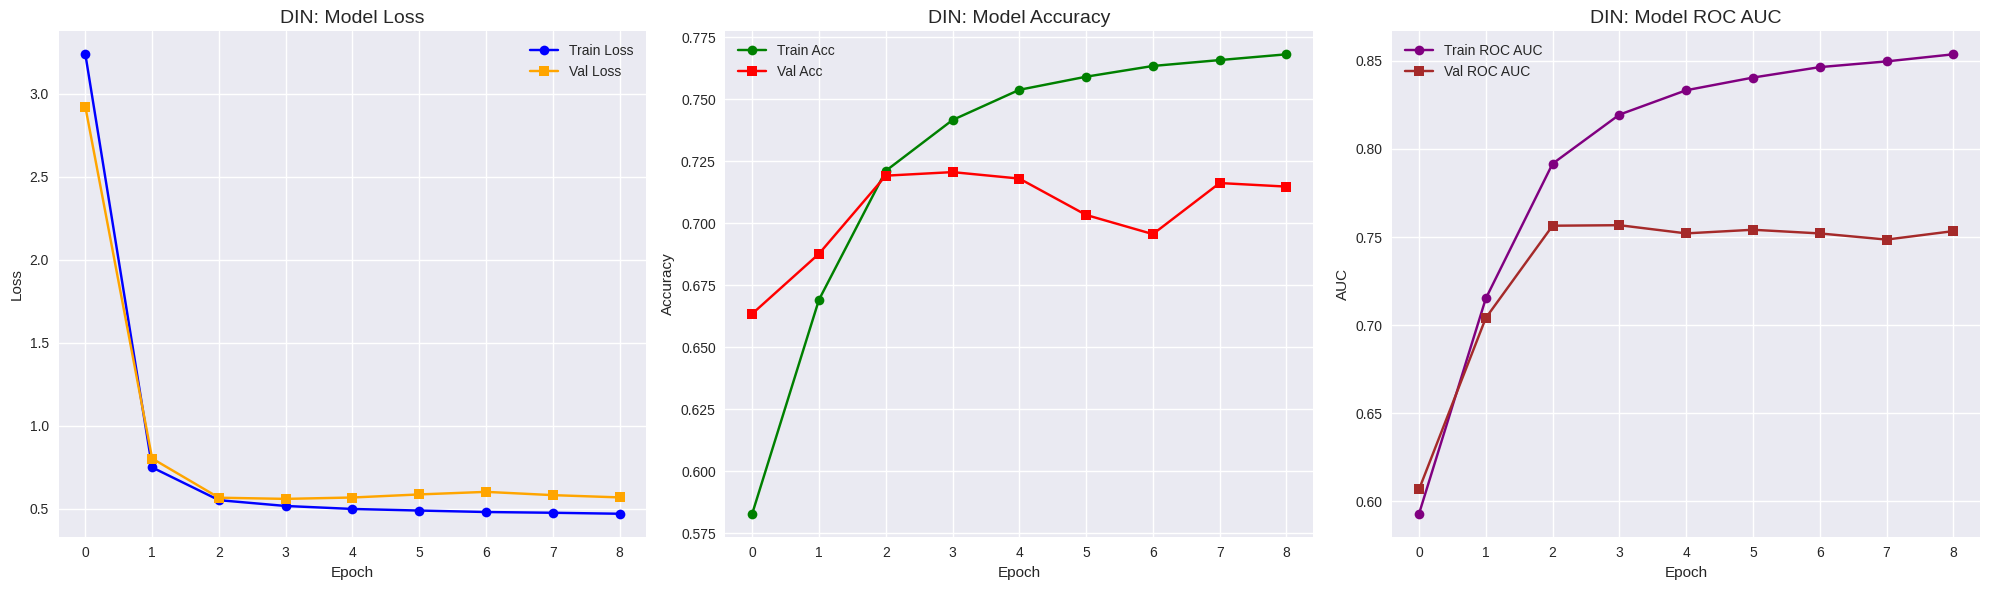

In [ ]:
import matplotlib.pyplot as plt

plt.style.use('seaborn-v0_8')
fig, axes = plt.subplots(1, 3, figsize=(20, 6))

# Loss
axes[0].plot(history.history['loss'], label='Train Loss', marker='o', color='b')
if 'val_loss' in history.history:
    axes[0].plot(history.history['val_loss'], label='Val Loss', marker='s', color='orange')
axes[0].set_title('DIN: Model Loss', fontsize=14)
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].legend()

# Accuracy
axes[1].plot(history.history['accuracy'], label='Train Acc', marker='o', color='g')
if 'val_accuracy' in history.history:
    axes[1].plot(history.history['val_accuracy'], label='Val Acc', marker='s', color='red')
axes[1].set_title('DIN: Model Accuracy', fontsize=14)
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy')
axes[1].legend()

# ROC AUC
axes[2].plot(history.history['roc_auc'], label='Train ROC AUC', marker='o', color='purple')
if 'val_roc_auc' in history.history:
    axes[2].plot(history.history['val_roc_auc'], label='Val ROC AUC', marker='s', color='brown')
axes[2].set_title('DIN: Model ROC AUC', fontsize=14)
axes[2].set_xlabel('Epoch')
axes[2].set_ylabel('AUC')
axes[2].legend()

plt.tight_layout()
plt.show()

### 2. 导出 DIN 模型

In [ ]:
import os
import shutil

din_export_path = "/content/models/din/1"
if os.path.exists(din_export_path):
    shutil.rmtree(din_export_path)

model.export(din_export_path)
print(f"DIN 模型已成功导出至: {din_export_path}")

/usr/local/lib/python3.12/dist-packages/keras/src/layers/layer.py:982: UserWarning: Layer 'attention_flatten' (of type Flatten) was passed an input with a mask attached to it. However, this layer does not support masking and will therefore destroy the mask information. Downstream layers will not see the mask.
  warnings.warn(


Saved artifact at '/content/models/din/1'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): Dict[['releaseYear', TensorSpec(shape=(None, 1), dtype=tf.float32, name='releaseYear')], ['movieRatingCount', TensorSpec(shape=(None, 1), dtype=tf.float32, name='movieRatingCount')], ['movieAvgRating', TensorSpec(shape=(None, 1), dtype=tf.float32, name='movieAvgRating')], ['movieRatingStddev', TensorSpec(shape=(None, 1), dtype=tf.float32, name='movieRatingStddev')], ['userRatingCount', TensorSpec(shape=(None, 1), dtype=tf.float32, name='userRatingCount')], ['userAvgRating', TensorSpec(shape=(None, 1), dtype=tf.float32, name='userAvgRating')], ['userRatingStddev', TensorSpec(shape=(None, 1), dtype=tf.float32, name='userRatingStddev')], ['movieId', TensorSpec(shape=(None, 1), dtype=tf.int32, name='movieId')], ['userId', TensorSpec(shape=(None, 1), dtype=tf.int32, name='userId')], ['userRatedMovie1', TensorSpec(shape=(None, 1), dtype=tf.int32, name='userRatedMo

### 3. 重启 TF Serving 加载 DIN 模型

In [ ]:
import time

print("正在重启 TensorFlow Serving 以加载 DIN 模型...")
!pkill -f tensorflow_model_server

os.environ['DIN_BASE_PATH'] = "/content/models/din"

!nohup tensorflow_model_server \
    --rest_api_port=8501 \
    --model_name=sparrow_din \
    --model_base_path=$DIN_BASE_PATH > server_din.log 2>&1 &

time.sleep(5)
!tail -n 5 server_din.log

正在重启 TensorFlow Serving 以加载 DIN 模型...
I0000 00:00:1782456469.385970   34159 server_core.cc:645]  (Re-)adding model: sparrow_din
I0000 00:00:1782456469.677128   34163 mlir_graph_optimization_pass.cc:437] MLIR V1 optimization pass is not enabled
I0000 00:00:1782456469.951312   34159 server_core.cc:537] Finished adding/updating models
[warn] getaddrinfo: address family for nodename not supported
[evhttp_server.cc : 261] NET_LOG: Entering the event loop ...


### 4. DIN 预测测试与 Curl 命令生成

In [ ]:
import requests
import json
import pandas as pd
from IPython.display import display, HTML

# 1. 准备测试数据 (DIN 特有的序列特征)
sample_df = pd.read_csv(test_path).iloc[0:1]

print("--- 准备测试的样本数据 ---")
display(sample_df)
print("-" * 30)

instance = {}
for col in NUMERIC_FEATURES:
    instance[col] = [float(sample_df[col].fillna(0).iloc[0])]
for col in ID_FEATURES:
    instance[col] = [int(sample_df[col].iloc[0])]
for col in BEHAVIOR_FEATURES:
    instance[col] = [int(sample_df[col].fillna(0).iloc[0])]
for col in GENRE_FEATURES:
    instance[col] = [str(sample_df[col].fillna('None').iloc[0])]

# 2. Python 验证
predict_url = f"{public_url}/v1/models/sparrow_din:predict"
payload = {"instances": [instance]}
response = requests.post(predict_url, json=payload)

if response.status_code == 200:
    print(f"DIN Python 预测成功！CTR: {response.json()['predictions'][0][0]:.4%}")
else:
    print(f"预测失败: {response.text}")

# 3. 生成 Windows Curl 命令
json_payload = json.dumps(payload, separators=(',', ':'))
escaped_json = json_payload.replace('"', '\\\"')
cmd_command = f'curl -X POST "{public_url}/v1/models/sparrow_din:predict" -H "Content-Type: application/json" -d "{escaped_json}"'

print("\n请复制以下命令到 Windows CMD 执行:\n")
print(cmd_command)

# 4. 复制按钮
js_safe_command = cmd_command.replace('\\', '\\\\')
html_code = f"""
<button onclick=\"copyToClipboard()\" style=\"cursor:pointer; background-color: #4CAF50; color: white; padding: 10px 20px; border: none; border-radius: 5px; font-size: 16px;\">
    📋 点击复制 DIN 模型 Windows CMD 命令
</button>

<script>
function copyToClipboard() {{
    const textToCopy = `{js_safe_command}`;
    const tempInput = document.createElement('textarea');
    tempInput.value = textToCopy;
    document.body.appendChild(tempInput);
    tempInput.select();
    document.execCommand('copy');
    document.body.removeChild(tempInput);
    alert('DIN 命令已成功复制！');
}}
</script>
"""
display(HTML(html_code))

--- 准备测试的样本数据 ---


,movieId,userId,rating,timestamp,label,releaseYear,movieGenre1,movieGenre2,movieGenre3,movieRatingCount,...,userRatingCount,userAvgReleaseYear,userReleaseYearStddev,userAvgRating,userRatingStddev,userGenre1,userGenre2,userGenre3,userGenre4,userGenre5
0,223,9077,2.5,1247908275,0,1994,Comedy,NaN,NaN,5102,...,10,1982,15.33,3.85,0.53,Thriller,Action,Sci-Fi,Drama,Horror


------------------------------
DIN Python 预测成功！CTR: 77.0107%

请复制以下命令到 Windows CMD 执行:

curl -X POST "https://footbath-naming-impaired.ngrok-free.dev/v1/models/sparrow_din:predict" -H "Content-Type: application/json" -d "{\"instances\":[{\"releaseYear\":[1994.0],\"movieRatingCount\":[5102.0],\"movieAvgRating\":[3.86],\"movieRatingStddev\":[0.97],\"userRatingCount\":[10.0],\"userAvgRating\":[3.85],\"userRatingStddev\":[0.53],\"movieId\":[223],\"userId\":[9077],\"userRatedMovie1\":[32],\"userRatedMovie2\":[735],\"userRatedMovie3\":[968],\"userRatedMovie4\":[750],\"userRatedMovie5\":[908],\"userGenre1\":[\"Thriller\"],\"movieGenre1\":[\"Comedy\"]}]}"


## DIEN

### 模型代码

In [ ]:
"""
DIEN (Deep Interest Evolution Network) for TensorFlow 2.20.

这个版本从原始 DIEN.py 迁移而来，主要适配点：
1. 移除 tf.feature_column 和 DenseFeatures，改用 Keras 原生层。
2. 使用 TensorFlow 2.20 / Keras 3 兼容的 Functional API 写法，避免直接对 KerasTensor 调用裸 TensorFlow 算子。
3. 保留 DIEN 的核心结构：行为序列 Embedding、GRU 兴趣抽取、候选物品 Attention、AUGRU 兴趣演化、辅助负采样损失。
4. 数据路径改为 Google Colab 中 SparrowRecSys 项目的 ByTimeStamp 数据集。
5. 增加验证集，并使用 EarlyStopping 监控 val_roc_auc。

注意：本文件用于 Colab 运行。本地迁移时只做静态 review，不在本地执行训练。
"""

import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow.keras import layers


# ============================================================
# 数据路径：Google Colab 中 SparrowRecSys 项目的样本文件
# ============================================================
train_path = "/content/SparrowRecSys/src/main/resources/webroot/sampledata/trainingSamplesByTimeStamp.csv"
validation_path = "/content/SparrowRecSys/src/main/resources/webroot/sampledata/validationSamplesByTimeStamp.csv"
test_path = "/content/SparrowRecSys/src/main/resources/webroot/sampledata/testSamplesByTimeStamp.csv"


# ============================================================
# 超参数：尽量保持与原始 DIEN.py 的结构和规模一致
# ============================================================
BATCH_SIZE = 12
EPOCHS = 50
EMBEDDING_SIZE = 10
RECENT_MOVIES = 5
MOVIE_BUCKETS = 1001
USER_BUCKETS = 30001
AUXILIARY_LOSS_WEIGHT = 0.5


# ============================================================
# 特征定义
# ============================================================
NUMERIC_FEATURES = [
    "movieAvgRating",
    "movieRatingStddev",
    "movieRatingCount",
    "userAvgRating",
    "userRatingStddev",
    "userRatingCount",
    "releaseYear",
]

ID_FEATURES = ["movieId", "userId"]

BEHAVIOR_FEATURES = [
    "userRatedMovie1",
    "userRatedMovie2",
    "userRatedMovie3",
    "userRatedMovie4",
    "userRatedMovie5",
]

# DIEN 辅助损失需要使用 userRatedMovie2-5 的负样本，表示“下一步没有点击/评分的电影”。
NEGATIVE_BEHAVIOR_FEATURES = [
    "negative_userRatedMovie2",
    "negative_userRatedMovie3",
    "negative_userRatedMovie4",
    "negative_userRatedMovie5",
]

# 原始 DIEN.py 的 inputs 定义了 userGenre1-5 和 movieGenre1-3，
# 但真正进入 DenseFeatures 的只有 userGenre1 和 movieGenre1。
GENRE_FEATURES = ["userGenre1", "movieGenre1"]

SELECTED_COLUMNS = (
    NUMERIC_FEATURES
    + ID_FEATURES
    + BEHAVIOR_FEATURES
    + GENRE_FEATURES
    + ["label"]
)

GENRE_VOCAB = [
    "Film-Noir",
    "Action",
    "Adventure",
    "Horror",
    "Romance",
    "War",
    "Comedy",
    "Western",
    "Documentary",
    "Sci-Fi",
    "Drama",
    "Thriller",
    "Crime",
    "Fantasy",
    "Animation",
    "IMAX",
    "Mystery",
    "Children",
    "Musical",
]


# ============================================================
# 数据集加载与负样本生成
# ============================================================
def _sample_negative_movie_ids(positive_movie_ids, rng):
    """
    为一列正样本电影 ID 生成负样本电影 ID。

    负样本范围保持与原始代码一致：0 到 1000。
    如果随机出的负样本刚好等于正样本，就重新采样，确保二者不同。
    """
    positives = positive_movie_ids.astype(np.int32)
    negatives = rng.integers(0, MOVIE_BUCKETS, size=len(positives), dtype=np.int32)

    same_mask = negatives == positives
    while np.any(same_mask):
        negatives[same_mask] = rng.integers(
            0,
            MOVIE_BUCKETS,
            size=int(np.sum(same_mask)),
            dtype=np.int32,
        )
        same_mask = negatives == positives

    return negatives


def _load_dataframe_with_negative_movies(file_path, seed_num):
    """
    读取 CSV，并为 DIEN 的辅助损失构造负样本列。

    原始 DIEN.py 使用 pandas 读取全量 CSV 后生成负样本。
    这里保留这种方式，便于在 Colab 上直接运行，也方便确保每个 epoch 的负样本可复现。
    """
    df = pd.read_csv(file_path, usecols=SELECTED_COLUMNS)
    df = df.fillna(0)

    for name in NUMERIC_FEATURES:
        df[name] = pd.to_numeric(df[name], errors="coerce").fillna(0).astype(np.float32)

    for name in ID_FEATURES + BEHAVIOR_FEATURES:
        df[name] = pd.to_numeric(df[name], errors="coerce").fillna(0).astype(np.int32)

    for name in GENRE_FEATURES:
        df[name] = df[name].astype(str)

    df["label"] = pd.to_numeric(df["label"], errors="coerce").fillna(0).astype(np.float32)

    rng = np.random.default_rng(seed_num)
    for positive_name, negative_name in zip(BEHAVIOR_FEATURES[1:], NEGATIVE_BEHAVIOR_FEATURES):
        df[negative_name] = _sample_negative_movie_ids(df[positive_name].to_numpy(), rng)

    return df


def get_dataset_with_negative_movies(file_path, batch_size, seed_num, shuffle=True):
    """
    构建 tf.data.Dataset。

    输出格式是 (features, label)，可以直接用于 model.fit / evaluate。
    每个标量特征都整理为 (batch, 1)，与 build_inputs() 中的 Input(shape=(1,)) 对齐。
    """
    df = _load_dataframe_with_negative_movies(file_path, seed_num)

    features = {}
    for name in NUMERIC_FEATURES:
        features[name] = df[name].to_numpy(dtype=np.float32).reshape(-1, 1)

    for name in ID_FEATURES + BEHAVIOR_FEATURES + NEGATIVE_BEHAVIOR_FEATURES:
        features[name] = df[name].to_numpy(dtype=np.int32).reshape(-1, 1)

    for name in GENRE_FEATURES:
        features[name] = df[name].to_numpy(dtype=str).reshape(-1, 1)

    labels = df["label"].to_numpy(dtype=np.float32).reshape(-1, 1)

    dataset = tf.data.Dataset.from_tensor_slices((features, labels))
    if shuffle:
        dataset = dataset.shuffle(
            buffer_size=min(len(df), 10000),
            seed=seed_num,
            reshuffle_each_iteration=True,
        )

    return dataset.batch(batch_size).prefetch(tf.data.AUTOTUNE)


# ============================================================
# Keras 输入层与特征编码
# ============================================================
def build_inputs():
    """为每个模型特征创建命名 Input，名称必须与 Dataset 字典中的 key 一致。"""
    inputs = {}

    for name in NUMERIC_FEATURES:
        inputs[name] = layers.Input(name=name, shape=(1,), dtype=tf.float32)

    for name in ID_FEATURES + BEHAVIOR_FEATURES + NEGATIVE_BEHAVIOR_FEATURES:
        inputs[name] = layers.Input(name=name, shape=(1,), dtype=tf.int32)

    for name in GENRE_FEATURES:
        inputs[name] = layers.Input(name=name, shape=(1,), dtype=tf.string)

    return inputs


def build_id_embedding(inputs, feature_name, num_buckets, output_dim, layer_prefix):
    """
    将整数 ID 转换为稠密 Embedding。

    对应原始代码中的 categorical_column_with_identity + embedding_column。
    """
    embedding = layers.Embedding(
        input_dim=num_buckets,
        output_dim=output_dim,
        name=f"{layer_prefix}_{feature_name}_embedding",
    )(inputs[feature_name])
    return layers.Flatten(name=f"{layer_prefix}_{feature_name}_flatten")(embedding)


def build_genre_lookup_and_embedding(inputs, feature_name, output_dim, layer_prefix):
    """
    将 genre 字符串转换为词表索引，再转换为 Embedding。

    对应原始代码中的 categorical_column_with_vocabulary_list + embedding_column。
    """
    genre_index = layers.StringLookup(
        vocabulary=GENRE_VOCAB,
        mask_token=None,
        num_oov_indices=1,
        name=f"{layer_prefix}_{feature_name}_lookup",
    )(inputs[feature_name])
    embedding = layers.Embedding(
        input_dim=len(GENRE_VOCAB) + 1,
        output_dim=output_dim,
        name=f"{layer_prefix}_{feature_name}_embedding",
    )(genre_index)
    return layers.Flatten(name=f"{layer_prefix}_{feature_name}_flatten")(embedding)


# ============================================================
# DIEN 自定义层
# ============================================================
class AttentionScore(layers.Layer):
    """
    DIEN 的 Activation Unit。

    输入：
      - candidate_embedding: 候选电影 Embedding，形状 (batch, emb)
      - gru_hidden_states: GRU 输出的行为隐藏状态，形状 (batch, time, emb)

    输出：
      - attention_score: 每个时间步对应的兴趣相关性权重，形状 (batch, time, emb)
    """

    def __init__(self, embedding_size=EMBEDDING_SIZE, time_length=RECENT_MOVIES, **kwargs):
        super().__init__(**kwargs)
        self.embedding_size = embedding_size
        self.time_length = time_length
        self.repeat_time = layers.RepeatVector(time_length)
        self.repeat_embedding = layers.RepeatVector(embedding_size)
        self.multiply = layers.Multiply()
        self.dense_32 = layers.Dense(32, activation="sigmoid")
        self.dense_1 = layers.Dense(1, activation="sigmoid")
        self.permute = layers.Permute((2, 1))

    def call(self, inputs):
        candidate_embedding, gru_hidden_states = inputs

        repeated_candidate = self.repeat_time(candidate_embedding)
        activation_product = self.multiply([gru_hidden_states, repeated_candidate])
        attention = self.dense_32(activation_product)
        attention = self.dense_1(attention)
        attention = tf.squeeze(attention, axis=2)
        attention = self.repeat_embedding(attention)
        attention = self.permute(attention)

        return attention


class GRUGateParameter(layers.Layer):
    """
    AUGRU 中的门控参数层。

    use_reset_gate=False 时，计算 sigmoid 门控值。
    use_reset_gate=True 时，计算候选隐藏状态 h_tilde，隐藏状态会先乘以 reset gate。
    """

    def __init__(self, embedding_size=EMBEDDING_SIZE, activation="sigmoid", **kwargs):
        super().__init__(**kwargs)
        self.embedding_size = embedding_size
        self.activation = activation
        self.input_dense = layers.Dense(embedding_size, activation=None, use_bias=True)
        self.hidden_dense = layers.Dense(embedding_size, activation=None, use_bias=False)
        self.multiply = layers.Multiply()

    def call(self, inputs, reset_gate=None):
        gru_input, previous_hidden_state = inputs
        hidden_state = previous_hidden_state

        if reset_gate is not None:
            hidden_state = self.multiply([hidden_state, reset_gate])

        gate_value = self.input_dense(gru_input) + self.hidden_dense(hidden_state)

        if self.activation == "tanh":
            return tf.tanh(gate_value)
        return tf.sigmoid(gate_value)


class AUGRU(layers.Layer):
    """
    Attention based GRU。

    DIEN 使用注意力分数调节 GRU 的 update gate：
        update_gate = attention_score * z_t
        h_t = (1 - update_gate) * h_{t-1} + update_gate * h_tilde
    """

    def __init__(self, embedding_size=EMBEDDING_SIZE, time_length=RECENT_MOVIES, **kwargs):
        super().__init__(**kwargs)
        self.embedding_size = embedding_size
        self.time_length = time_length
        self.reset_gate = GRUGateParameter(embedding_size, activation="sigmoid")
        self.update_gate = GRUGateParameter(embedding_size, activation="sigmoid")
        self.candidate_state = GRUGateParameter(embedding_size, activation="tanh")
        self.multiply = layers.Multiply()
        self.add = layers.Add()

    def call(self, inputs):
        gru_hidden_states, attention_scores = inputs
        batch_size = tf.shape(gru_hidden_states)[0]
        augru_hidden_state = tf.zeros((batch_size, self.embedding_size), dtype=gru_hidden_states.dtype)

        for time_index in range(self.time_length):
            current_hidden_state = gru_hidden_states[:, time_index, :]
            current_attention = attention_scores[:, time_index, :]

            r_t = self.reset_gate([current_hidden_state, augru_hidden_state])
            z_t = self.update_gate([current_hidden_state, augru_hidden_state])
            h_tilde = self.candidate_state(
                [current_hidden_state, augru_hidden_state],
                reset_gate=r_t,
            )

            attentional_update_gate = self.multiply([current_attention, z_t])
            keep_previous = self.multiply([(1.0 - attentional_update_gate), augru_hidden_state])
            use_current = self.multiply([attentional_update_gate, h_tilde])
            augru_hidden_state = self.add([keep_previous, use_current])

        return augru_hidden_state


class AuxiliaryLossLayer(layers.Layer):
    """
    DIEN 的辅助损失层。

    GRU 在每个时间步的隐藏状态应该能预测“下一部真实行为电影”，同时区分随机负样本电影。
    当下一部电影 ID 为 0 时，表示缺失/填充位置，不参与辅助损失计算。
    这个损失通过 add_loss 加入 model 的总训练损失，不改变模型最终输出。
    """

    def __init__(self, alpha=AUXILIARY_LOSS_WEIGHT, **kwargs):
        super().__init__(**kwargs)
        self.alpha = alpha
        self.positive_dense_32 = layers.Dense(32, activation="sigmoid")
        self.positive_dense_1 = layers.Dense(1, activation="sigmoid")
        self.negative_dense_32 = layers.Dense(32, activation="sigmoid")
        self.negative_dense_1 = layers.Dense(1, activation="sigmoid")

    def call(self, inputs):
        (
            negative_movie_embedding,
            behavior_embedding,
            behavior_ids,
            gru_hidden_states,
            pass_through,
        ) = inputs

        # 使用前 4 个隐藏状态预测后 4 个真实行为：h_1->movie_2, ..., h_4->movie_5。
        hidden_states = gru_hidden_states[:, :-1, :]
        positive_next_movies = behavior_embedding[:, 1:, :]
        positive_next_movie_ids = behavior_ids[:, 1:]

        positive_features = tf.concat([hidden_states, positive_next_movies], axis=-1)
        positive_scores = self.positive_dense_32(positive_features)
        positive_scores = self.positive_dense_1(positive_scores)

        negative_features = tf.concat([hidden_states, negative_movie_embedding], axis=-1)
        negative_scores = self.negative_dense_32(negative_features)
        negative_scores = self.negative_dense_1(negative_scores)

        positive_loss = tf.keras.losses.binary_crossentropy(
            tf.ones_like(positive_scores),
            positive_scores,
        )
        negative_loss = tf.keras.losses.binary_crossentropy(
            tf.zeros_like(negative_scores),
            negative_scores,
        )

        # 只在真实存在下一步行为的位置计算辅助损失，跳过 ID=0 的 padding。
        valid_mask = tf.cast(tf.not_equal(positive_next_movie_ids, 0), positive_loss.dtype)
        weighted_loss = (positive_loss + negative_loss) * valid_mask
        auxiliary_loss = tf.reduce_sum(weighted_loss) / (tf.reduce_sum(valid_mask) + 1e-7)
        self.add_loss(self.alpha * auxiliary_loss)

        return pass_through


# ============================================================
# DIEN 模型定义
# ============================================================
def build_dien_model():
    """构建 TensorFlow 2.20 / Keras 3 兼容的 DIEN 模型。"""
    inputs = build_inputs()

    # ----------------------------------------------------------
    # 共享电影 Embedding：候选电影、用户历史行为、负样本电影共用同一个 Embedding 空间。
    # ----------------------------------------------------------
    shared_movie_embedding = layers.Embedding(
        input_dim=MOVIE_BUCKETS,
        output_dim=EMBEDDING_SIZE,
        mask_zero=True,
        name="shared_movie_embedding",
    )

    candidate_embedding = shared_movie_embedding(inputs["movieId"])
    candidate_embedding = layers.Flatten(name="candidate_movie_flatten")(candidate_embedding)

    behavior_ids = layers.Concatenate(axis=1, name="behavior_ids_concat")(
        [inputs[name] for name in BEHAVIOR_FEATURES]
    )
    behavior_embedding = shared_movie_embedding(behavior_ids)

    negative_behavior_ids = layers.Concatenate(axis=1, name="negative_behavior_ids_concat")(
        [inputs[name] for name in NEGATIVE_BEHAVIOR_FEATURES]
    )
    negative_behavior_embedding = shared_movie_embedding(negative_behavior_ids)

    # ----------------------------------------------------------
    # 兴趣抽取层：用 GRU 从历史行为序列中抽取用户兴趣状态。
    # ----------------------------------------------------------
    behavior_hidden_states = layers.GRU(
        EMBEDDING_SIZE,
        return_sequences=True,
        # mask_zero=True 会把 movieId=0 传成 RNN mask。
        # 行为序列中的 0 不一定都是严格右侧 padding，cuDNN GRU 不支持这种 mask，
        # 因此显式关闭 cuDNN 路径，避免在 Colab GPU 上触发断言失败。
        use_cudnn=False,
        name="interest_extractor_gru",
    )(behavior_embedding)

    # ----------------------------------------------------------
    # 兴趣演化层：候选电影参与 attention，AUGRU 输出与候选电影相关的演化兴趣。
    # ----------------------------------------------------------
    attention_scores = AttentionScore(name="attention_score")(
        [candidate_embedding, behavior_hidden_states]
    )
    augru_embedding = AUGRU(name="augru_interest_evolution")(
        [behavior_hidden_states, attention_scores]
    )

    # 将辅助损失挂到 augru_embedding 的计算路径上，确保 model.fit 时会纳入总 loss。
    augru_embedding = AuxiliaryLossLayer(name="auxiliary_loss")(
        [
            negative_behavior_embedding,
            behavior_embedding,
            behavior_ids,
            behavior_hidden_states,
            augru_embedding,
        ]
    )

    # ----------------------------------------------------------
    # 用户画像特征：userId Embedding + userGenre1 Embedding + 用户统计特征。
    # ----------------------------------------------------------
    user_embedding = build_id_embedding(inputs, "userId", USER_BUCKETS, EMBEDDING_SIZE, "user")
    user_genre_embedding = build_genre_lookup_and_embedding(
        inputs,
        "userGenre1",
        EMBEDDING_SIZE,
        "user",
    )
    user_numeric = layers.Concatenate(name="user_numeric_concat")(
        [
            inputs["userRatingCount"],
            inputs["userAvgRating"],
            inputs["userRatingStddev"],
        ]
    )
    user_profile_layer = layers.Concatenate(name="user_profile_concat")(
        [user_embedding, user_genre_embedding, user_numeric]
    )

    # ----------------------------------------------------------
    # 上下文特征：movieGenre1 Embedding + 电影统计特征。
    # ----------------------------------------------------------
    movie_genre_embedding = build_genre_lookup_and_embedding(
        inputs,
        "movieGenre1",
        EMBEDDING_SIZE,
        "context",
    )
    context_numeric = layers.Concatenate(name="context_numeric_concat")(
        [
            inputs["releaseYear"],
            inputs["movieRatingCount"],
            inputs["movieAvgRating"],
            inputs["movieRatingStddev"],
        ]
    )
    context_features_layer = layers.Concatenate(name="context_features_concat")(
        [movie_genre_embedding, context_numeric]
    )

    # ----------------------------------------------------------
    # 全连接预测层：演化兴趣 + 候选电影 + 用户画像 + 上下文特征。
    # ----------------------------------------------------------
    concat_layer = layers.Concatenate(name="dien_concat")(
        [
            augru_embedding,
            candidate_embedding,
            user_profile_layer,
            context_features_layer,
        ]
    )

    output_layer = layers.Dense(128, name="fc_dense_1")(concat_layer)
    output_layer = layers.PReLU(name="fc_prelu_1")(output_layer)
    output_layer = layers.Dense(64, name="fc_dense_2")(output_layer)
    output_layer = layers.PReLU(name="fc_prelu_2")(output_layer)
    output_layer = layers.Dense(1, activation="sigmoid", name="prediction")(output_layer)

    return tf.keras.Model(inputs=inputs, outputs=output_layer, name="DIEN_tf220")


# ============================================================
# 训练、验证、测试流程
# ============================================================
def main():
    train_dataset = get_dataset_with_negative_movies(
        train_path,
        BATCH_SIZE,
        seed_num=2020,
        shuffle=True,
    )
    validation_dataset = get_dataset_with_negative_movies(
        validation_path,
        BATCH_SIZE,
        seed_num=2021,
        shuffle=False,
    )
    test_dataset = get_dataset_with_negative_movies(
        test_path,
        BATCH_SIZE,
        seed_num=2022,
        shuffle=False,
    )

    model = build_dien_model()
    model.summary()

    # AUC 指标显式命名为 roc_auc，因此验证集指标名就是 val_roc_auc。
    model.compile(
        loss="binary_crossentropy",
        optimizer="adam",
        metrics=[
            "accuracy",
            tf.keras.metrics.AUC(curve="ROC", name="roc_auc"),
            tf.keras.metrics.AUC(curve="PR", name="pr_auc"),
        ],
    )

    early_stopping = tf.keras.callbacks.EarlyStopping(
        monitor="val_roc_auc",     # 监控验证集的 AUC
        patience=5,                # 如果连续 5 个 epoch 指标没提升就停止
        mode="max",                # 目标是最大化 AUC
        restore_best_weights=True, # 停止后恢复最优权重
    )

    history = model.fit(
        train_dataset,
        validation_data=validation_dataset,
        epochs=EPOCHS,
        callbacks=[early_stopping],
    )

    test_loss, test_accuracy, test_roc_auc, test_pr_auc = model.evaluate(test_dataset)
    print(
        "\n\nTest Loss {}, Test Accuracy {}, Test ROC AUC {}, Test PR AUC {}".format(
            test_loss,
            test_accuracy,
            test_roc_auc,
            test_pr_auc,
        )
    )

    # 打印一个 batch 的预测结果，避免把整个 test_dataset 转成 list 占用过多内存。
    for batch_features, batch_labels in test_dataset.take(1):
        predictions = model.predict(batch_features)
        for prediction, label in zip(predictions[:12], batch_labels[:12]):
            label_value = bool(label.numpy().item())
            print(
                "Predicted good rating: {:.2%}".format(prediction[0]),
                " | Actual rating label: ",
                "Good Rating" if label_value else "Bad Rating",
            )

    return history, model


history, model = main()


/usr/local/lib/python3.12/dist-packages/keras/src/layers/layer.py:982: UserWarning: Layer 'candidate_movie_flatten' (of type Flatten) was passed an input with a mask attached to it. However, this layer does not support masking and will therefore destroy the mask information. Downstream layers will not see the mask.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/keras/src/layers/layer.py:982: UserWarning: Layer 'attention_score' (of type AttentionScore) was passed an input with a mask attached to it. However, this layer does not support masking and will therefore destroy the mask information. Downstream layers will not see the mask.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/keras/src/layers/layer.py:424: UserWarning: `build()` was called on layer 'gru_gate_parameter_9', however the layer does not have a `build()` method implemented and it looks like it has unbuilt state. This will cause the layer to be marked as built, despite not being actually built, which may

Model: "DIEN_tf220"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ negative_userRated… │ (None, 1)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ negative_userRated… │ (None, 1)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ negative_userRated… │ (None, 1)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ negative_userRated… │ (None, 1)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ userRatedMovie1     │ (None, 1)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ userRatedMovie2     │ (None, 1)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ userRatedMovie3     │ (None, 1)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ userRatedMovie4     │ (None, 1)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ userRatedMovie5     │ (None, 1)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ negative_behavior_… │ (None, 4)         │          0 │ negative_userRat… │
│ (Concatenate)       │                   │            │ negative_userRat… │
│                     │                   │            │ negative_userRat… │
│                     │                   │            │ negative_userRat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ behavior_ids_concat │ (None, 5)         │          0 │ userRatedMovie1[… │
│ (Concatenate)       │                   │            │ userRatedMovie2[… │
│                     │                   │            │ userRatedMovie3[… │
│                     │                   │            │ userRatedMovie4[… │
│                     │                   │            │ userRatedMovie5[… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ movieId             │ (None, 1)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ shared_movie_embed… │ (None, 4, 10)     │     10,010 │ movieId[0][0],    │
│ (Embedding)         │                   │            │ behavior_ids_con… │
│                     │                   │            │ negative_behavio… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ not_equal_10        │ (None, 5)         │          0 │ behavior_ids_con… │
│ (NotEqual)          │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ userGenre1          │ (None, 1)         │          0 │ -               

 Total params: 329,442 (1.26 MB)

 Trainable params: 329,442 (1.26 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/50
7410/7410 ━━━━━━━━━━━━━━━━━━━━ 324s 42ms/step - accuracy: 0.5787 - loss: 4.3232 - pr_auc: 0.6065 - roc_auc: 0.5917 - val_accuracy: 0.6867 - val_loss: 1.0816 - val_pr_auc: 0.7963 - val_roc_auc: 0.7252
Epoch 2/50
7410/7410 ━━━━━━━━━━━━━━━━━━━━ 304s 41ms/step - accuracy: 0.6634 - loss: 0.9025 - pr_auc: 0.7015 - roc_auc: 0.7014 - val_accuracy: 0.6808 - val_loss: 0.9756 - val_pr_auc: 0.7749 - val_roc_auc: 0.6910
Epoch 3/50
7410/7410 ━━━━━━━━━━━━━━━━━━━━ 304s 41ms/step - accuracy: 0.7174 - loss: 0.5634 - pr_auc: 0.7891 - roc_auc: 0.7860 - val_accuracy: 0.6977 - val_loss: 0.5865 - val_pr_auc: 0.8196 - val_roc_auc: 0.7514
Epoch 4/50
7410/7410 ━━━━━━━━━━━━━━━━━━━━ 309s 42ms/step - accuracy: 0.7430 - loss: 0.5187 - pr_auc: 0.8300 - roc_auc: 0.8191 - val_accuracy: 0.4924 - val_loss: 1.0298 - val_pr_auc: 0.7284 - val_roc_auc: 0.5877
Epoch 5/50
7410/7410 ━━━━━━━━━━━━━━━━━━━━ 307s 41ms/step - accuracy: 0.7559 - loss: 0.4989 - pr_auc: 0.8468 - roc_auc: 0.8349 - val_accuracy: 0.7031 - val_l

### 1. 绘制 DIEN 训练曲线

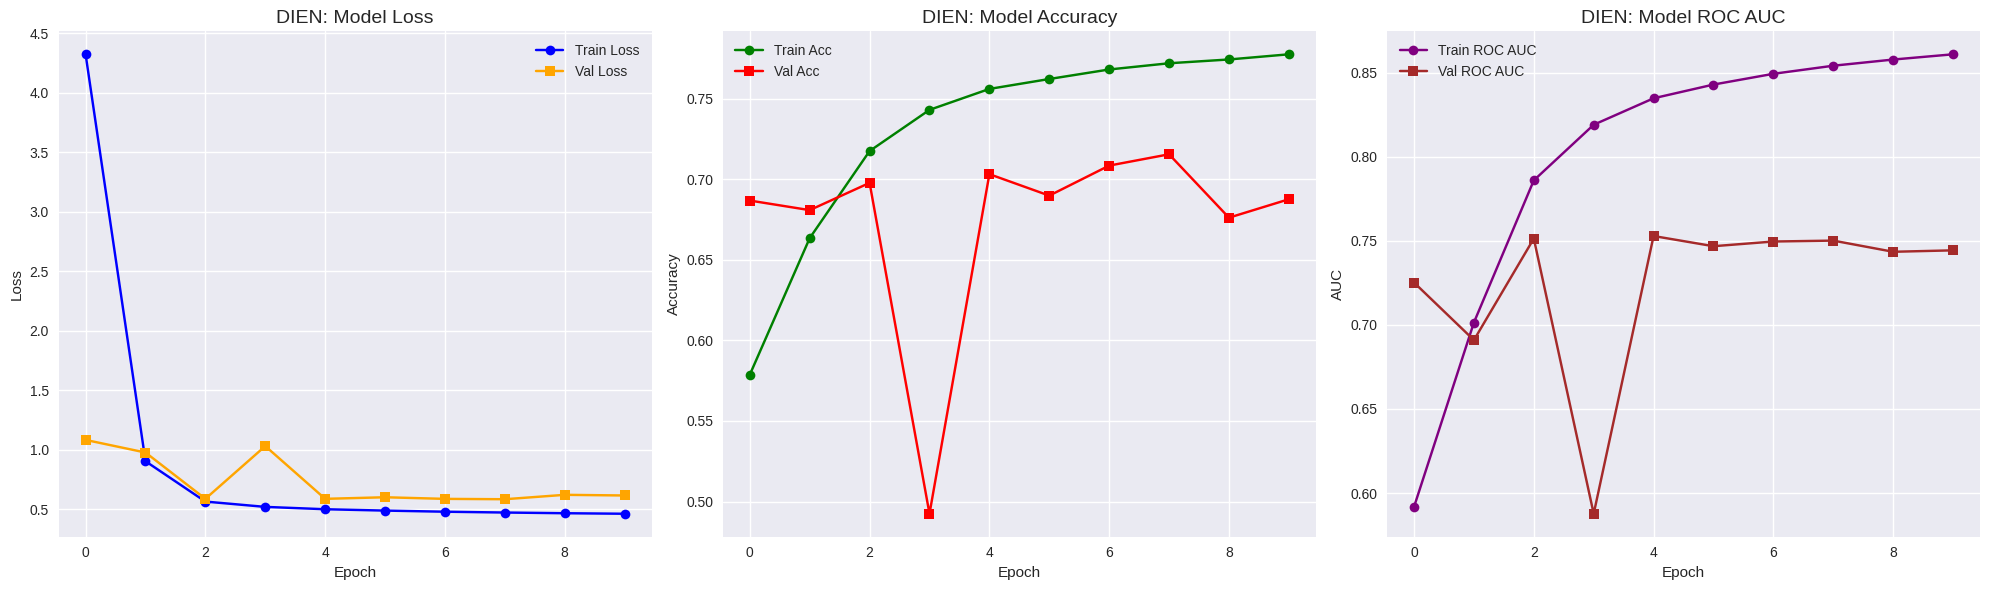

In [ ]:
import matplotlib.pyplot as plt

# 设置绘图风格
plt.style.use('seaborn-v0_8')
fig, axes = plt.subplots(1, 3, figsize=(20, 6))

# 1. 绘制 Loss 曲线
axes[0].plot(history.history['loss'], label='Train Loss', marker='o', color='b')
if 'val_loss' in history.history:
    axes[0].plot(history.history['val_loss'], label='Val Loss', marker='s', color='orange')
axes[0].set_title('DIEN: Model Loss', fontsize=14)
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].legend()

# 2. 绘制 Accuracy 曲线
axes[1].plot(history.history['accuracy'], label='Train Acc', marker='o', color='g')
if 'val_accuracy' in history.history:
    axes[1].plot(history.history['val_accuracy'], label='Val Acc', marker='s', color='red')
axes[1].set_title('DIEN: Model Accuracy', fontsize=14)
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy')
axes[1].legend()

# 3. 绘制 ROC AUC 曲线
axes[2].plot(history.history['roc_auc'], label='Train ROC AUC', marker='o', color='purple')
if 'val_roc_auc' in history.history:
    axes[2].plot(history.history['val_roc_auc'], label='Val ROC AUC', marker='s', color='brown')
axes[2].set_title('DIEN: Model ROC AUC', fontsize=14)
axes[2].set_xlabel('Epoch')
axes[2].set_ylabel('AUC')
axes[2].legend()

plt.tight_layout()
plt.show()

### 2. 导出 DIEN 模型

In [ ]:
import os
import shutil

dien_export_path = "/content/models/dien/1"
if os.path.exists(dien_export_path):
    shutil.rmtree(dien_export_path)

model.export(dien_export_path)
print(f"DIEN 模型已成功导出至: {dien_export_path}")

/usr/local/lib/python3.12/dist-packages/keras/src/layers/layer.py:982: UserWarning: Layer 'candidate_movie_flatten' (of type Flatten) was passed an input with a mask attached to it. However, this layer does not support masking and will therefore destroy the mask information. Downstream layers will not see the mask.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/keras/src/layers/layer.py:982: UserWarning: Layer 'attention_score' (of type AttentionScore) was passed an input with a mask attached to it. However, this layer does not support masking and will therefore destroy the mask information. Downstream layers will not see the mask.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/keras/src/layers/layer.py:982: UserWarning: Layer 'augru_interest_evolution' (of type AUGRU) was passed an input with a mask attached to it. However, this layer does not support masking and will therefore destroy the mask information. Downstream layers will not see the mask.
  warnings.warn(


Saved artifact at '/content/models/dien/1'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): Dict[['movieAvgRating', TensorSpec(shape=(None, 1), dtype=tf.float32, name='movieAvgRating')], ['movieRatingStddev', TensorSpec(shape=(None, 1), dtype=tf.float32, name='movieRatingStddev')], ['movieRatingCount', TensorSpec(shape=(None, 1), dtype=tf.float32, name='movieRatingCount')], ['userAvgRating', TensorSpec(shape=(None, 1), dtype=tf.float32, name='userAvgRating')], ['userRatingStddev', TensorSpec(shape=(None, 1), dtype=tf.float32, name='userRatingStddev')], ['userRatingCount', TensorSpec(shape=(None, 1), dtype=tf.float32, name='userRatingCount')], ['releaseYear', TensorSpec(shape=(None, 1), dtype=tf.float32, name='releaseYear')], ['movieId', TensorSpec(shape=(None, 1), dtype=tf.int32, name='movieId')], ['userId', TensorSpec(shape=(None, 1), dtype=tf.int32, name='userId')], ['userRatedMovie1', TensorSpec(shape=(None, 1), dtype=tf.int32, name='userRatedM

### 3. 重启 TF Serving 加载 DIEN 模型

In [ ]:
import time

print("正在重启 TensorFlow Serving 以加载 DIEN 模型...")
!pkill -f tensorflow_model_server

os.environ['DIEN_SERVING_BASE_PATH'] = "/content/models/dien"

!nohup tensorflow_model_server \
    --rest_api_port=8501 \
    --model_name=sparrow_dien \
    --model_base_path=$DIEN_SERVING_BASE_PATH > server_dien.log 2>&1 &

time.sleep(5)
!tail -n 5 server_dien.log

正在重启 TensorFlow Serving 以加载 DIEN 模型...
I0000 00:00:1782469316.205151   26105 server_core.cc:645]  (Re-)adding model: sparrow_dien
I0000 00:00:1782469316.499219   26114 mlir_graph_optimization_pass.cc:437] MLIR V1 optimization pass is not enabled
I0000 00:00:1782469316.857490   26105 server_core.cc:537] Finished adding/updating models
[warn] getaddrinfo: address family for nodename not supported
[evhttp_server.cc : 261] NET_LOG: Entering the event loop ...


### 4. DIEN 预测测试与 Curl 命令生成

In [ ]:
import requests
import json
import pandas as pd
from IPython.display import display, HTML

# 1. 准备测试数据
# 注意：DIEN 训练时手动构造了负样本，但推理时只需要正向特征
sample_df = pd.read_csv(test_path).iloc[0:1]

print("--- 准备测试的样本数据 ---")
display(sample_df)
print("-" * 30)

instance = {}
# 数值特征
for col in NUMERIC_FEATURES:
    instance[col] = [float(sample_df[col].fillna(0).iloc[0])]
# ID 特征
for col in ID_FEATURES:
    instance[col] = [int(sample_df[col].iloc[0])]
# 行为序列 (userRatedMovie1-5)
for col in BEHAVIOR_FEATURES:
    instance[col] = [int(sample_df[col].fillna(0).iloc[0])]
# 类别特征
for col in GENRE_FEATURES:
    instance[col] = [str(sample_df[col].fillna('None').iloc[0])]
# 辅助损失负样本 (推理时占位，通常设为 0，因为模型签名包含它们)
for col in NEGATIVE_BEHAVIOR_FEATURES:
    instance[col] = [0]

# 2. Python 请求验证
predict_url = f"{public_url}/v1/models/sparrow_dien:predict"
payload = {"instances": [instance]}
response = requests.post(predict_url, json=payload)

if response.status_code == 200:
    print(f"DIEN Python 预测成功！CTR: {response.json()['predictions'][0][0]:.4%}")
else:
    print(f"预测失败: {response.text}")

# 3. 生成 Windows Curl 命令
json_payload = json.dumps(payload, separators=(',', ':'))
escaped_json = json_payload.replace('"', '\\\"')
cmd_command = f'curl -X POST "{public_url}/v1/models/sparrow_dien:predict" -H "Content-Type: application/json" -d "{escaped_json}"'

print("\n请复制以下命令到 Windows CMD 执行:\n")
print(cmd_command)

# 4. 一键复制按钮
js_safe_command = cmd_command.replace('\\', '\\\\')
html_code = f"""
<button onclick="copyToClipboard()" style="cursor:pointer; background-color: #4CAF50; color: white; padding: 10px 20px; border: none; border-radius: 5px; font-size: 16px;">
    📋 点击复制 DIEN 模型 Windows CMD 命令
</button>

<script>
function copyToClipboard() {{
    const textToCopy = `{js_safe_command}`;
    const tempInput = document.createElement('textarea');
    tempInput.value = textToCopy;
    document.body.appendChild(tempInput);
    tempInput.select();
    document.execCommand('copy');
    document.body.removeChild(tempInput);
    alert('DIEN 命令已成功复制！');
}}
</script>
"""
display(HTML(html_code))

--- 准备测试的样本数据 ---


,movieId,userId,rating,timestamp,label,releaseYear,movieGenre1,movieGenre2,movieGenre3,movieRatingCount,...,userRatingCount,userAvgReleaseYear,userReleaseYearStddev,userAvgRating,userRatingStddev,userGenre1,userGenre2,userGenre3,userGenre4,userGenre5
0,223,9077,2.5,1247908275,0,1994,Comedy,NaN,NaN,5102,...,10,1982,15.33,3.85,0.53,Thriller,Action,Sci-Fi,Drama,Horror


------------------------------
DIEN Python 预测成功！CTR: 73.6725%

请复制以下命令到 Windows CMD 执行:

curl -X POST "https://footbath-naming-impaired.ngrok-free.dev/v1/models/sparrow_dien:predict" -H "Content-Type: application/json" -d "{\"instances\":[{\"movieAvgRating\":[3.86],\"movieRatingStddev\":[0.97],\"movieRatingCount\":[5102.0],\"userAvgRating\":[3.85],\"userRatingStddev\":[0.53],\"userRatingCount\":[10.0],\"releaseYear\":[1994.0],\"movieId\":[223],\"userId\":[9077],\"userRatedMovie1\":[32],\"userRatedMovie2\":[735],\"userRatedMovie3\":[968],\"userRatedMovie4\":[750],\"userRatedMovie5\":[908],\"userGenre1\":[\"Thriller\"],\"movieGenre1\":[\"Comedy\"],\"negative_userRatedMovie2\":[0],\"negative_userRatedMovie3\":[0],\"negative_userRatedMovie4\":[0],\"negative_userRatedMovie5\":[0]}]}"
